# Triagegeist: Predicting Emergency Triage Acuity Using AI

* **Competition:** Triagegeist - AI in Emergency Triage
* **Author:** Ova

## 1. Abstract
Emergency department (ED) triage, primarily utilizing the Emergency Severity Index (ESI), is a critical, high-stakes process designed to rapidly identify patients who need immediate, life-saving care versus those who can safely wait. ESI is a 5-level system (Level 1, most urgent, to Level 5, least urgent) that relies on a combination of physiological assessment, resource prediction, and clinical judgment.

| ESI Level | Name | Clinical Definition |
|:---------:|:-----|:--------------------|
| 1 | Resuscitation | Immediate life-saving intervention |
| 2 | Emergent | High-risk, confused/lethargic/disoriented | 
| 3 | Urgent | Multiple resources needed | 
| 4 | Less Urgent | One resource needed | 
| 5 | Non-Urgent | No resources needed | 

Despite its widespread adoption [(over 90% of U.S. ED)](https://www.luriechildrens.org/en/news-stories/er-triage-for-childrens-behavioral-health-too-often-wrong-shows-bias/), inaccuracies (mistriage) in ESI triage occured in approximately [one-third](https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2802556) of adult ED encounters. The patient sociodemographic and clinical characteristics were associated with mistriage. Undertriage (underestimating a patient's severity) is particularly critical, as it directly impacts patient safety, while overtriage (overestimating severity) strains resources.

This notebook builds a **stacked ensemble of nine AI models (LightGBM, XGBoost, CatBoost, TabICL, TabM, RealMLP, MLP, LogisticRegression, and Perceptron)** to predict ESI acuity by integrating structured triage data (vitals, demographics, etc) with unstructured text (chief complaints). The data are synthetic data provided by Laitinen-Fredriksson Foundation.

Minimizing undertriage while maintaining overall accuracy is the focus of this notebook since it directly affects patient safety and has a clinical value. 

#### Findings:
* Chief complaint text is an important predictor of triage acuity, consistent with ESI's emphasis on presenting complaint severity.
* Severe undertriage (ESI 1 or 2 predicted as ESI 3+) is eliminated, adressing primary safety concern in triage AI.

#### Caveats:
* Even the evaluation of AI models shows strong performance (QWK score almost perfect), the deployment still needs the final judgement of an actual clinician.
* The AI models perform well on the provided synthetic data but still need performance validation on actual data from hospitals.
* If this models is deployed in actual hospital, continuos monitoring of performance is required for further studies.

#### Clinical background: Why AI in ED Triage?
* AI models trained on structured ED data have demonstrated the ability to match or exceed human triage accuracy.
* Natural language processing (NLP) of chief complaint text offers additional predictive power.
* Combining structured features with NLP has emerged as a promising approach. 

In [1]:
%%capture

# install pytabkit, tabicl, and sentence transformer
!pip install pytabkit 
!pip install --quiet tabicl
!pip install -q sentence-transformers

In [2]:
%%time

import os
from pytabkit import TabM_D_Classifier
from pytabkit import RealMLP_TD_Classifier
from tabicl import TabICLClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, gc, re
from collections import Counter
import random
import torch

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix, log_loss
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.optimize import minimize, differential_evolution
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import pickle
import gc

model_dir = '/kaggle/working/models/'
data_dir = "/kaggle/working/data/"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

SEED = 42
N_FOLDS = 5
N_CLASSES = 5
TARGET = 'triage_acuity'
ID = 'patient_id'

ACUITY = {1: 'Resuscitation', 2: 'Emergent', 3: 'Urgent', 4: 'Less Urgent', 5: 'Non-Urgent'}
COLORS = ['#e0002d', '#e0c600', '#e0f925', '#68f925', '#25f9f9']
PALETTE = {i+1: c for i, c in enumerate(COLORS)}
PALETTE.update({str(k): v for k, v in PALETTE.items()})

np.random.seed(SEED)
print('Libraries loaded successfully.')

Libraries loaded successfully.
CPU times: user 16.1 s, sys: 3.18 s, total: 19.3 s
Wall time: 45.4 s


In [3]:
%%time

# === DATA CITATION ===
# All data provided by the Laitinen-Fredriksson Foundation via the
# Triagegeist Kaggle Competition (https://kaggle.com/competitions/triagegeist).
# Citation: Olaf Yunus Laitinen Imanov (2026). Triagegeist. Kaggle.
# The dataset contains synthetic emergency department records designed to
# mirror real-world triage workflows in Northern European hospital systems.

import subprocess, zipfile
KAGGLE_PATH = '/kaggle/input/competitions/triagegeist'
LOCAL_PATH  = '../data'

if os.path.exists(KAGGLE_PATH) and os.path.isfile(f'{KAGGLE_PATH}/train.csv'):
    DATA = KAGGLE_PATH
elif os.path.exists(LOCAL_PATH) and os.path.isfile(f'{LOCAL_PATH}/train.csv'):
    DATA = LOCAL_PATH
else:
    # Fallback: download competition data via Kaggle API (works on Kaggle runtime)
    DL_DIR = '/kaggle/working/data'
    os.makedirs(DL_DIR, exist_ok=True)
    subprocess.run(['kaggle', 'competitions', 'download', '-c', 'triagegeist', '-p', DL_DIR], check=True)
    for zf in [f for f in os.listdir(DL_DIR) if f.endswith('.zip')]:
        with zipfile.ZipFile(f'{DL_DIR}/{zf}', 'r') as z:
            z.extractall(DL_DIR)
    DATA = DL_DIR
    print(f'Data downloaded to {DL_DIR}')

print(f'Data directory: {DATA}')

train_raw = pd.read_csv(f'{DATA}/train.csv')
test_raw  = pd.read_csv(f'{DATA}/test.csv')
complaints = pd.read_csv(f'{DATA}/chief_complaints.csv')
history    = pd.read_csv(f'{DATA}/patient_history.csv')
sample_sub = pd.read_csv(f'{DATA}/sample_submission.csv')

cc_dedup = complaints[[ID, 'chief_complaint_raw']].drop_duplicates(subset=ID, keep='first')

train = train_raw.merge(cc_dedup, on=ID, how='left').merge(history, on=ID, how='left')
test  = test_raw.merge(cc_dedup, on=ID, how='left').merge(history, on=ID, how='left')

print(f'Train: {train.shape[0]:,} patients x {train.shape[1]} columns')
print(f'Test:  {test.shape[0]:,} patients x {test.shape[1]} columns')
print(f'Chief complaints: {len(complaints):,} records')
print(f'Patient history:  {len(history):,} records ({history.shape[1]-1} comorbidity flags)')
print(f'\nTarget distribution:')
for lvl in sorted(train[TARGET].unique()):
    n = (train[TARGET] == lvl).sum()
    print(f'  ESI {lvl} ({ACUITY[lvl]:15s}): {n:>6,}  ({n/len(train)*100:5.1f}%)')

del train_raw, test_raw, complaints, history, sample_sub, cc_dedup
gc.collect()

print()

Data directory: /kaggle/input/competitions/triagegeist
Train: 80,000 patients x 66 columns
Test:  20,000 patients x 63 columns
Chief complaints: 100,000 records
Patient history:  100,000 records (25 comorbidity flags)

Target distribution:
  ESI 1 (Resuscitation  ):  3,222  (  4.0%)
  ESI 2 (Emergent       ): 13,439  ( 16.8%)
  ESI 3 (Urgent         ): 28,921  ( 36.2%)
  ESI 4 (Less Urgent    ): 23,020  ( 28.8%)
  ESI 5 (Non-Urgent     ): 11,398  ( 14.2%)

CPU times: user 1.08 s, sys: 160 ms, total: 1.24 s
Wall time: 1.63 s


In [4]:
# Dataframe display of train
pd.set_option('display.max_columns', None)
train.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,age_group,sex,language,insurance_type,transport_origin,pain_location,mental_status_triage,chief_complaint_system,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity,chief_complaint_raw,hx_hypertension,hx_diabetes_type2,hx_diabetes_type1,hx_asthma,hx_copd,hx_heart_failure,hx_atrial_fibrillation,hx_ckd,hx_liver_disease,hx_malignancy,hx_obesity,hx_depression,hx_anxiety,hx_dementia,hx_epilepsy,hx_hypothyroidism,hx_hyperthyroidism,hx_hiv,hx_coagulopathy,hx_immunosuppressed,hx_pregnant,hx_substance_use_disorder,hx_coronary_artery_disease,hx_stroke_prior,hx_peripheral_vascular_disease
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,middle_aged,M,Finnish,public,public_space,extremity,drowsy,neurological,0,0,4,8,79.0,57.5,64.7,21.5,57.3,17.9,37.0,92.1,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2,"thunderclap headache, worsening with movement",1,0,0,0,0,1,0,0,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,0
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,elderly,F,Russian,military,home,extremity,alert,genitourinary,0,0,10,8,131.7,93.4,106.2,38.3,97.3,17.2,36.9,99.4,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5,"contraception advice, intermittent",0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,0
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,elderly,M,English,none,nursing_home,abdomen,alert,other,0,0,13,14,94.7,83.3,87.1,11.4,75.6,14.7,37.3,100.0,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5,"general health question, intermittent",1,1,1,1,0,1,1,1,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,1,1
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,middle_aged,F,Finnish,private,outdoor,abdomen,alert,dermatological,3,1,4,3,134.2,51.8,79.3,82.4,109.0,17.6,38.2,96.0,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3,"erythema migrans tick bite, intermittent",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,middle_aged,M,Finnish,public,home,multiple,alert,dermatological,2,0,10,17,140.1,75.4,97.0,64.7,113.7,17.6,36.6,99.1,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3,"cellulitis localised, intermittent",1,1,0,0,1,1,1,0,1,1,1,0,1,0,1,1,1,0,1,1,0,1,1,1,0


---
## 2. Exploratory Data Analysis

Before engineering features, we must understand the clinical structure of the data. In real emergency departments, the ESI distribution is typically right-skewed (ESI 3-4 dominate), vital sign derangements correlate non-linearly with acuity, and disposition outcomes validate the ordinal acuity scale (higher acuity such as ESI 1 be admitted, lower ones such as ES 4 be discharged). We verify these patterns hold in the competition dataset, confirming its clinical realism.

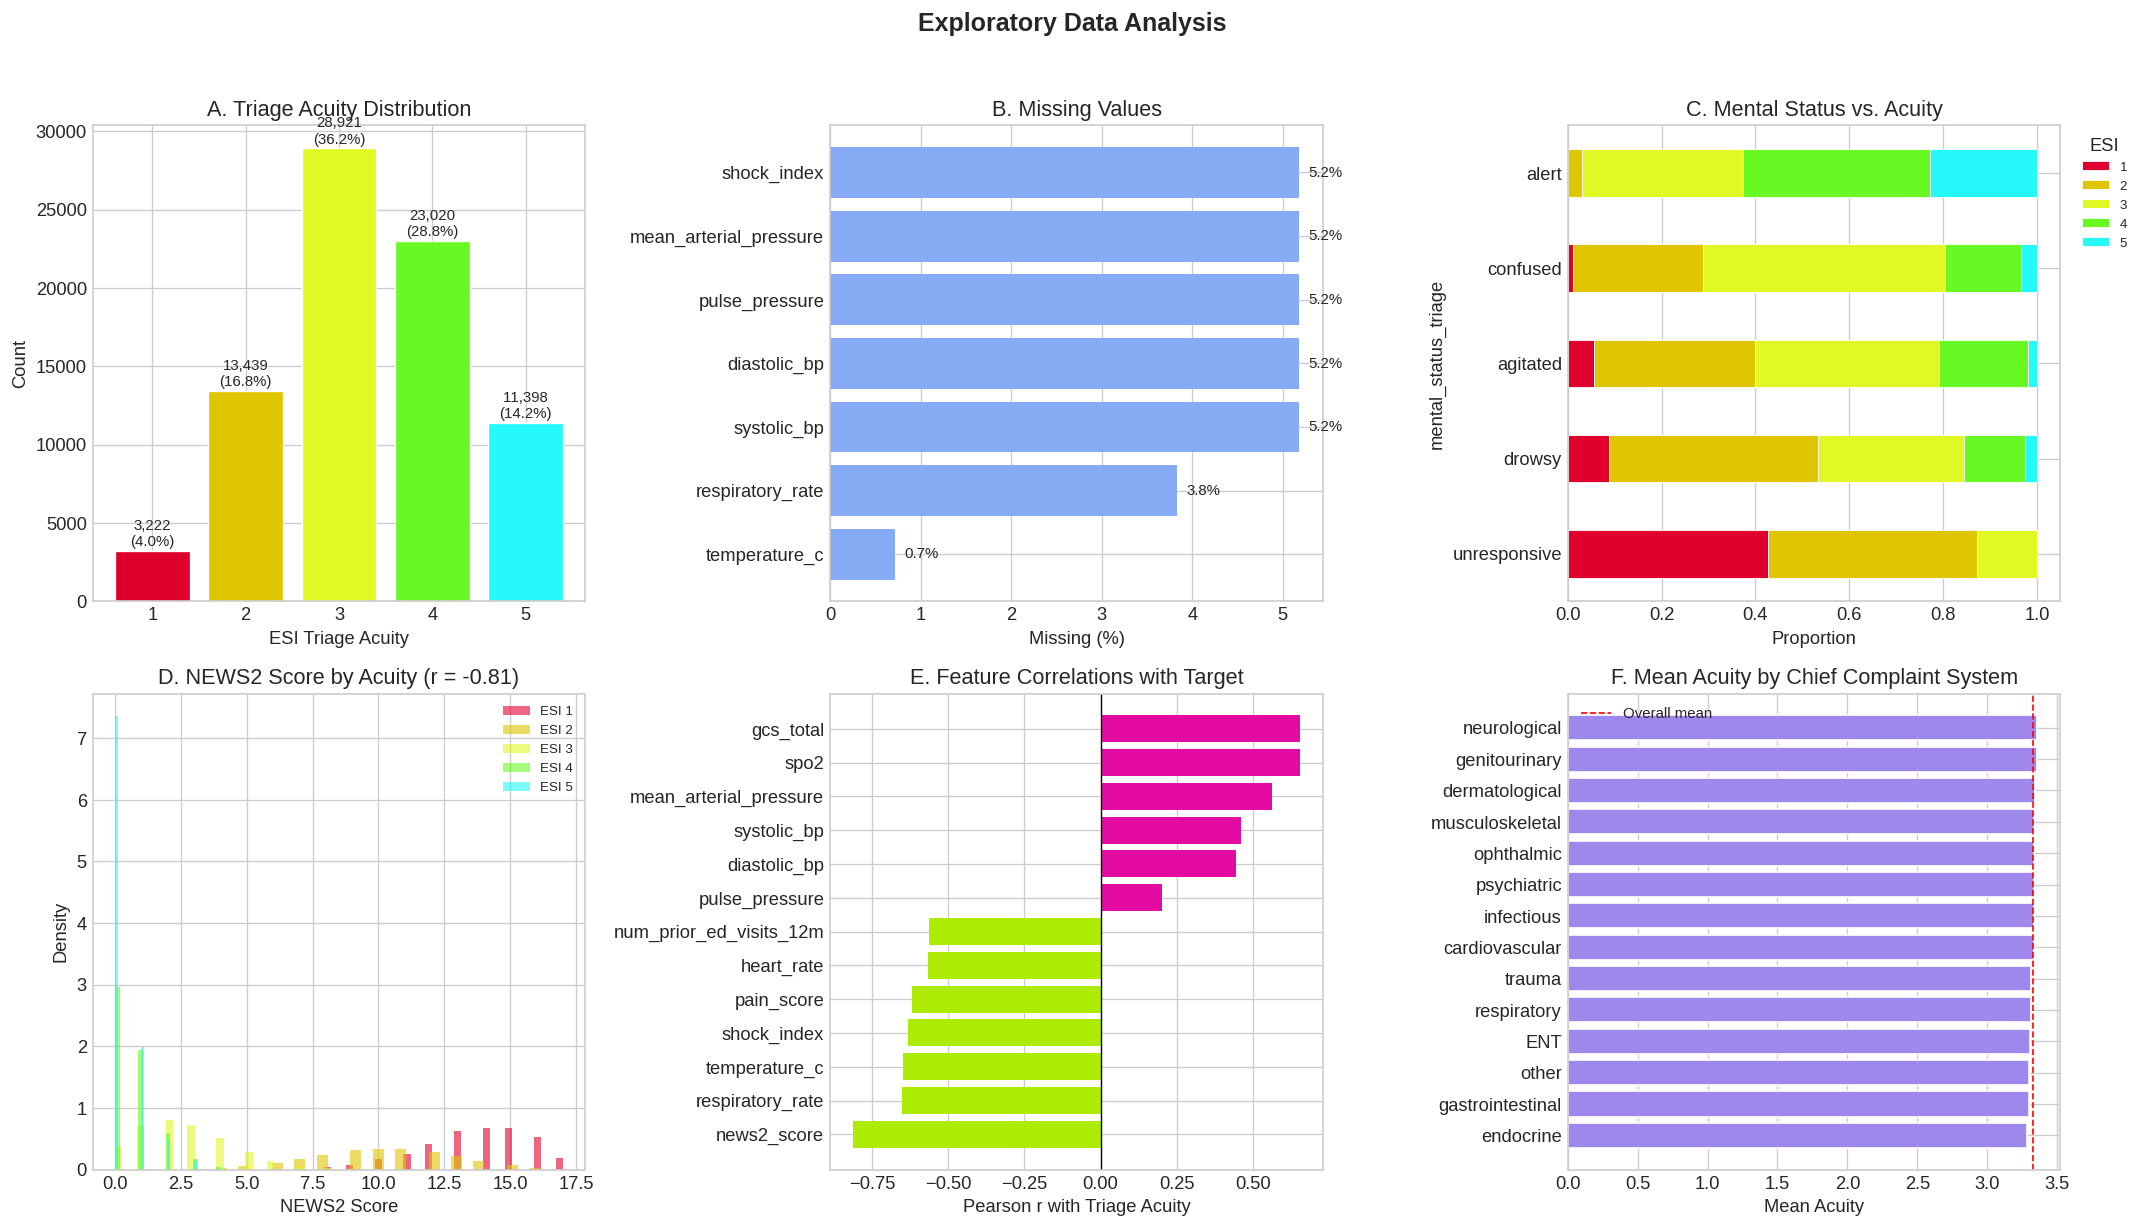

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Acuity distribution
ax = axes[0, 0]
counts = train[TARGET].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=COLORS, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{cnt:,}\n({cnt/len(train)*100:.1f}%)', ha='center', fontsize=9)
ax.set_xlabel('ESI Triage Acuity')
ax.set_ylabel('Count')
ax.set_title('A. Triage Acuity Distribution')
ax.set_xticks(range(1, 6))

# Missing values
ax = axes[0, 1]
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
ax.barh(missing.index, missing.values / len(train) * 100, color='#87aaf5')
ax.set_xlabel('Missing (%)')
ax.set_title('B. Missing Values')
for i, (idx, v) in enumerate(missing.items()):
    ax.text(v/len(train)*100 + 0.1, i, f'{v/len(train)*100:.1f}%', va='center', fontsize=9)

# Mental status vs acuity - the strongest categorical predictor
ax = axes[0, 2]
ct = pd.crosstab(train['mental_status_triage'], train[TARGET], normalize='index')
ct = ct.loc[['unresponsive', 'drowsy', 'agitated', 'confused', 'alert']]
ct.plot(kind='barh', stacked=True, color=COLORS, ax=ax, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Proportion')
ax.set_title('C. Mental Status vs. Acuity')
ax.legend(title='ESI', labels=[f'{k}' for k in ACUITY.keys()],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# NEWS2 distribution by acuity
ax = axes[1, 0]
for lvl in range(1, 6):
    subset = train[train[TARGET] == lvl]['news2_score']
    ax.hist(subset, bins=40, alpha=0.6, label=f'ESI {lvl}', color=COLORS[lvl-1], density=True)
ax.set_xlabel('NEWS2 Score')
ax.set_ylabel('Density')
ax.set_title('D. NEWS2 Score by Acuity (r = -0.81)')
ax.legend(fontsize=8)

# Key vital correlations with target
ax = axes[1, 1]
corr_cols = ['news2_score', 'gcs_total', 'spo2', 'respiratory_rate',
             'temperature_c', 'shock_index', 'pain_score', 'heart_rate',
             'num_prior_ed_visits_12m', 'mean_arterial_pressure',
             'systolic_bp', 'diastolic_bp', 'pulse_pressure']
corrs = train[corr_cols].corrwith(train[TARGET]).sort_values()
colors_bar = ['#adeb05' if v < 0 else '#e30ba2' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with Triage Acuity')
ax.set_title('E. Feature Correlations with Target')

# Chief complaint system vs acuity
ax = axes[1, 2]
system_acuity = train.groupby('chief_complaint_system')[TARGET].mean().sort_values()
ax.barh(system_acuity.index, system_acuity.values, color='#9f88eb', edgecolor='white')
ax.axvline(train[TARGET].mean(), color='red', linestyle='--', linewidth=1, label='Overall mean')
ax.set_xlabel('Mean Acuity')
ax.set_title('F. Mean Acuity by Chief Complaint System')
ax.legend(fontsize=9)

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The above data tell us:
* **ESI 1 is very rare** case about 4%, thus we are dealing with imbalanced data.
* **ESI 3 and ESI 4 are dominating** (ESI distribution is right-skewed).
* **GCS total and NEWS2 score** have the strongest correlation with the acuity level. 

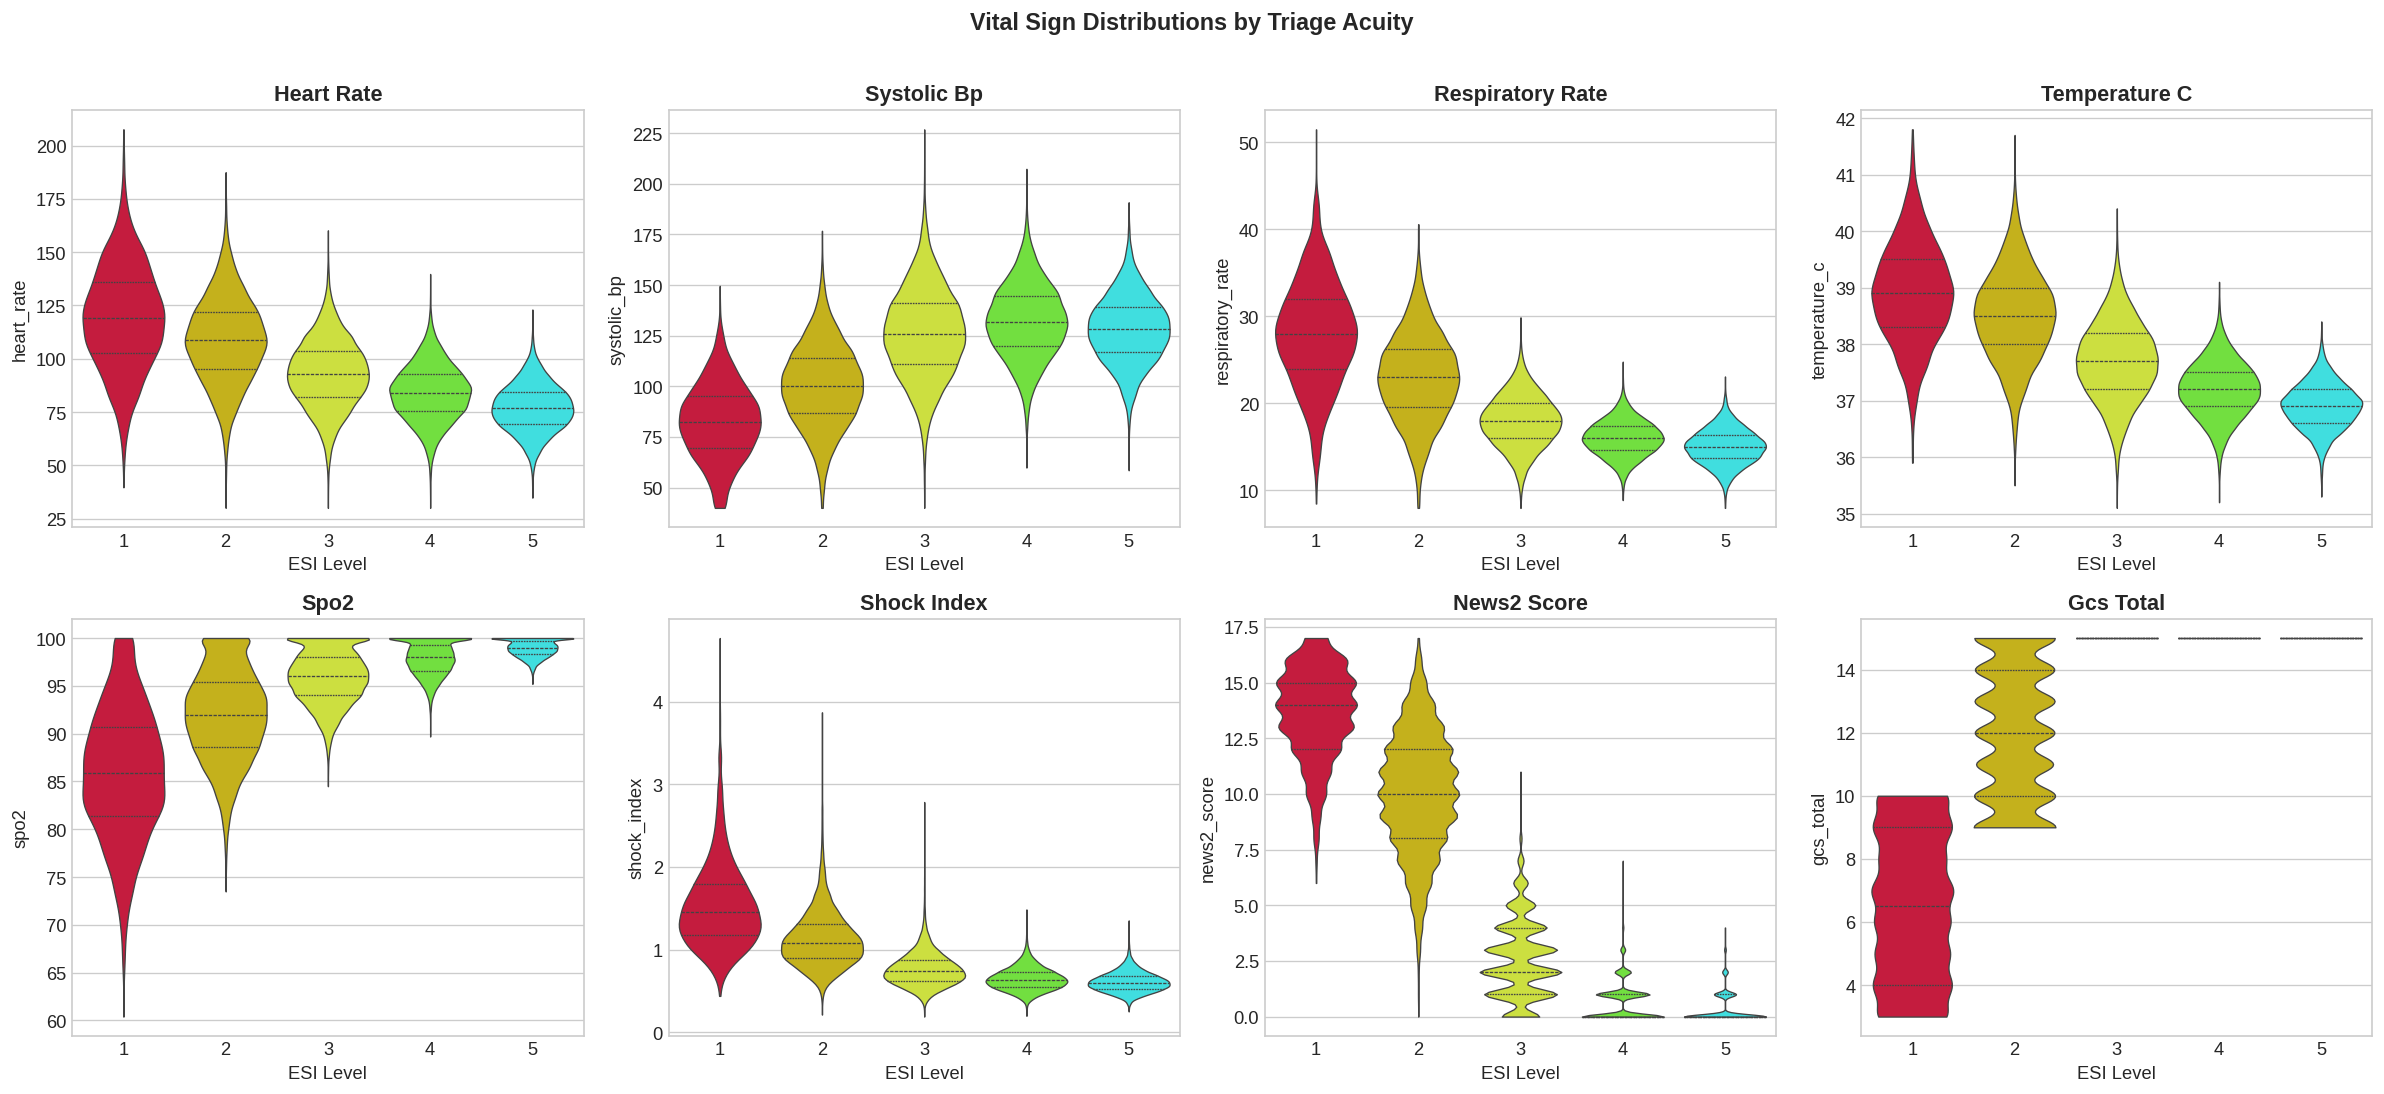

In [6]:
# Vital signs by acuity - detailed view
vital_cols = ['heart_rate', 'systolic_bp', 'respiratory_rate', 'temperature_c',
              'spo2', 'shock_index', 'news2_score', 'gcs_total']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for idx, col in enumerate(vital_cols):
    ax = axes[idx // 4][idx % 4]
    sns.violinplot(data=train, x=TARGET, y=col, ax=ax, palette=PALETTE,
                   inner='quartile', linewidth=0.8, cut=0)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('ESI Level')

plt.suptitle('Vital Sign Distributions by Triage Acuity', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The above data tell us:
* Vital sign derangements (such as elevated heart rate or temperature) do not correlate linearly with acuity. The correlation between vital data and acuity level is a **non-linear correlation**.
* Higher acuity (ESI 1) correlates with physiological derangement across all parameters, consistent with clinical expectations.

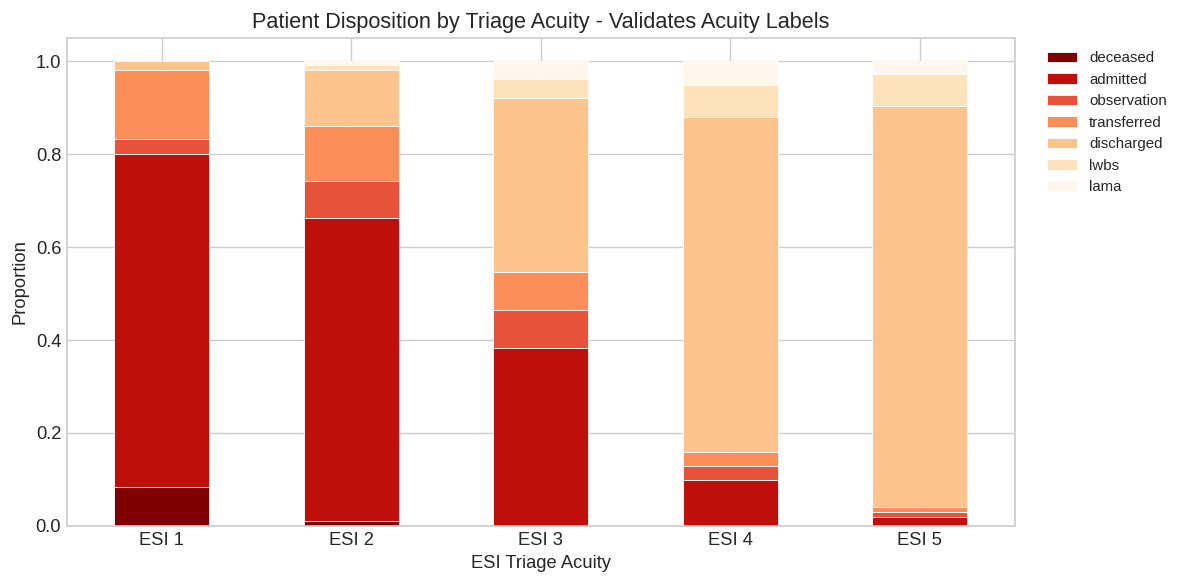

ESI 1 patients: 80.0% admitted/deceased vs ESI 5: 86.4% discharged


In [7]:
# Disposition outcome by acuity - validates acuity labels are clinically meaningful
fig, ax = plt.subplots(figsize=(10, 5))
disp_ct = pd.crosstab(train[TARGET], train['disposition'], normalize='index')
disp_order = ['deceased', 'admitted', 'observation', 'transferred', 'discharged', 'lwbs', 'lama']
disp_ct = disp_ct[[c for c in disp_order if c in disp_ct.columns]]
disp_ct.plot(kind='bar', stacked=True, ax=ax, colormap='OrRd_r', edgecolor='white', linewidth=0.5)
ax.set_xlabel('ESI Triage Acuity')
ax.set_ylabel('Proportion')
ax.set_title('Patient Disposition by Triage Acuity - Validates Acuity Labels')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xticklabels([f'ESI {i}' for i in range(1, 6)], rotation=0)
plt.tight_layout()
plt.show()
print('ESI 1 patients: {:.1f}% admitted/deceased vs ESI 5: {:.1f}% discharged'.format(
    (train[train[TARGET]==1]['disposition'].isin(['admitted','deceased'])).mean()*100,
    (train[train[TARGET]==5]['disposition']=='discharged').mean()*100
))

* ESI scales show a direct correlation between triage level (1–5) and key outcomes such as **higher severity levels (1 or 2) strongly correlate with higher admission rates** and lower severity levels (4 or 5) correlate with higher discharged.
* Conclusion: these analysis (right-skewed of graph, non-linear vitals derangement and validity of disposition and acuity scales) identifies key characteristics of Emergency Department (ED) data, confirming that the competition dataset mirrors realistic clinical environments. 

#### Chief Complaint Analysis
The chief complaint field contains semi-structured text with a base condition followed by optional modifiers (severity, trajectory, duration).

In [8]:
list(train["chief_complaint_raw"][-5:])

['bruised knee after fall，worsening over hours',
 'dehydration moderate，worsening over hours',
 'contraception advice，worsening over hours',
 'globe rupture with vomiting',
 'bruising after ground-level fall with associated nausea']

,clean_condition,complaint_severity
0,thunderclap headache,0
1,contraception advice,0
2,general health question,0
3,erythema migrans tick bite,0
4,cellulitis localised,0


Unique base conditions (train): 2,317
Unique base conditions (test):  2,097

Conditions with single acuity value: 2310 / 2317 (99.7%)
Chief complaint text has a very strong association with triage acuity.


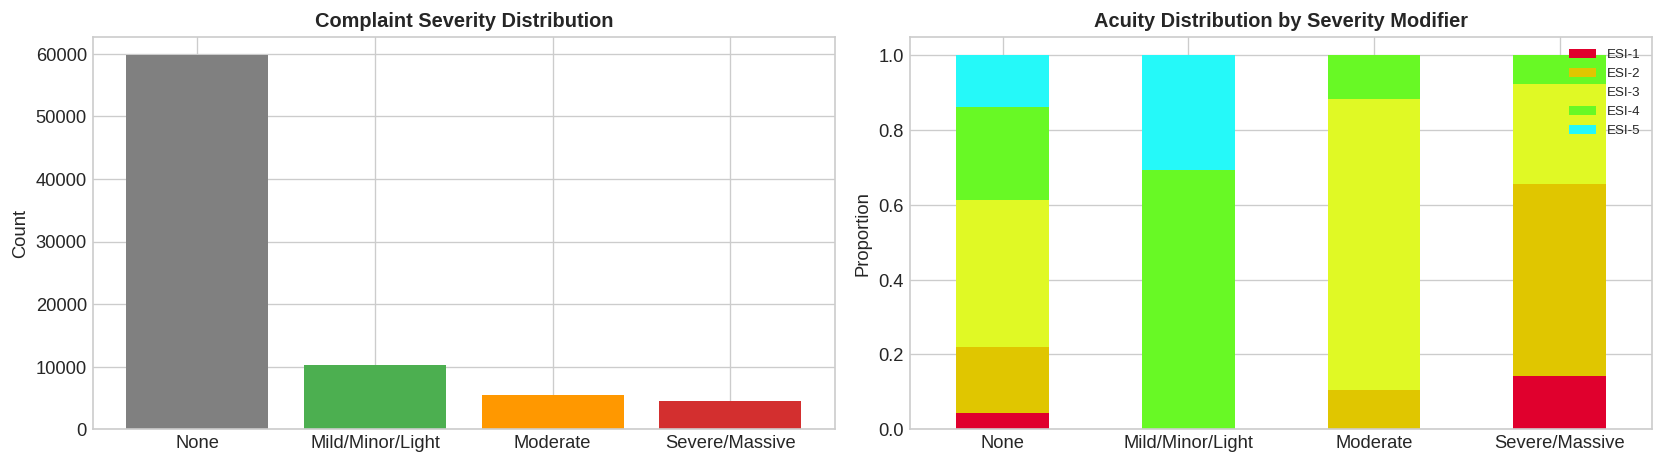

Unseen chief complaint texts in test: 30
Test patients with unseen CC: 39 (0.19%)
These will be handled via TF-IDF partial matching and global mean fallback.



In [9]:
# Parse chief complaint structure
def parse_chief_complaint(text):
    """Extract base condition, severity modifier, and trajectory from CC text."""
    if pd.isna(text):
        return "unknown", 0, "none"

    parts = [p.strip() for p in re.split(r"[,\uff0c]", text)]
    base_condition = parts[0]

    severity = 0
    sev_high = ["severe", "massive"] 
    sev_mod  = ["moderate"]
    sev_low  = ["mild", "minor", "light"]

    all_text = text.lower()
    for w in sev_high:
        if w in all_text:
            severity = 3; break
    if severity == 0:
        for w in sev_mod:
            if w in all_text:
                severity = 2; break
    if severity == 0:
        for w in sev_low:
            if w in all_text:
                severity = 1; break

    trajectory = "none"
    traj_map = {"worsening": "worsening", "improving": "improving",
                "intermittent": "intermittent", "constant": "constant",
                "acute": "acute", "chronic": "chronic"}
    for kw, val in traj_map.items():
        if kw in all_text:
            trajectory = val; break

    return base_condition, severity, trajectory

# Apply to both sets
parsed = train["chief_complaint_raw"].apply(parse_chief_complaint)
train["clean_condition"] = [p[0] for p in parsed]
train["complaint_severity"] = [p[1] for p in parsed]

parsed_test = test["chief_complaint_raw"].apply(parse_chief_complaint)
test["clean_condition"] = [p[0] for p in parsed_test]
test["complaint_severity"] = [p[1] for p in parsed_test]

display(train[["clean_condition","complaint_severity"]].head())
print(f'Unique base conditions (train): {train["clean_condition"].nunique():,}')
print(f'Unique base conditions (test):  {test["clean_condition"].nunique():,}')

# Check condition -> acuity mapping
cond_stats = train.groupby("clean_condition")[TARGET].agg(["nunique", "count", "mean"])
single_acuity = (cond_stats["nunique"] == 1).sum()
print(f'\nConditions with single acuity value: {single_acuity} / {len(cond_stats)} '
      f'({single_acuity/len(cond_stats)*100:.1f}%)')
print("Chief complaint text has a very strong association with triage acuity.")

# Severity modifier distribution and acuity relationship
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sev_labels = ['None', 'Mild/Minor/Light', 'Moderate', 'Severe/Massive']
sev_counts = train['complaint_severity'].value_counts().sort_index()
axes[0].bar(sev_labels, sev_counts.values, color=['grey', '#4caf50', '#ff9800', '#d32f2f'])
axes[0].set_title('Complaint Severity Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

ct = pd.crosstab(train['complaint_severity'], train[TARGET], normalize='index')
ct.index = sev_labels
ct.columns = [f'ESI-{c}' for c in ct.columns]
ct.plot(kind='bar', stacked=True, ax=axes[1], color=COLORS)
axes[1].set_title('Acuity Distribution by Severity Modifier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(sev_labels, rotation=0)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Unseen chief complaints in test set
train_texts = set(train['chief_complaint_raw'].dropna())
test_texts = set(test['chief_complaint_raw'].dropna())
unseen_texts = test_texts - train_texts
print(f'Unseen chief complaint texts in test: {len(unseen_texts)}')

test_unseen_mask = test['chief_complaint_raw'].isin(unseen_texts)
print(f'Test patients with unseen CC: {test_unseen_mask.sum()} ({test_unseen_mask.mean()*100:.2f}%)')
print('These will be handled via TF-IDF partial matching and global mean fallback.')

del parsed, parsed_test, cond_stats, train_texts, test_texts, unseen_texts, test_unseen_mask
gc.collect()
print()

The above data tell us:
* The chief complain text follows a regular structure (condition + severity).
* Because chief complain text has a strong association with triage acuity, the encoding of it will be included in features.

---
## 3. Advanced EDA - Distribution Shift

* Distrbution shift is important whether models will perform well or not against unseen test data.
* Small distribution shift means easier for model to predict test data more accurately because the pattern is not so different from train data the model has learned.

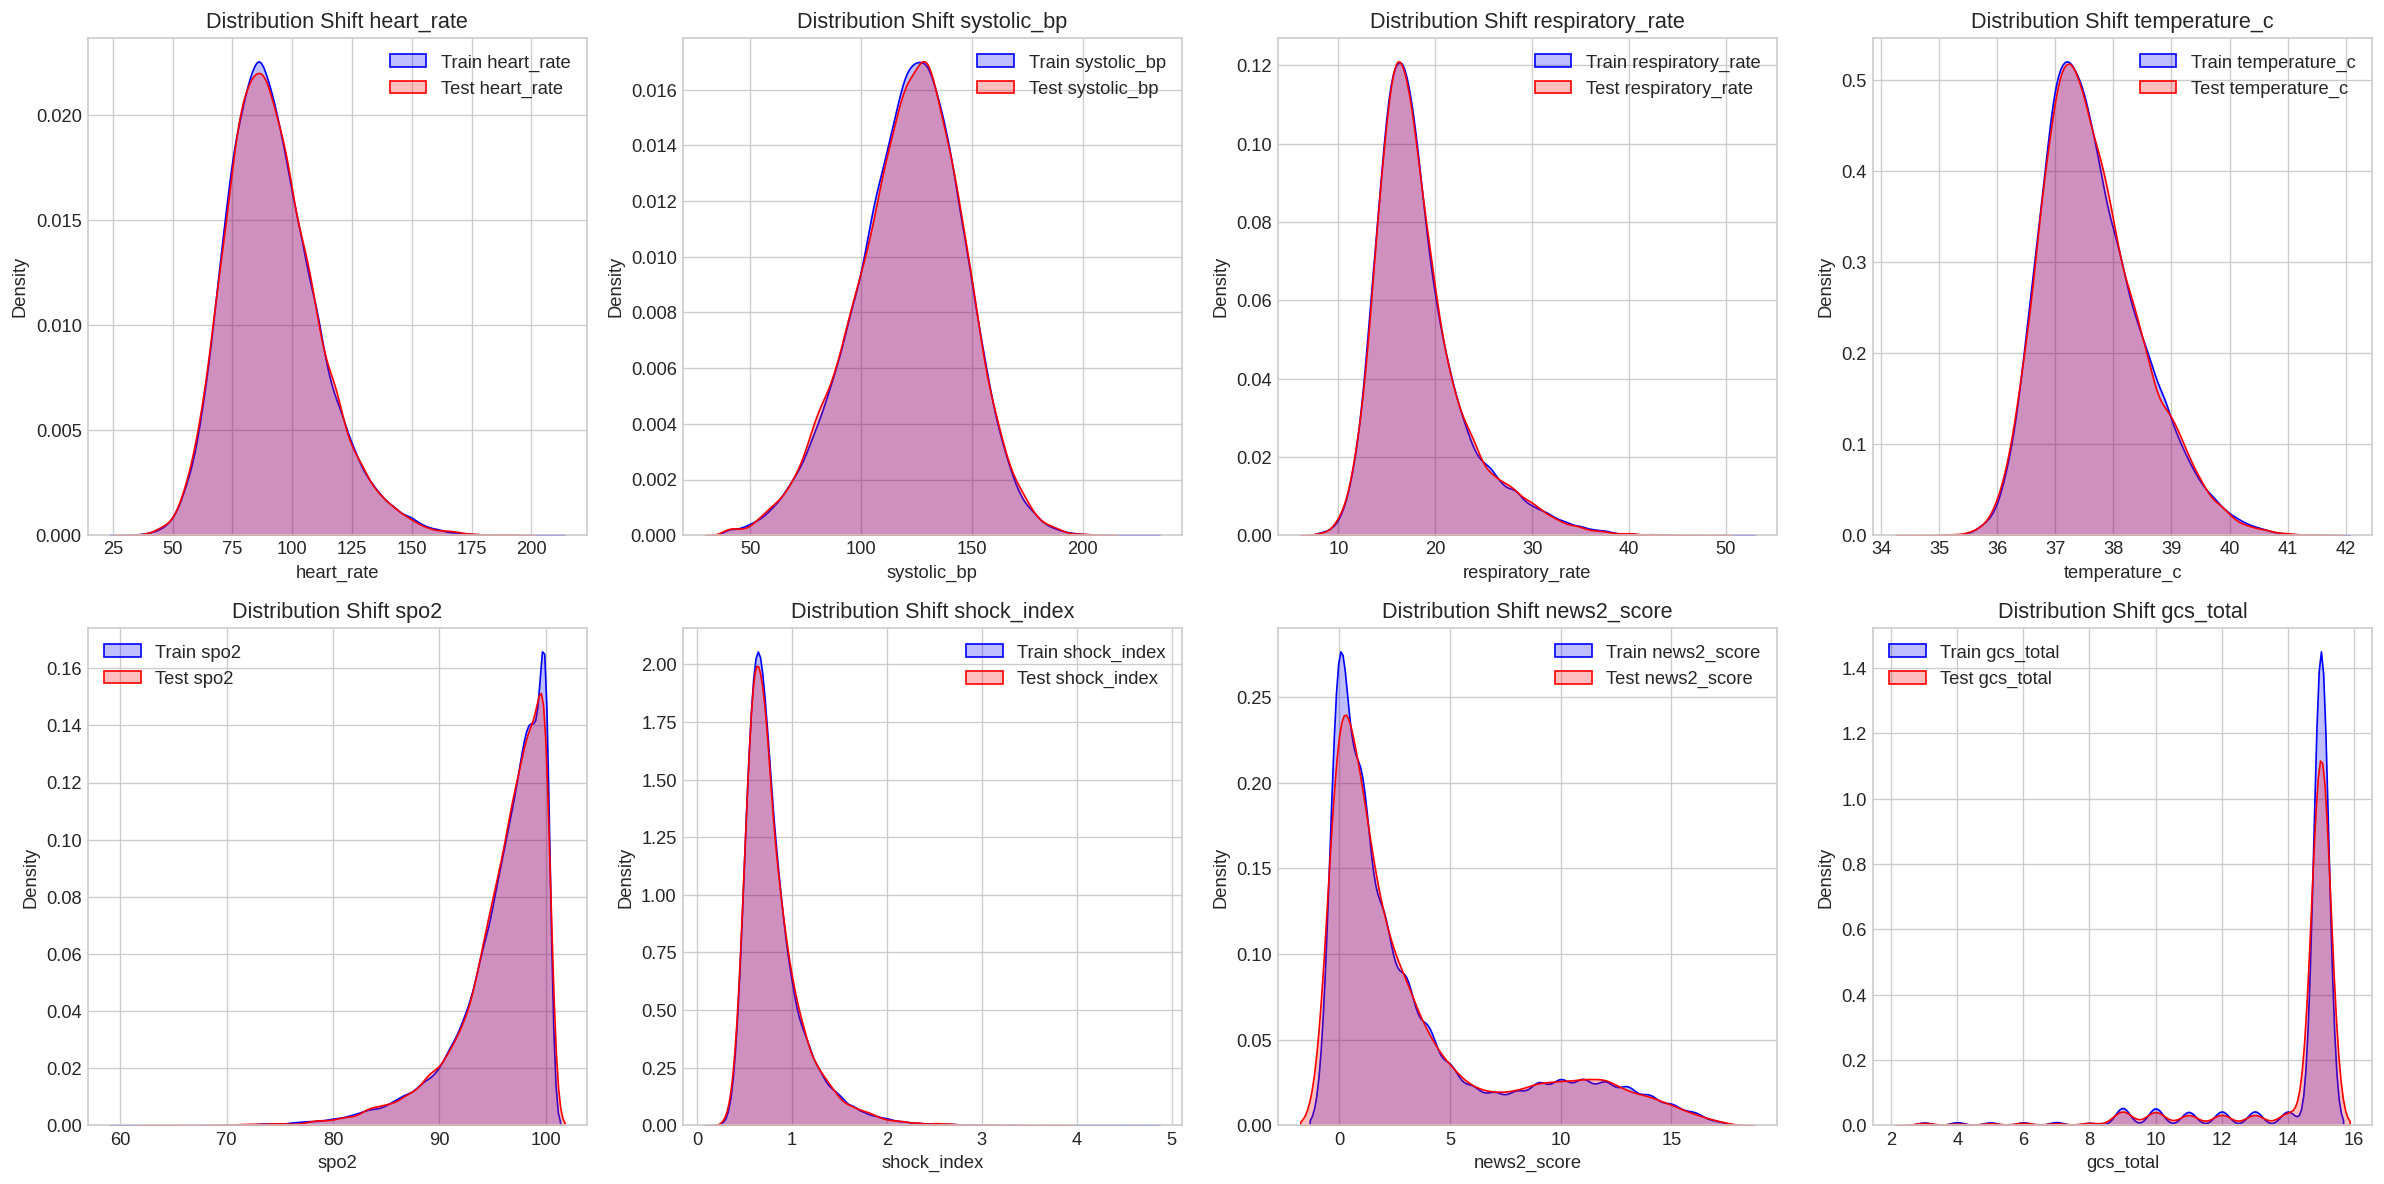

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

vital_cols = ['heart_rate', 'systolic_bp', 'respiratory_rate', 'temperature_c',
              'spo2', 'shock_index', 'news2_score', 'gcs_total']
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs_flat = axs.flatten()
for i,col in enumerate(vital_cols):
    # Plot first KDE
    sns.kdeplot(train[col], ax=axs_flat[i], fill=True, color='blue', label='Train '+col)
    # Plot second KDE (overlay)
    sns.kdeplot(test[col], ax=axs_flat[i], fill=True, color='red', label='Test '+col) 
    axs_flat[i].set_title(f'Distribution Shift {col}')
    axs_flat[i].legend()

plt.tight_layout()
plt.show()


* Because there are **no meaningful distribution shift** in vitals data, especially in news2_score and gcs_total (two important features), models will learn the pattern of train data effectively and will not have performance degradation in predicting test data.

---
## 4. Feature Engineering

We engineer **clinical features** grounded in emergency medicine literature:

| Category | Features | Clinical Rationale |
|:---------|:---------|:------------------|
| Vital abnormality flags | Hypotension, tachycardia, hypoxia, etc. (11 flags) | Direct ESI branch points (Gilboy et al., 2020) |
| qSOFA score | SBP<=100, RR>=22, GCS<15 | Sepsis screening per SOFA guidelines (Singer et al., 2016) |
| SIRS approximation | Temp/HR/RR abnormality count | Systemic inflammatory response |
| Composite scores | `num_abnormal_vitals`, `cv_risk_score` | Aggregate acuity burden |
| Age-vital interactions | `age-shock_index`, `age-NEWS2` | Elderly decompensation principle |
| Critical NLP keywords | Chest pain, seizure, stroke, SOB flags | High-risk presentation detection |
| TF-IDF embeddings | Chief complaint unigrams + bigrams | Full text signal |
| Target-encoded IDs | Nurse ID, Site ID | Captures systematic inter-rater variability |
| Temporal | Cyclical hour/month, weekend, night shift | ED acuity temporal patterns |
| SentenceTransformer embeddings | Chief complaint | Capture semantic complaint |
| Target-encoded chief complaint | Chief complaint | Capture strong association with triage acuity|


We add the following features to add diversity to the data:
* one hot encoding for all categorical features but still keep the original category features.
* categorical features from numerical features and keep the original numerical features.

In [11]:
%%time

# All features is made through this function
def features_function(max_words=100, max_chars=90, lim_words=3, lim_chars=3):
    train_raw = pd.read_csv(f'{DATA}/train.csv')
    test_raw  = pd.read_csv(f'{DATA}/test.csv')
    complaints = pd.read_csv(f'{DATA}/chief_complaints.csv')
    history    = pd.read_csv(f'{DATA}/patient_history.csv')
    sample_sub = pd.read_csv(f'{DATA}/sample_submission.csv')
    
    cc_dedup = complaints[[ID, 'chief_complaint_raw']].drop_duplicates(subset=ID, keep='first')
    
    train = train_raw.merge(cc_dedup, on=ID, how='left').merge(history, on=ID, how='left')
    test  = test_raw.merge(cc_dedup, on=ID, how='left').merge(history, on=ID, how='left')

    # Apply parse_chief_complaint to both sets
    parsed = train["chief_complaint_raw"].apply(parse_chief_complaint)
    train["clean_condition"] = [p[0] for p in parsed]
    train["complaint_severity"] = [p[1] for p in parsed]
    
    parsed_test = test["chief_complaint_raw"].apply(parse_chief_complaint)
    test["clean_condition"] = [p[0] for p in parsed_test]
    test["complaint_severity"] = [p[1] for p in parsed_test]

    del parsed, parsed_test, train_raw, test_raw, complaints, history, sample_sub, cc_dedup
    gc.collect()
    
    def engineer_features(df):
        df = df.copy()
        
        # --- VITAL SIGN ABNORMALITY FLAGS ---
        df['flag_hypotension']        = (df['systolic_bp'] < 90).astype(np.int8)
        df['flag_hypertension_crisis'] = (df['systolic_bp'] > 180).astype(np.int8)
        df['flag_severe_hypotension'] = (df['systolic_bp'] < 70).astype(np.int8)
        df['flag_tachycardia']        = (df['heart_rate'] > 100).astype(np.int8)
        df['flag_severe_tachycardia'] = (df['heart_rate'] > 130).astype(np.int8)
        df['flag_bradycardia']        = (df['heart_rate'] < 60).astype(np.int8)
        df['flag_tachypnea']          = (df['respiratory_rate'] > 20).astype(np.int8)
        df['flag_severe_tachypnea']   = (df['respiratory_rate'] > 30).astype(np.int8)
        df['flag_hypothermia']        = (df['temperature_c'] < 36.0).astype(np.int8)
        df['flag_fever']              = (df['temperature_c'] > 38.0).astype(np.int8)
        df['flag_high_fever']         = (df['temperature_c'] > 39.0).astype(np.int8)
        df['flag_hypoxia']            = (df['spo2'] < 92).astype(np.int8)
        df['flag_severe_hypoxia']     = (df['spo2'] < 88).astype(np.int8)
        df['flag_altered_mental']     = (df['gcs_total'] < 15).astype(np.int8)
        df['flag_severe_gcs']         = (df['gcs_total'] <= 8).astype(np.int8)
        df['flag_severe_pain']        = (df['pain_score'] >= 8).astype(np.int8)
        df['flag_high_shock_idx']     = (df['shock_index'] > 1.0).astype(np.int8)
        df['flag_critical_shock_idx'] = (df['shock_index'] > 1.3).astype(np.int8)
        
        flag_cols = [c for c in df.columns if c.startswith('flag_')]
        df['num_abnormal_vitals'] = df[flag_cols].sum(axis=1)
        
        # --- qSOFA SCORE (0-3) ---
        df['qsofa_sbp']  = (df['systolic_bp'] <= 100).astype(np.int8)
        df['qsofa_rr']   = (df['respiratory_rate'] >= 22).astype(np.int8)
        df['qsofa_gcs']  = (df['gcs_total'] < 15).astype(np.int8)
        df['qsofa_score'] = df['qsofa_sbp'] + df['qsofa_rr'] + df['qsofa_gcs']
        
        # --- SIRS-like criteria count ---
        df['sirs_temp']  = ((df['temperature_c'] > 38.0) | (df['temperature_c'] < 36.0)).astype(np.int8)
        df['sirs_hr']    = (df['heart_rate'] > 90).astype(np.int8)
        df['sirs_rr']    = (df['respiratory_rate'] > 20).astype(np.int8)
        df['sirs_count'] = df['sirs_temp'] + df['sirs_hr'] + df['sirs_rr']
        
        # --- COMPOSITE RISK SCORES ---
        hx_cols = [c for c in df.columns if c.startswith('hx_')]
        if hx_cols:
            df['comorbidity_burden'] = df[hx_cols].sum(axis=1)
        
        cv_cols = ['hx_hypertension', 'hx_heart_failure', 'hx_atrial_fibrillation',
                   'hx_coronary_artery_disease', 'hx_stroke_prior', 'hx_peripheral_vascular_disease']
        cv_present = [c for c in cv_cols if c in df.columns]
        df['cv_risk_score'] = df[cv_present].sum(axis=1) if cv_present else 0
        
        resp_cols = ['hx_asthma', 'hx_copd']
        resp_present = [c for c in resp_cols if c in df.columns]
        df['respiratory_risk'] = df[resp_present].sum(axis=1) if resp_present else 0
        
        meta_cols = ['hx_diabetes_type2', 'hx_diabetes_type1', 'hx_obesity',
                     'hx_hypothyroidism', 'hx_hyperthyroidism']
        meta_present = [c for c in meta_cols if c in df.columns]
        df['metabolic_risk'] = df[meta_present].sum(axis=1) if meta_present else 0
        
        psych_cols = ['hx_depression', 'hx_anxiety', 'hx_substance_use_disorder']
        psych_present = [c for c in psych_cols if c in df.columns]
        df['psych_risk'] = df[psych_present].sum(axis=1) if psych_present else 0
        
        # --- AGE-VITAL INTERACTIONS ---
        df['age_x_shock_index']  = df['age'] * df['shock_index']
        df['age_x_news2']        = df['age'] * df['news2_score']
        df['age_x_gcs']          = df['age'] * df['gcs_total']
        df['age_x_comorbidities'] = df['age'] * df['num_comorbidities']
        df['age_x_qsofa']        = df['age'] * df['qsofa_score']
        
        # --- VITAL SIGN RATIOS & PRODUCTS ---
        df['hr_rr_ratio']     = df['heart_rate'] / df['respiratory_rate'].replace(0, np.nan)
        df['sbp_hr_product']  = df['systolic_bp'] * df['heart_rate']
        df['map_hr_ratio']    = df['mean_arterial_pressure'] / df['heart_rate'].replace(0, np.nan)
        df['pp_sbp_ratio']    = df['pulse_pressure'] / df['systolic_bp'].replace(0, np.nan)
        df['spo2_rr_product'] = df['spo2'] * df['respiratory_rate']
        
        # --- ED UTILIZATION ---
        df['ed_utilization'] = df['num_prior_ed_visits_12m'] + 2 * df['num_prior_admissions_12m']
        df['high_ed_user']   = (df['num_prior_ed_visits_12m'] >= 4).astype(np.int8)
        df['polypharmacy']   = (df['num_active_medications'] >= 5).astype(np.int8)
        
        # --- TEMPORAL FEATURES ---
        df['is_weekend']    = df['arrival_day'].isin(['Saturday', 'Sunday']).astype(np.int8)
        df['is_night']      = df['shift'].eq('night').astype(np.int8)
        df['is_peak_hours'] = df['arrival_hour'].between(10, 18).astype(np.int8)
        
        hour_rad = 2 * np.pi * df['arrival_hour'] / 24
        df['hour_sin'] = np.sin(hour_rad)
        df['hour_cos'] = np.cos(hour_rad)
        
        month_rad = 2 * np.pi * df['arrival_month'] / 12
        df['month_sin'] = np.sin(month_rad)
        df['month_cos'] = np.cos(month_rad)
        
        return df
    
    train = engineer_features(train)
    test  = engineer_features(test)
    
    # --- CRITICAL CHIEF COMPLAINT KEYWORD FLAGS ---
    # Clinically high-risk presentations that should trigger higher acuity
    
    CRITICAL_KEYWORDS = {
        'kw_chest_pain':     r'chest\s*pain|angina|acs|acute coronary',
        'kw_sob':            r'shortness.*breath|dyspn[eo]|sob |respiratory\s*distress|breathing\s*difficult',
        'kw_stroke':         r'stroke|hemipar|aphasia|facial\s*droop|tia|cerebrovascular',
        'kw_seizure':        r'seizure|convuls|epilep|status\s*epilepticus',
        'kw_cardiac_arrest': r'cardiac\s*arrest|asystole|pulseless|cpr|resuscitat',
        'kw_trauma_major':   r'major\s*trauma|polytrauma|mva|motor\s*vehicle|fall\s*from\s*height|penetrat',
        'kw_sepsis':         r'sepsis|septic|bacteremia|bacteria|fungemia',
        'kw_anaphylaxis':    r'anaphyla|massive|severe\s*allerg',
        'kw_suicidal':       r'suicid|self-harm|harm|overdose|intentional|hanging',
        'kw_altered_mental': r'altered\s*mental|confusion|unresponsive|unconscious|syncope|collaps',
        'kw_gi_bleed':       r'haematemes|melena|gi\s*bleed|rectal\s*bleed|blood.*stool|vomit.*blood',
        'kw_fracture':       r'fracture|broken\s*bone|disloc',
        'kw_abdominal':      r'abdominal\s*pain|acute\s*abdomen|appendic',
        'kw_headache':       r'headache|migraine|thunderclap',
        'kw_fever':          r'fever|febrile|pyrexia|rigors',
        'kw_mild':           r'advice|follow-up|prescription|refill|check.?up|minor|mild|chronic\s*stable',
    }

    #Keyword prevalence in training data:
    #kw_chest_pain            : 1,026 patients, mean acuity 2.82
    #kw_sob                   : 1,379 patients, mean acuity 3.07
    #kw_stroke                :   647 patients, mean acuity 2.59
    #kw_seizure               :   180 patients, mean acuity 1.82
    #kw_cardiac_arrest        :    83 patients, mean acuity 1.00
    #kw_trauma_major          :   555 patients, mean acuity 1.73
    #kw_sepsis                : 1,047 patients, mean acuity 2.30
    #kw_anaphylaxis           :   297 patients, mean acuity 1.65
    #kw_suicidal              : 1,278 patients, mean acuity 2.22
    #kw_altered_mental        : 1,769 patients, mean acuity 2.60
    #kw_gi_bleed              :   492 patients, mean acuity 3.19
    #kw_fracture              : 2,063 patients, mean acuity 2.54
    #kw_abdominal             : 1,083 patients, mean acuity 2.80
    #kw_headache              : 1,525 patients, mean acuity 3.63
    #kw_fever                 : 13,067 patients, mean acuity 3.33
    #kw_mild                  : 12,887 patients, mean acuity 4.45
    
    for col_name, pattern in CRITICAL_KEYWORDS.items():
        train[col_name] = train['chief_complaint_raw'].fillna('').str.contains(pattern, case=False, regex=True).astype(np.int8)
        test[col_name]  = test['chief_complaint_raw'].fillna('').str.contains(pattern, case=False, regex=True).astype(np.int8)
    
    kw_cols = [c for c in train.columns if c.startswith('kw_')]
    train['num_critical_keywords'] = train[kw_cols].sum(axis=1)
    test['num_critical_keywords']  = test[kw_cols].sum(axis=1)
    
    # Chief complaint text length and word count
    train['cc_length']     = train['chief_complaint_raw'].fillna('').str.len()
    train['cc_word_count'] = train['chief_complaint_raw'].fillna('').str.split().str.len()
    test['cc_length']      = test['chief_complaint_raw'].fillna('').str.len()
    test['cc_word_count']  = test['chief_complaint_raw'].fillna('').str.split().str.len()


    # --- TF-IDF on chief complaint text ---
    # Dual-channel NLP: word n-grams capture capture local context and structural phrasing (not semantic meaning)
    # character n-grams capture morphological patterns and misspellings
    cc_train = train['chief_complaint_raw'].fillna('unknown')
    cc_test  = test['chief_complaint_raw'].fillna('unknown')
    
    tfidf_word = TfidfVectorizer(
        max_features=max_words, ngram_range=(1, lim_words), analyzer='word', #original (1,3)
        stop_words='english', lowercase=True,
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    tfidf_char = TfidfVectorizer(
        max_features=max_chars, ngram_range=(2, lim_chars), analyzer='char_wb',
        lowercase=True, min_df=5, max_df=0.95, sublinear_tf=True
    )
    
    train_word_mat = tfidf_word.fit_transform(cc_train)
    test_word_mat  = tfidf_word.transform(cc_test)
    train_char_mat = tfidf_char.fit_transform(cc_train)
    test_char_mat  = tfidf_char.transform(cc_test)

    def sanitize_name(s):
        return re.sub(r'[^A-Za-z0-9_]', '_', s).strip('_')
    
    n_word = len(tfidf_word.get_feature_names_out())
    n_char = len(tfidf_char.get_feature_names_out())
    word_raw = [f'tfidf_w_{sanitize_name(n)}' for n in tfidf_word.get_feature_names_out()]
    char_raw = [f'tfidf_c_{sanitize_name(n)}' for n in tfidf_char.get_feature_names_out()]
    all_raw = word_raw + char_raw
    seen = {}
    tfidf_names = []
    for name in all_raw:
        if name in seen:
            seen[name] += 1
            tfidf_names.append(f'{name}_{seen[name]}')
        else:
            seen[name] = 0
            tfidf_names.append(name)
    
    from scipy.sparse import hstack as sp_hstack
    train_tfidf_mat = sp_hstack([train_word_mat, train_char_mat])
    test_tfidf_mat  = sp_hstack([test_word_mat, test_char_mat])
    
    train_tfidf_df = pd.DataFrame(train_tfidf_mat.toarray(), columns=tfidf_names, index=train.index)
    test_tfidf_df  = pd.DataFrame(test_tfidf_mat.toarray(), columns=tfidf_names, index=test.index)
    
    # --- TARGET ENCODING for nurse_id and site_id ---
    # Out-of-fold to prevent leakage
    def target_encode_oof(train_df, test_df, col, target, n_folds=5, seed=42):
        #Target encoding with out-of-fold strategy to prevent leakage.
        global_mean = train_df[target].mean()
        train_enc = pd.Series(np.full(len(train_df), global_mean), index=train_df.index, name=f'{col}_te')
        
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        for tr_idx, val_idx in skf.split(train_df, train_df[target]):
            means = train_df.iloc[tr_idx].groupby(col)[target].mean()
            train_enc.iloc[val_idx] = train_df.iloc[val_idx][col].map(means).fillna(global_mean).values
        
        full_means = train_df.groupby(col)[target].mean()
        test_enc = test_df[col].map(full_means).fillna(global_mean)
        test_enc.name = f'{col}_te'
        
        return train_enc, test_enc
    
    for col in ["clean_condition", 'triage_nurse_id', 'site_id']:
        tr_enc, te_enc = target_encode_oof(train, test, col, TARGET)
        train[f'{col}_te'] = tr_enc.values
        test[f'{col}_te']  = te_enc.values

    del tr_enc, te_enc
    gc.collect()
    
    #Range of target encoded of "clean_condition", 'triage_nurse_id', 'site_id'
    #clean_condition_te: train range [1.000, 5.000]
    #triage_nurse_id_te: train range [3.259, 3.391]
    #site_id_te: train range [3.307, 3.335]
    #clean_condition_te ranges widely
    #triage_nurse_id_te and site_id_te have small range
    #This shows site and nurse differences will not play a much role compared to clean_conditio in term of predicting.
    #Nevertheless, we still use triage_nurse_id_te and site_id_te in features for data diversity.
    
    # --- ASSEMBLE FINAL FEATURE MATRIX ---    
    CAT_COLS = [
        'arrival_mode', 'arrival_day', 'arrival_season', 'shift',
        'age_group', 'sex', 'language', 'insurance_type',
        'transport_origin', 'pain_location', 'mental_status_triage',
        'chief_complaint_system',
    ]
    
    NUM_COLS = [
        'arrival_hour', 'arrival_month', 'age',
        'num_prior_ed_visits_12m', 'num_prior_admissions_12m',
        'num_active_medications', 'num_comorbidities',
        'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
        'pulse_pressure', 'heart_rate', 'respiratory_rate',
        'temperature_c', 'spo2', 'gcs_total', 'pain_score',
        'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
        "complaint_severity",
    ]
    
    HX_COLS = [c for c in train.columns if c.startswith('hx_')]
    
    ENG_COLS = (
        [c for c in train.columns if c.startswith('flag_')]
        + ['num_abnormal_vitals', 'qsofa_score', 'sirs_count',
           'comorbidity_burden', 'cv_risk_score', 'respiratory_risk',
           'metabolic_risk', 'psych_risk',
           'age_x_shock_index', 'age_x_news2', 'age_x_gcs',
           'age_x_comorbidities', 'age_x_qsofa',
           'hr_rr_ratio', 'sbp_hr_product', 'map_hr_ratio',
           'pp_sbp_ratio', 'spo2_rr_product',
           'ed_utilization', 'high_ed_user', 'polypharmacy',
           'is_weekend', 'is_night', 'is_peak_hours',
           'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
           'triage_nurse_id_te', 'site_id_te',
           'num_critical_keywords', 'cc_length', 'cc_word_count']
        + kw_cols
    )
    ENG_COLS = list(dict.fromkeys(ENG_COLS))  # deduplicate
    
    # Encode categoricals
    for col in CAT_COLS:
        combined = pd.concat([train[col], test[col]], axis=0).astype('category')
        codes = combined.cat.codes
        train[col] = codes.iloc[:len(train)].values
        test[col]  = codes.iloc[len(train):].values

    CC_COLS = ["clean_condition_te"]

    all_feature_cols = CAT_COLS + NUM_COLS + HX_COLS + ENG_COLS + CC_COLS
    all_feature_cols = [c for c in all_feature_cols if c in train.columns]
    
    X_train = pd.concat([train[all_feature_cols].reset_index(drop=True),
                        train_tfidf_df.reset_index(drop=True)],axis=1)
    X_test = pd.concat([test[all_feature_cols].reset_index(drop=True),
                       test_tfidf_df.reset_index(drop=True)],axis=1)
    
    y_train = train[TARGET].values
    
    from sklearn.preprocessing import OneHotEncoder
    
    all_data = pd.concat([X_train, X_test], axis=0)

    
    # Make category from numeric features
    # When unique values is less than 25 add category features from it
    add_cat_cols = []
    for col in NUM_COLS:
        how_many = len(all_data[col].unique())
        if how_many < 10:
            X_train[col + "_trans2cat"] = X_train[col].copy().fillna("-1").astype("str")
            X_test[col + "_trans2cat"] = X_test[col].copy().fillna("-1").astype("str")
            add_cat_cols.append(col + "_trans2cat")
    for col in add_cat_cols:
        X_train[col] = X_train[col].astype("str")
        X_test[col] = X_test[col].astype("str")
    
    
    # one-hot encoder
    one_hot_encoder = OneHotEncoder(sparse_output=False)
    one_hot_features = CAT_COLS + add_cat_cols
    one_hot_encoder.fit(X_train[one_hot_features])
    
    features_new_train = one_hot_encoder.transform(X_train[one_hot_features])
    features_new_train = pd.DataFrame(features_new_train)
    features_new_train.columns = ['onehot_'+ str(x) for x in range(len(features_new_train.columns))]
    X_train = pd.concat([X_train, features_new_train], axis=1)
    
    features_new_test = one_hot_encoder.transform(X_test[one_hot_features])
    features_new_test = pd.DataFrame(features_new_test)
    features_new_test.columns = ['onehot_'+ str(x) for x in range(len(features_new_test.columns))]
    X_test = pd.concat([X_test, features_new_test], axis=1)
    
    
    # Encode categoricals of add_cat_cols
    for col in add_cat_cols:
        combined = pd.concat([X_train[col], X_test[col]], axis=0).astype('category')
        codes = combined.cat.codes
        X_train[col] = codes.iloc[:len(train)].values
        X_test[col]  = codes.iloc[len(train):].values
    
    
    # Recheck there is no Leakage.
    # Make sure disposition and ed_los_hours are not included in both train and test data.
    # Because disposition and ed_los_hours can only be obtained after ESI level is predicted.
    train_features = list(X_train.columns)
    test_features = list(X_test.columns)
    
    if "disposition" in train_features:
        print(f"Leakage")
    if "ed_los_hours" in train_features:
        print(f"Leakage")
    if "disposition" in test_features:
        print(f"Leakage")
    if "ed_los_hours" in test_features:
        print(f"Leakage")
    
    ONE_HOT_ENCODER_COLS = list(features_new_train.columns)

    
    # SentenceTransformer embedding (NLP) 
    from sentence_transformers import SentenceTransformer
    
    TRAIN_PATH  = "/kaggle/input/competitions/triagegeist/train.csv"
    TEST_PATH   = "/kaggle/input/competitions/triagegeist/test.csv"
    CC_PATH     = "/kaggle/input/competitions/triagegeist/chief_complaints.csv"
    SUB_PATH    = "/kaggle/input/competitions/triagegeist/sample_submission.csv"
    
    train_df = pd.read_csv(TRAIN_PATH)
    test_df  = pd.read_csv(TEST_PATH)
    cc_df    = pd.read_csv(CC_PATH)
    
    train_df = train_df.merge(cc_df, on="patient_id", how="left")
    test_df  = test_df.merge(cc_df,  on="patient_id", how="left")

    # Fill missing complaints
    train_df["chief_complaint_raw"].fillna("unknown complaint", inplace=True)
    test_df["chief_complaint_raw"].fillna("unknown complaint",  inplace=True)
    
    def clean_complaint(text: str) -> str:
        #Light clinical text cleaning:
        #- Lowercase
        #- Remove punctuation / digits (keep letters & spaces)
        #- Strip extra whitespace
        #- Preserve key clinical abbreviations by expanding them first
        
        ABBREV = {
            r"\bdob\b": "difficulty of breathing",
            r"\bloc\b": "loss of consciousness",
            r"\bn/v\b": "nausea vomiting",
            r"\bhtn\b": "hypertension",
            r"\bdm\b":  "diabetes",
            r"\beti\b": "endotracheal intubation",
            r"\brta\b": "road traffic accident",
            r"\bmva\b": "motor vehicle accident",
        }
        text = str(text).lower()
        for pattern, expansion in ABBREV.items():
            text = re.sub(pattern, expansion, text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text
    
    train_df["complaint_clean"] = train_df["chief_complaint_raw"].apply(clean_complaint)
    test_df["complaint_clean"]  = test_df["chief_complaint_raw"].apply(clean_complaint)
    
    EMBED_MODEL = "all-MiniLM-L6-v2"   # fast & strong general-purpose model
    #Loading SentenceTransformer
    st_model = SentenceTransformer(EMBED_MODEL)
    
    def encode_texts(texts, batch_size=256, show_progress=True):
        return st_model.encode(
            list(texts),
            batch_size=batch_size,
            show_progress_bar=show_progress,
            normalize_embeddings=True   # cosine-compatible
        )
    
    #Encoding training complaints
    X_emb_train = encode_texts(train_df["complaint_clean"].values)
    #Encoding test complaints
    X_emb_test  = encode_texts(test_df["complaint_clean"].values) 
    
    # Convert to DataFrame
    X_emb_train = pd.DataFrame(X_emb_train)
    X_emb_train.columns = ["emb_" + str(x) for x in range(len(X_emb_train.columns))]
    X_emb_test = pd.DataFrame(X_emb_test)
    X_emb_test.columns = ["emb_" + str(x) for x in range(len(X_emb_test.columns))]

    EMB_TRAIN_COLS = list(X_emb_train.columns)
    EMB_TEST_COLS = list(X_emb_test.columns)
    
    # Concat
    X_train = pd.concat([X_train, X_emb_train], axis=1)
    X_test = pd.concat([X_test, X_emb_test], axis=1)
    
    del train_df, test_df, cc_df
    gc.collect()
    
    
    #Scaling for nn models actually but gbdt can use it   
    X_train_filled = X_train.fillna(0)
    X_test_filled = X_test.fillna(0)
    scaler = StandardScaler()
    
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_filled), columns=X_train.columns, index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_filled), columns=X_test.columns, index=X_test.index
    )
    
    from imblearn.over_sampling import SMOTE

    # Apply SMOTE to balance only the training data
    smote = SMOTE(random_state=SEED)
    X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

    #Convert from 64-bit to 32-bit data type to save memory
    X_train_scaled = X_train_scaled.astype("float32")
    X_test_scaled = X_test_scaled.astype("float32")
    y_train = y_train.astype(np.int32)
    
    cols_dict = {"CAT_COLS":CAT_COLS, 
                 "add_cat_cols":add_cat_cols, 
                 "NUM_COLS":NUM_COLS, 
                 "HX_COLS":HX_COLS,
                 "ENG_COLS":ENG_COLS, 
                 "CC_COLS":CC_COLS,
                 "ONE_HOT_ENCODER_COLS":ONE_HOT_ENCODER_COLS, 
                 "EMB_TRAIN_COLS":EMB_TRAIN_COLS,
                 "EMB_TEST_COLS":EMB_TEST_COLS,
                 "tfidf_names":tfidf_names}

    return X_train_scaled, X_test_scaled, y_train, train, test, cols_dict


CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 7.39 µs


---
## 5. Model Training: Stacking 3 Trees + 4 NN + 2 Linear with QWK Threshold Optimization

| No. | Model | Kind |
|:---------:|:-----|:--------------------|
| 1 | LGBM | Gradient Boosting Decision Tree |
| 2 | XGB | Gradient Boosting Decision Tree | 
| 3 | CatBoost | Gradient Boosting Decision Tree | 
| 4 | TabM | Neural Network | 
| 5 | TabICL | Neural Network | 
| 6 | RealMLP | Neural Network |
| 7 | MLP | Neural Network | 
| 8 | Log. Reg. | Linear | 
| 9 | Perceptron | Linear | 

We combine **nine diverse model families** through a two-level stacking architecture. Unlike pure tree-based ensembles, our approach adds some neural networks to capture non-axis-aligned decision boundaries that trees inherently miss.

**Level-1 Base Learners (9 models):**
- **LightGBM**: leaf-wise growth, fast convergence on sparse NLP features
- **XGBoost**: level-wise growth with strong regularization on dense clinical features
- **CatBoost**: ordered boosting with symmetric trees, reduced overfitting through ordered target statistics
- **MLP Neural Network**: the architecture (512/256/128) captures smooth non-linear boundaries and feature interactions that axis-aligned tree splits cannot represent; adds genuine architectural diversity
- **TabM**: tabular deep learning with matrix ensembles 
- **RealMLP**: neural net models with tuned defaults (TD)
- **TabICL**: a Transformer-based foundation model pre-trained on thousands of tabular datasets
- **LogisticRegression**: a linear model using sigmoid function
- **Perceptron**: a simple classification algorithm suitable for large-scale learning - a foundational linear binary classifier


**Level-2 Meta-Learner:**
- **L1-regularized Logistic Regression** with cross-validated regularization strength, trained on the 45-dimensional OOF probability outputs (5 classes x 9 models). L1 sparsity automatically identifies which base model is most informative per class, learning optimal cross-architecture complementarity.

**Threshold Optimization:**
- Dual-optimizer search (differential evolution + Nelder-Mead) on ordinal cumulative probability boundaries: the better result is selected automatically, exploiting the ordinal nature of ESI levels for QWK maximization.

### 5.1 LGBM

In [12]:
%%time

X_train, X_test, y_train, train, test, cols_dict = features_function(max_words=2000,max_chars=1500,lim_words=3,lim_chars=3)

#save data
data_dict = {"X_train":X_train, "X_test":X_test, "y_train":y_train, 
             "train":train, "test":test, "cols_dict":cols_dict}
with open(data_dir + 'data.pkl','wb') as f:
    pickle.dump(data_dict,f)

del data_dict, X_train, X_test, y_train, train, test, cols_dict
gc.collect()

#load data
with open(data_dir + 'data.pkl','rb') as f:
    data = pickle.load(f)
    
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]

del data
gc.collect()

print()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]


CPU times: user 3min 39s, sys: 21.5 s, total: 4min 1s
Wall time: 2min 44s


In [13]:
X_train.head(3)

arrival_mode  arrival_day  arrival_season   shift  age_group       sex  \
0      0.884776    -0.997779       -0.445836  0.3672  -0.347674  0.879949   
1      0.884776     0.502744       -0.445836  0.3672  -1.199084 -0.952658   
2      0.884776    -0.497605       -0.445836  0.3672  -1.199084  0.879949   

   language  insurance_type  transport_origin  pain_location  \
0 -0.128107        0.590565          0.493733      -0.384289   
1  1.065393       -2.975649         -1.506629      -0.384289   
2 -1.321608       -1.786911         -1.006539      -1.545123   

   mental_status_triage  chief_complaint_system  arrival_hour  arrival_month  \
0              1.529318                0.371607     -0.784377      -0.435993   
1             -0.510198               -0.372822     -0.784377      -0.725226   
2             -0.510198                0.867893     -0.495504      -0.725226   

        age  num_prior_ed_visits_12m  num_prior_admissions_12m  \
0 -0.229220                 -0.96402                 -0.536114   
1  0.969753                 -0.96402                 -0.536114   
2  1.383191                 -0.96402                 -0.536114   

   num_active_medications  num_comorbidities  systolic_bp  diastolic_bp  \
0               -0.205118           0.831796    -1.013694     -0.606635   
1                1.349938           0.831796     0.457571      1.056604   
2                2.127467           2.714281    -0.575386      0.588673   

   mean_arterial_pressure  pulse_pressure  heart_rate  respiratory_rate  \
0               -0.856260       -0.898910   -1.773250          0.046715   
1                0.852206       -0.248429    0.279204         -0.074841   
2                0.065900       -1.289974   -0.834252         -0.508972   

   temperature_c      spo2  gcs_total  pain_score  weight_kg  height_cm  \
0      -0.109892 -0.857681  -0.070896    0.742326  -1.038129  -0.194289   
1      -0.140298  0.837340   0.395142   -1.638809  -0.054047  -0.254559   
2      -0.018673  0.976657   0.395142   -0.448241   0.124024   0.908642   

        bmi  shock_index  news2_score  complaint_severity  hx_hypertension  \
0 -0.946959    -0.117738     1.073884            -0.51116         1.597080   
1  0.096555    -0.079440    -0.569873            -0.51116        -0.626143   
2 -0.464334     0.081957    -0.335050            -0.51116         1.597080   

   hx_diabetes_type2  hx_diabetes_type1  hx_asthma   hx_copd  \
0          -0.622334          -0.486661  -0.494466 -0.494682   
1          -0.622334          -0.486661   2.022382 -0.494682   
2           1.606855           2.054817   2.022382 -0.494682   

   hx_heart_failure  hx_atrial_fibrillation    hx_ckd  hx_liver_disease  \
0          1.599798               -0.626897 -0.626414         -0.498789   
1          1.599798               -0.626897 -0.626414          2.004857   
2          1.599798                1.595158  1.596389         -0.498789   

   hx_malignancy  hx_obesity  hx_depression  hx_anxiety  hx_dementia  \
0       2.008713    2.020622      -0.492723    2.008398    -0.485915   
1      -0.497831   -0.494897      -0.492723   -0.497909     2.057975   
2       2.008713   -0.494897       2.029536   -0.497909    -0.485915   

   hx_epilepsy  hx_hypothyroidism  hx_hyperthyroidism    hx_hiv  \
0    -0.496443           2.020463            2.004385 -0.493096   
1    -0.496443           2.020463           -0.498906 -0.493096   
2    -0.496443          -0.494936            2.004385  2.028004   

   hx_coagulopathy  hx_immunosuppressed  hx_pregnant  \
0        -0.496834             1.995014    -0.191465   
1        -0.496834             1.995014    -0.191465   
2        -0.496834            -0.501250    -0.191465   

   hx_substance_use_disorder  hx_coronary_artery_disease  hx_stroke_prior  \
0                  -0.498144                   -0.627690        -0.619880   
1                   2.007452                    1.593142        -0.619880   
2                  -0.498144                    1.593142       

In [14]:
X_test.head(3)

arrival_mode  arrival_day  arrival_season     shift  age_group       sex  \
0      0.884776    -0.997779       -0.445836  0.367200   1.355148  0.879949   
1     -1.385655    -0.997779       -0.445836 -1.423854  -0.347674 -0.952658   
2     -1.385655    -0.997779        1.341483  1.262727  -1.199084 -0.952658   

   language  insurance_type  transport_origin  pain_location  \
0 -1.321608        0.590565          0.493733       0.776544   
1  1.065393       -0.598173         -1.006539       1.163489   
2 -0.128107        0.590565         -1.006539       0.389600   

   mental_status_triage  chief_complaint_system  arrival_hour  arrival_month  \
0              0.509560                0.123464     -0.639941      -0.725226   
1             -0.510198               -1.613538      0.804425      -1.014459   
2             -1.529956               -0.620965     -1.362124      -1.592924   

        age  num_prior_ed_visits_12m  num_prior_admissions_12m  \
0 -1.014753                 0.434973                  2.049435   
1  0.184219                -0.964020                 -0.536114   
2  1.631255                 1.833966                 -0.536114   

   num_active_medications  num_comorbidities  systolic_bp  diastolic_bp  \
0               -0.205118          -0.423195    -1.181201      0.338493   
1               -0.205118           0.204301    -0.089617     -0.027513   
2                0.313234           0.204301     0.443612      0.009551   

   mean_arterial_pressure  pulse_pressure  heart_rate  respiratory_rate  \
0               -0.378713       -1.921096   -0.849645          1.574855   
1               -0.061721       -0.101296    0.043172          0.515577   
2                0.222337        0.607264   -0.038926          1.748508   

   temperature_c      spo2  gcs_total  pain_score  weight_kg  height_cm  \
0       0.346203 -1.623924  -1.935048    1.635252   0.583263   0.516890   
1       0.467828  0.976657   0.395142    1.337610  -0.349272  -0.748768   
2       0.437422 -0.253975  -0.070896    0.444684   0.086536  -1.158601   

        bmi  shock_index  news2_score  complaint_severity  hx_hypertension  \
0  0.174818     0.722076     2.247996            -0.51116         1.597080   
1  0.148730     0.161288     0.134594            -0.51116        -0.626143   
2  1.022673    -0.202540     1.308706            -0.51116         1.597080   

   hx_diabetes_type2  hx_diabetes_type1  hx_asthma   hx_copd  \
0          -0.622334          -0.486661  -0.494466 -0.494682   
1           1.606855           2.054817  -0.494466 -0.494682   
2          -0.622334          -0.486661  -0.494466 -0.494682   

   hx_heart_failure  hx_atrial_fibrillation    hx_ckd  hx_liver_disease  \
0         -0.625079               -0.626897 -0.626414         -0.498789   
1          1.599798               -0.626897 -0.626414          2.004857   
2          1.599798               -0.626897 -0.626414          2.004857   

   hx_malignancy  hx_obesity  hx_depression  hx_anxiety  hx_dementia  \
0       2.008713   -0.494897      -0.492723   -0.497909    -0.485915   
1      -0.497831   -0.494897      -0.492723   -0.497909    -0.485915   
2       2.008713   -0.494897       2.029536   -0.497909    -0.485915   

   hx_epilepsy  hx_hypothyroidism  hx_hyperthyroidism    hx_hiv  \
0    -0.496443          -0.494936           -0.498906  2.028004   
1    -0.496443          -0.494936           -0.498906  2.028004   
2    -0.496443          -0.494936           -0.498906 -0.493096   

   hx_coagulopathy  hx_immunosuppressed  hx_pregnant  \
0        -0.496834             1.995014    -0.191465   
1        -0.496834            -0.501250    -0.191465   
2        -0.496834            -0.501250    -0.191465   

   hx_substance_use_disorder  hx_coronary_artery_disease  hx_stroke_prior  \
0                  -0.498144                    -0.62769        -0.619880   
1                  -0.498144                    -0.62769         1.613217   
2                  -0.498144                    -0.6276

In [15]:
y_train[:3]

array([2, 5, 5], dtype=int32)

In [16]:
if "patient_id" in list(X_train.columns):
    print("Found in train!")
if "patient_id" in list(X_test.columns):
    print("Found in train!")

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(144605, 4093)
(20000, 4093)
(144605,)


In [18]:

%%time

# ===== LightGBM =====
lgbm_params = {
    'objective': 'multiclass', 'num_class': N_CLASSES,
    'metric': 'multi_logloss', 'boosting_type': 'gbdt',
    'n_estimators': 5, 'learning_rate': 0.03, 
    'num_leaves': 127, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 1e-3,
    'subsample': 0.8, 'colsample_bytree': 0.6,
    'reg_alpha': 0.05, 'reg_lambda': 1.0,
    'random_state': SEED, 'verbose': -1, 'n_jobs': -1,
    "device": "gpu", 
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_lgbm = np.zeros((len(X_train), N_CLASSES))
test_lgbm = np.zeros((len(X_test), N_CLASSES))
lgbm_models = []

print(f'Training LightGBM {N_FOLDS}-fold stratified CV')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    
    model = lgb.LGBMClassifier(**lgbm_params)
    model.fit(X_tr, y_tr, 
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
             )
    
    oof_lgbm[val_idx] = model.predict_proba(X_val)
    test_lgbm += model.predict_proba(X_test) / N_FOLDS
    lgbm_models.append(model)

    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'lightgbm_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)
            
    val_pred = oof_lgbm[val_idx].argmax(axis=1) + 1
    acc = accuracy_score(y_val, val_pred)
    qwk = cohen_kappa_score(y_val, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}  (best iter: {model.best_iteration_})')
    del model_info, model
    gc.collect()

lgbm_oof_labels = oof_lgbm.argmax(axis=1) + 1
lgbm_oof_acc = accuracy_score(y_train[:80000], lgbm_oof_labels[:80000])
lgbm_oof_f1 = f1_score(y_train[:80000], lgbm_oof_labels[:80000], average="weighted")
lgbm_oof_qwk = cohen_kappa_score(y_train[:80000], lgbm_oof_labels[:80000], weights="quadratic")
print(f'\nLightGBM OOF: Acc={lgbm_oof_acc:.6f}  '
      f'F1={lgbm_oof_f1:.6f}  '
      f'QWK={lgbm_oof_qwk:.6f}')


print()

Training LightGBM 5-fold stratified CV


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  Fold 1: Acc=1.000000  QWK=1.000000  (best iter: 5)
  Fold 2: Acc=0.999896  QWK=0.999974  (best iter: 5)
  Fold 3: Acc=0.999862  QWK=0.999965  (best iter: 5)
  Fold 4: Acc=0.999827  QWK=0.999957  (best iter: 5)
  Fold 5: Acc=0.999965  QWK=0.999991  (best iter: 5)

LightGBM OOF: Acc=0.999888  F1=0.999888  QWK=0.999948

CPU times: user 15min 18s, sys: 7.32 s, total: 15min 25s
Wall time: 6min 39s


### 5.2 XGB

In [19]:


%%time
# ===== XGBoost =====
xgb_params = {
    'objective': 'multi:softprob', 'num_class': N_CLASSES,
    'eval_metric': 'mlogloss', 'tree_method': 'hist',
    'n_estimators': 25, 'learning_rate': 0.03, 
    'max_depth': 8, 'min_child_weight': 5,
    'subsample': 0.8, 'colsample_bytree': 0.6,
    'reg_alpha': 0.05, 'reg_lambda': 1.0,
    'random_state': SEED, 'verbosity': 0, 'n_jobs': -1,
    "device":"cuda", 
}

oof_xgb = np.zeros((len(X_train), N_CLASSES))
test_xgb = np.zeros((len(X_test), N_CLASSES))
xgb_models = []

print(f'Training XGBoost - {N_FOLDS}-fold stratified CV\n')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx] - 1, y_train[val_idx] - 1  # XGBoost needs 0-indexed
    
    model = xgb.XGBClassifier(**xgb_params, early_stopping_rounds=50)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    oof_xgb[val_idx] = model.predict_proba(X_val)
    test_xgb += model.predict_proba(X_test) / N_FOLDS
    xgb_models.append(model)

    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'xgboost_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)
    
    val_pred = oof_xgb[val_idx].argmax(axis=1) + 1
    y_val_orig = y_train[val_idx]
    acc = accuracy_score(y_val_orig, val_pred)
    qwk = cohen_kappa_score(y_val_orig, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}')
    del model_info, model
    gc.collect()

xgb_oof_labels = oof_xgb.argmax(axis=1) + 1
xgb_oof_acc = accuracy_score(y_train[:80000], xgb_oof_labels[:80000])
xgb_oof_f1 = f1_score(y_train[:80000], xgb_oof_labels[:80000], average="weighted")
xgb_oof_qwk = cohen_kappa_score(y_train[:80000], xgb_oof_labels[:80000], weights="quadratic")
print(f'\nXGBoost OOF: Acc={xgb_oof_acc:.6f}  '
      f'F1={xgb_oof_f1:.6f}  '
      f'QWK={xgb_oof_qwk:.6f}')

print()

Training XGBoost - 5-fold stratified CV

  Fold 1: Acc=0.999931  QWK=0.999983
  Fold 2: Acc=0.999793  QWK=0.999948
  Fold 3: Acc=0.999758  QWK=0.999939
  Fold 4: Acc=0.999793  QWK=0.999948
  Fold 5: Acc=0.999862  QWK=0.999965

XGBoost OOF: Acc=0.999888  F1=0.999887  QWK=0.999948

CPU times: user 9min 37s, sys: 2.23 s, total: 9min 39s
Wall time: 5min 36s


### 5.3 CAT

In [20]:

%%time
# ===== CatBoost =====
cat_params = {
    'iterations': 20, 'learning_rate': 0.05, 'depth': 8, 
    'l2_leaf_reg': 3.0, 'random_seed': SEED,
    'loss_function': 'MultiClass', 'classes_count': N_CLASSES,
    'verbose': 0, 'thread_count': -1,
    'early_stopping_rounds': 50,
    "task_type":"GPU",
}

oof_cat = np.zeros((len(X_train), N_CLASSES))
test_cat = np.zeros((len(X_test), N_CLASSES))
cat_models = []

print(f'Training CatBoost - {N_FOLDS}-fold stratified CV\n')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx] - 1, y_train[val_idx] - 1

    model = CatBoostClassifier(**cat_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)

    oof_cat[val_idx] = model.predict_proba(X_val)
    test_cat += model.predict_proba(X_test) / N_FOLDS
    cat_models.append(model)
    
    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'catboost_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)

    val_pred = oof_cat[val_idx].argmax(axis=1) + 1
    y_val_orig = y_train[val_idx]
    acc = accuracy_score(y_val_orig, val_pred)
    qwk = cohen_kappa_score(y_val_orig, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}')
    del model_info, model
    gc.collect()

cat_oof_labels = oof_cat.argmax(axis=1) + 1
cat_oof_acc = accuracy_score(y_train[:80000], cat_oof_labels[:80000])
cat_oof_f1 = f1_score(y_train[:80000], cat_oof_labels[:80000], average="weighted")
cat_oof_qwk = cohen_kappa_score(y_train[:80000], cat_oof_labels[:80000], weights="quadratic")
print(f'\nCatBoost OOF: Acc={cat_oof_acc:.6f}  '
      f'F1={cat_oof_f1:.6f}  '
      f'QWK={cat_oof_qwk:.6f}')

print()


Training CatBoost - 5-fold stratified CV

  Fold 1: Acc=0.999758  QWK=0.999940
  Fold 2: Acc=0.999723  QWK=0.999931
  Fold 3: Acc=0.999585  QWK=0.999896
  Fold 4: Acc=0.999550  QWK=0.999888
  Fold 5: Acc=0.999723  QWK=0.999931

CatBoost OOF: Acc=0.999563  F1=0.999563  QWK=0.999798

CPU times: user 5min 55s, sys: 13.4 s, total: 6min 8s
Wall time: 1min 48s


### 5.4 MLP

In [21]:

%%time

# ===== MLP Neural Network =====

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_mlp = np.zeros((len(X_train), N_CLASSES))
test_mlp = np.zeros((len(X_test), N_CLASSES))

print(f'Training MLP Neural Network {N_FOLDS}-fold stratified CV')
print(f'Architecture: 256/128/64 (ReLU, alpha=1e-3, batch=2048)\n')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr = X_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx] - 1, y_train[val_idx] - 1

    model = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', solver='adam',
        alpha=1e-3, batch_size=2048,
        learning_rate='adaptive', learning_rate_init=1e-3,
        max_iter=2, early_stopping=True,
        n_iter_no_change=10, validation_fraction=0.1,
        random_state=SEED, verbose=False,
    )
    model.fit(X_tr, y_tr)

    oof_mlp[val_idx] = model.predict_proba(X_val)
    test_mlp += model.predict_proba(X_test) / N_FOLDS

    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'mlp_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)

    val_pred = oof_mlp[val_idx].argmax(axis=1) + 1
    y_val_orig = y_train[val_idx]
    acc = accuracy_score(y_val_orig, val_pred)
    qwk = cohen_kappa_score(y_val_orig, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}  (iters: {model.n_iter_})')
    del model_info, model
    gc.collect()

mlp_oof_labels = oof_mlp.argmax(axis=1) + 1
mlp_oof_acc = accuracy_score(y_train[:80000], mlp_oof_labels[:80000])
mlp_oof_f1 = f1_score(y_train[:80000], mlp_oof_labels[:80000], average="weighted")
mlp_oof_qwk = cohen_kappa_score(y_train[:80000], mlp_oof_labels[:80000], weights="quadratic")
print(f'\nMLP OOF: Acc={mlp_oof_acc:.6f}  '
      f'F1={mlp_oof_f1:.6f}  '
      f'QWK={mlp_oof_qwk:.6f}')


print()


Training MLP Neural Network 5-fold stratified CV
Architecture: 256/128/64 (ReLU, alpha=1e-3, batch=2048)

  Fold 1: Acc=1.000000  QWK=1.000000  (iters: 2)
  Fold 2: Acc=0.999862  QWK=0.999965  (iters: 2)
  Fold 3: Acc=0.999862  QWK=0.999965  (iters: 2)
  Fold 4: Acc=0.999758  QWK=0.999939  (iters: 2)
  Fold 5: Acc=0.999896  QWK=0.999974  (iters: 2)

MLP OOF: Acc=0.999875  F1=0.999875  QWK=0.999942

CPU times: user 4min 4s, sys: 1.76 s, total: 4min 5s
Wall time: 2min


### 5.5 LogReg

In [22]:
%%time

#Linear model

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_logr = np.zeros((len(X_train), N_CLASSES))
test_logr = np.zeros((len(X_test), N_CLASSES))

print(f'Training LogReg {N_FOLDS}-fold stratified CV')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr = X_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx] - 1, y_train[val_idx] - 1

    model = LogisticRegression(
        C=1, 
        penalty="l1", max_iter=2, 
        multi_class="multinomial",
        solver="saga",
        class_weight="balanced",
        random_state=SEED
    )
    model.fit(X_tr, y_tr)

    oof_logr[val_idx] = model.predict_proba(X_val)
    test_logr += model.predict_proba(X_test) / N_FOLDS

    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'logr_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)

    val_pred = oof_logr[val_idx].argmax(axis=1) + 1
    y_val_orig = y_train[val_idx]
    acc = accuracy_score(y_val_orig, val_pred)
    qwk = cohen_kappa_score(y_val_orig, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}')
    
    del model_info, model
    gc.collect()

logr_oof_labels = oof_logr.argmax(axis=1) + 1
logr_oof_acc = accuracy_score(y_train[:80000], logr_oof_labels[:80000])
logr_oof_f1 = f1_score(y_train[:80000], logr_oof_labels[:80000], average="weighted")
logr_oof_qwk = cohen_kappa_score(y_train[:80000], logr_oof_labels[:80000], weights="quadratic")
print(f'\nLogReg OOF: Acc={logr_oof_acc:.6f}  '
      f'F1={logr_oof_f1:.6f}  '
      f'QWK={logr_oof_qwk:.6f}')

print()

Training LogReg 5-fold stratified CV
  Fold 1: Acc=0.999931  QWK=0.999983
  Fold 2: Acc=1.000000  QWK=1.000000
  Fold 3: Acc=0.999723  QWK=0.999931
  Fold 4: Acc=0.999793  QWK=0.999948
  Fold 5: Acc=0.999896  QWK=0.999974

LogReg OOF: Acc=0.999912  F1=0.999912  QWK=0.999960

CPU times: user 7min 21s, sys: 1.87 s, total: 7min 23s
Wall time: 7min 16s


In [23]:
print(X_train.shape)

(144605, 4093)


### 5.6 Perceptron

In [24]:
%%time

from sklearn.linear_model import Perceptron
from sklearn.calibration import CalibratedClassifierCV

#Linear Models

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_perc = np.zeros((len(X_train), N_CLASSES))
test_perc = np.zeros((len(X_test), N_CLASSES))

print(f'Training Perceptron {N_FOLDS}-fold stratified CV')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr = X_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx] - 1, y_train[val_idx] - 1

    model = Perceptron(
        penalty='l1',
        max_iter=2, 
        random_state=SEED,
    )
    model = CalibratedClassifierCV(model, cv=3)
    model.fit(X_tr, y_tr)

    oof_perc[val_idx] = model.predict_proba(X_val)
    test_perc += model.predict_proba(X_test) / N_FOLDS

    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'perc_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)

    val_pred = oof_perc[val_idx].argmax(axis=1) + 1
    y_val_orig = y_train[val_idx]
    acc = accuracy_score(y_val_orig, val_pred)
    qwk = cohen_kappa_score(y_val_orig, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}')
    
    del model_info, model
    gc.collect()

perc_oof_labels = oof_perc.argmax(axis=1) + 1
perc_oof_acc = accuracy_score(y_train[:80000], perc_oof_labels[:80000])
perc_oof_f1 = f1_score(y_train[:80000], perc_oof_labels[:80000], average="weighted")
perc_oof_qwk = cohen_kappa_score(y_train[:80000], perc_oof_labels[:80000], weights="quadratic")
print(f'\nPerceptron OOF: Acc={perc_oof_acc:.6f}  '
      f'F1={perc_oof_f1:.6f}  '
      f'QWK={perc_oof_qwk:.6f}')

del X_train, X_test, y_train
gc.collect()

print()

Training Perceptron 5-fold stratified CV
  Fold 1: Acc=0.999965  QWK=0.999991
  Fold 2: Acc=0.999965  QWK=0.999991
  Fold 3: Acc=0.999862  QWK=0.999965
  Fold 4: Acc=0.999896  QWK=0.999974
  Fold 5: Acc=0.999862  QWK=0.999965

Perceptron OOF: Acc=0.999912  F1=0.999912  QWK=0.999960

CPU times: user 7min 43s, sys: 252 ms, total: 7min 43s
Wall time: 6min 53s


### 5.7 TabM

In [25]:

%%time

X_train_scaled, X_test_scaled, y_train, _, _, cols_dict = features_function(max_words=50,max_chars=45,lim_words=3,lim_chars=3)
X_train_scaled = X_train_scaled[cols_dict["CAT_COLS"] + cols_dict["NUM_COLS"] + cols_dict["CC_COLS"] + cols_dict["tfidf_names"]]
X_test_scaled = X_test_scaled[cols_dict["CAT_COLS"] + cols_dict["NUM_COLS"] + cols_dict["CC_COLS"] + cols_dict["tfidf_names"]]

print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]


CPU times: user 1min 7s, sys: 627 ms, total: 1min 8s
Wall time: 51.3 s


In [26]:

%%time

print(f'Training TabM {N_FOLDS}-fold stratified CV')
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_tabm = np.zeros((len(X_train_scaled), N_CLASSES))
test_tabm = np.zeros((len(X_test_scaled), N_CLASSES))

tabm_params = {
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'verbosity': 0,
    'arch_type': 'tabm-mini-normal',
    'tabm_k': 32,              # Ensemble heads
    'num_emb_type': 'pwl',     # Piecewise linear embeddings
    'd_embedding': 24,
    'batch_size': 512,
    'lr': 1e-3,
    'n_epochs': 3, #ori 50 
    'dropout': 0.2,
    'd_block': 256,
    'n_blocks': 3,
    'patience': 10,
    'weight_decay': 1e-3,
    'random_state': SEED,
}

print(f'TabM X_train_scaled shape {X_train_scaled.shape}')
print(f'TabM X_test_scaled shape {X_test_scaled.shape}')
print(f'TabM y_train shape {y_train.shape}')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    X_tr = X_train_scaled.iloc[tr_idx]
    X_val = X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx] - 1, y_train[val_idx] - 1

    model = TabM_D_Classifier(**tabm_params)
    model.fit(X_tr, y_tr,
              X_val=X_val, y_val=y_val,
             )

    oof_tabm[val_idx] = model.predict_proba(X_val)
    test_tabm += model.predict_proba(X_test_scaled) / N_FOLDS
    
    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'tabm_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)

    val_pred = oof_tabm[val_idx].argmax(axis=1) + 1
    y_val_orig = y_train[val_idx]
    acc = accuracy_score(y_val_orig, val_pred)
    qwk = cohen_kappa_score(y_val_orig, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}')
    del model_info, model
    gc.collect()

tabm_oof_labels = oof_tabm.argmax(axis=1) + 1
tabm_oof_acc = accuracy_score(y_train[:80000], tabm_oof_labels[:80000])
tabm_oof_f1 = f1_score(y_train[:80000], tabm_oof_labels[:80000], average="weighted")
tabm_oof_qwk = cohen_kappa_score(y_train[:80000], tabm_oof_labels[:80000], weights="quadratic")
print(f'\nTABM OOF: Acc={tabm_oof_acc:.6f}  '
      f'F1={tabm_oof_f1:.6f}  '
      f'QWK={tabm_oof_qwk:.6f}')

print()

Training TabM 5-fold stratified CV
TabM X_train_scaled shape (144605, 131)
TabM X_test_scaled shape (20000, 131)
TabM y_train shape (144605,)
  Fold 1: Acc=0.999965  QWK=0.999991
  Fold 2: Acc=0.999965  QWK=0.999991
  Fold 3: Acc=0.999758  QWK=0.999939
  Fold 4: Acc=1.000000  QWK=1.000000
  Fold 5: Acc=0.999896  QWK=0.999974

TABM OOF: Acc=0.999950  F1=0.999950  QWK=0.999977

CPU times: user 3min 4s, sys: 1min 40s, total: 4min 45s
Wall time: 4min 45s


### 5.8 TabICL

In [27]:

%%time

def seed_everything(seed):
    np.random.seed(seed)
    random.seed(seed)

seed_everything(seed=SEED)

N_FOLDS = 5  
N_SHARDS = 2 #10 original 

base_params = {
    'n_estimators': 2,  #32 number of ensemble members
    'batch_size': 4,  # ensemble members processed together
    'random_state': SEED,
    # GPU is automatically selected
}

print(f'Training TabICL {N_FOLDS}-fold stratified CV')
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_tabicl = np.zeros((len(X_train_scaled), N_CLASSES))
test_tabicl = np.zeros((len(X_test_scaled), N_CLASSES))

print(f'TabICL X_train_scaled shape {X_train_scaled.shape}')
print(f'TabICL X_test_scaled shape {X_test_scaled.shape}')
print(f'TabICL y_train shape {y_train.shape}')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    X_train_fold = X_train_scaled.iloc[train_idx].reset_index(drop=True)
    X_val_fold = X_train_scaled.iloc[val_idx].reset_index(drop=True)
    y_train_fold = y_train[train_idx] - 1
    y_val_fold = y_train[val_idx] - 1
    
    shard_size = len(X_train_fold) // N_SHARDS
    shard_models = []
    shard_val_preds = []
    shard_test_preds = []
    for shard in range(N_SHARDS): 
        start_idx = shard * shard_size
        end_idx = start_idx + shard_size if shard < N_SHARDS - 1 else len(X_train_fold)
        X_shard = X_train_fold.iloc[start_idx:end_idx]
        y_shard = y_train_fold[start_idx:end_idx]
        
        model = TabICLClassifier(**base_params)
        model.fit(X_shard, y_shard)
        shard_models.append(model)
        
        val_pred = model.predict_proba(X_val_fold)
        test_pred = model.predict_proba(X_test_scaled)
        
        shard_val_preds.append(val_pred)
        shard_test_preds.append(test_pred)
        
        del model, X_shard, y_shard
        gc.collect()
    
    # N_SHARDS average
    fold_val_pred = np.mean(shard_val_preds, axis=0)
    fold_test_pred = np.mean(shard_test_preds, axis=0)

    # OOF
    oof_tabicl[val_idx] = fold_val_pred
    test_tabicl += fold_test_pred / N_FOLDS

    val_pred1 = oof_tabicl[val_idx].argmax(axis=1) + 1
    acc = accuracy_score(y_val_fold, val_pred1)
    qwk = cohen_kappa_score(y_val_fold, val_pred1, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}')
    
    del X_train_fold, X_val_fold, shard_val_preds, shard_test_preds, shard_models
    gc.collect()

tabicl_oof_labels = oof_tabicl.argmax(axis=1) + 1
tabicl_oof_acc = accuracy_score(y_train[:80000], tabicl_oof_labels[:80000])
tabicl_oof_f1 = f1_score(y_train[:80000], tabicl_oof_labels[:80000], average="weighted")
tabicl_oof_qwk = cohen_kappa_score(y_train[:80000], tabicl_oof_labels[:80000], weights="quadratic")
print(f'\nTabICL OOF: Acc={tabicl_oof_acc:.6f}  '
      f'F1={tabicl_oof_f1:.6f}  '
      f'QWK={tabicl_oof_qwk:.6f}')


print()

Training TabICL 5-fold stratified CV
TabICL X_train_scaled shape (144605, 131)
TabICL X_test_scaled shape (20000, 131)
TabICL y_train shape (144605,)
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

  Fold 1: Acc=0.000000  QWK=0.799975
  Fold 2: Acc=0.000035  QWK=0.800014
  Fold 3: Acc=0.000035  QWK=0.800003
  Fold 4: Acc=0.000000  QWK=0.799997
  Fold 5: Acc=0.000035  QWK=0.799992

TabICL OOF: Acc=0.999962  F1=0.999963  QWK=0.999983

CPU times: user 14min 7s, sys: 44.6 s, total: 14min 52s
Wall time: 14min 57s


### 5.9 RealMLP

In [28]:

%%time

import random 
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(seed=SEED)
print("✅ Configuration complete!")

print(f'Training RealMLP {N_FOLDS}-fold stratified CV')
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_realmlp = np.zeros((len(X_train_scaled), N_CLASSES))
test_realmlp = np.zeros((len(X_test_scaled), N_CLASSES))

realmlp_params = {
    'device': 'cuda',
    'random_state': SEED,
    'verbosity': 0,
    'n_epochs': 2, #10 ori 
    'batch_size': 256,
    'n_ens': 8,
    'val_metric_name': 'cross_entropy',
    'use_early_stopping': True,
    'early_stopping_additive_patience': 20,
    'early_stopping_multiplicative_patience': 1,
    'act': "mish",
    'embedding_size': 6,
    'first_layer_lr_factor': 0.25,
    'hidden_sizes': "rectangular",
    'hidden_width': 352,
    'lr': 0.075,
    'ls_eps': 0.01,
    'ls_eps_sched': "coslog4",
    'max_one_hot_cat_size': 18,
    'n_hidden_layers': 4,
    'p_drop': 0.05,
    'p_drop_sched': "flat_cos",
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_lr_factor': 0.1151,
    'plr_sigma': 2.33,
    'scale_lr_factor': 2.24,
    'sq_mom': 0.988,
    'wd': 0.0236,
}

print(f'RealMLP X_train_scaled shape {X_train_scaled.shape}')
print(f'RealMLP X_test_scaled shape {X_test_scaled.shape}')
print(f'RealMLP y_train shape {y_train.shape}')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    X_tr = X_train_scaled.iloc[tr_idx]
    X_val = X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx] - 1, y_train[val_idx] - 1

    model = RealMLP_TD_Classifier(**realmlp_params)
    model.fit(X_tr, y_tr,
              X_val=X_val, y_val=y_val,
             )

    oof_realmlp[val_idx] = model.predict_proba(X_val)
    test_realmlp += model.predict_proba(X_test_scaled) / N_FOLDS

    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':model}
    with open(model_dir+'realmlp_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)

    val_pred = oof_realmlp[val_idx].argmax(axis=1) + 1
    y_val_orig = y_train[val_idx]
    acc = accuracy_score(y_val_orig, val_pred)
    qwk = cohen_kappa_score(y_val_orig, val_pred, weights='quadratic')
    print(f'  Fold {fold+1}: Acc={acc:.6f}  QWK={qwk:.6f}')
    del model_info, model
    gc.collect()

realmlp_oof_labels = oof_realmlp.argmax(axis=1) + 1
realmlp_oof_acc = accuracy_score(y_train[:80000], realmlp_oof_labels[:80000])
realmlp_oof_f1 = f1_score(y_train[:80000], realmlp_oof_labels[:80000], average="weighted")
realmlp_oof_qwk = cohen_kappa_score(y_train[:80000], realmlp_oof_labels[:80000], weights="quadratic")
print(f'\nRealMLP OOF: Acc={realmlp_oof_acc:.6f}  '
      f'F1={realmlp_oof_f1:.6f}  '
      f'QWK={realmlp_oof_qwk:.6f}')

del X_train_scaled, X_test_scaled
gc.collect()

print()

✅ Configuration complete!
Training RealMLP 5-fold stratified CV
RealMLP X_train_scaled shape (144605, 131)
RealMLP X_test_scaled shape (20000, 131)
RealMLP y_train shape (144605,)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics an

  Fold 1: Acc=0.999965  QWK=0.999991


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics an

  Fold 2: Acc=0.999931  QWK=0.999983


...

  Fold 3: Acc=0.999965  QWK=0.999991


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics an

  Fold 4: Acc=0.999965  QWK=0.999991


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics an

  Fold 5: Acc=0.999965  QWK=0.999991

RealMLP OOF: Acc=0.999975  F1=0.999975  QWK=0.999988

CPU times: user 1min 9s, sys: 5.54 s, total: 1min 15s
Wall time: 1min 11s


In [29]:

%%time
# ===== LEVEL-2 HYBRID STACKING META-LEARNER =====
# Nine base models produce 45 meta-features (5 classes x 9 models).
# L1-regularized Logistic Regression learns sparse cross-model complementarity.
# Use OOF predictions from level 1 models as features to level 2 models.

#load data
with open(data_dir + 'data.pkl','rb') as f:
    data = pickle.load(f)

# Process only original train data (80000 rows)
N_ORIGINAL = 80000
X_train = data["X_train"][:N_ORIGINAL]
X_test = data["X_test"][:N_ORIGINAL]
y_train = data["y_train"][:N_ORIGINAL]

del data
gc.collect()
print()

lgbm_oof_labels = lgbm_oof_labels[:N_ORIGINAL]
xgb_oof_labels = xgb_oof_labels[:N_ORIGINAL]
cat_oof_labels = cat_oof_labels[:N_ORIGINAL]
mlp_oof_labels = mlp_oof_labels[:N_ORIGINAL]
realmlp_oof_labels = realmlp_oof_labels[:N_ORIGINAL]
tabm_oof_labels = tabm_oof_labels[:N_ORIGINAL]
tabicl_oof_labels = tabicl_oof_labels[:N_ORIGINAL]
logr_oof_labels = logr_oof_labels[:N_ORIGINAL]
perc_oof_labels = perc_oof_labels[:N_ORIGINAL]


oof_meta = np.hstack([
    oof_lgbm, 
    oof_xgb, 
    oof_cat,
    oof_realmlp,
    oof_tabm, 
    oof_tabicl,
    oof_mlp, 
    oof_logr,
    oof_perc,
]) 
test_meta = np.hstack([
    test_lgbm, 
    test_xgb,
    test_cat,
    test_realmlp, 
    test_tabm, 
    test_tabicl,
    test_mlp, 
    test_logr, 
    test_perc,
])

# Process only original train data (80000 rows)
oof_meta = oof_meta[:N_ORIGINAL]
test_meta = test_meta[:N_ORIGINAL]

#Boolean Indexing (In-place): efficient for large arrays and offers granular control
oof_meta[np.isnan(oof_meta)] = 0
test_meta[np.isnan(test_meta)] = 0

oof_stacked = np.zeros((len(oof_meta), N_CLASSES))
test_stacked = np.zeros((len(test_meta), N_CLASSES))

# Finding best C for LogisticRegression
print(f'Training Level-2 Hybrid Meta-Learner (L1-LogReg on {oof_meta.shape[1]} meta-features)\n')
best_C = 1.0
best_C_qwk = -1
for C_val in [0.1, 1.0, 10.0]:
    tmp_oof = np.zeros((len(oof_meta), N_CLASSES))
    for tr_idx, val_idx in skf.split(oof_meta, y_train):
        lr_tmp = LogisticRegression(C=C_val, penalty='l1', max_iter=2,
                                    multi_class='multinomial', solver='saga',
                                    random_state=SEED)
        lr_tmp.fit(oof_meta[tr_idx], y_train[tr_idx] - 1)
        tmp_oof[val_idx] = lr_tmp.predict_proba(oof_meta[val_idx])
    q = cohen_kappa_score(y_train, tmp_oof.argmax(axis=1) + 1, weights='quadratic')
    if q > best_C_qwk:
        best_C_qwk = q
        best_C = C_val
print(f'  Best meta-learner C={best_C} (CV QWK={best_C_qwk:.6f})\n')

# Best C is found and applied to LogisticRegression
for fold, (tr_idx, val_idx) in enumerate(skf.split(oof_meta, y_train)):
    lr = LogisticRegression(C=best_C, penalty='l1', max_iter=2,
                            multi_class='multinomial', solver='saga',
                            random_state=SEED)
    lr.fit(oof_meta[tr_idx], y_train[tr_idx] - 1)

    # save model
    model_info = {'train_index':tr_idx,'eval_index':val_idx,'model':lr}
    with open(model_dir+'logreg_clf_fold%s.pkl'%(fold),'wb') as f:
        pickle.dump(model_info,f)
        
    oof_stacked[val_idx] = lr.predict_proba(oof_meta[val_idx])
    test_stacked += lr.predict_proba(test_meta) / N_FOLDS
    fold_pred = oof_stacked[val_idx].argmax(axis=1) + 1
    print(f'  Fold {fold+1}: Acc={accuracy_score(y_train[val_idx], fold_pred):.6f}  '
          f'QWK={cohen_kappa_score(y_train[val_idx], fold_pred, weights="quadratic"):.6f}')

stacked_labels = oof_stacked.argmax(axis=1) + 1
stacked_acc = accuracy_score(y_train, stacked_labels)
stacked_qwk = cohen_kappa_score(y_train, stacked_labels, weights='quadratic')
print(f'\nHybrid Stacked OOF Accuracy (argmax):\t{stacked_acc:.6f}')
print(f'Hybrid Stacked OOF QWK (argmax):\t{stacked_qwk:.6f}')

oof_ensemble = oof_stacked
test_ensemble = test_stacked

# ===== QWK THRESHOLD OPTIMIZATION (Differential Evolution) =====
def qwk_from_thresholds(thresholds, probs, y_true):
    cumprobs = probs.cumsum(axis=1)
    labels = np.ones(len(probs), dtype=int)
    for i, t in enumerate(sorted(thresholds)):
        labels[cumprobs[:, i] > t] = i + 2
    return -cohen_kappa_score(y_true, labels, weights='quadratic')

bounds = [(0.1, 0.9)] * 4
result_de = differential_evolution(
    qwk_from_thresholds, bounds, args=(oof_ensemble, y_train),
    seed=SEED, maxiter=2, tol=1e-8, polish=True 
)
result_nm = minimize(qwk_from_thresholds, [0.5, 0.5, 0.5, 0.5],
                     args=(oof_ensemble, y_train), method='Nelder-Mead',
                     options={'maxiter': 2, 'xatol': 1e-6, 'fatol': 1e-8}) 

if result_de.fun <= result_nm.fun:
    opt_thresholds = sorted(result_de.x)
    print(f'  Using differential evolution thresholds (QWK={-result_de.fun:.6f})')
else:
    opt_thresholds = sorted(result_nm.x)
    print(f'  Using Nelder-Mead thresholds (QWK={-result_nm.fun:.6f})')

cumprobs = oof_ensemble.cumsum(axis=1)
oof_labels = np.ones(len(oof_ensemble), dtype=int)
for i, t in enumerate(opt_thresholds):
    oof_labels[cumprobs[:, i] > t] = i + 2

oof_labels_argmax = oof_ensemble.argmax(axis=1) + 1
qwk_argmax = cohen_kappa_score(y_train, oof_labels_argmax, weights='quadratic')
qwk_opt = cohen_kappa_score(y_train, oof_labels, weights='quadratic')

USE_THRESHOLDS = qwk_opt > qwk_argmax
if not USE_THRESHOLDS:
    oof_labels = oof_labels_argmax
    qwk_opt = qwk_argmax
    print('  >> Threshold optimization did not improve QWK; using argmax')

ens_acc = accuracy_score(y_train, oof_labels)
ens_f1  = f1_score(y_train, oof_labels, average='weighted')
ens_qwk = qwk_opt
ens_ll  = log_loss(y_train - 1, oof_ensemble)

print(f'\n{"="*60}')
print(f'FINAL HYBRID ENSEMBLE (3 GBDT + 4 NN + 2 Linear -> L1-stacked)')
print(f'  Accuracy:                  {ens_acc:.6f}')
print(f'  Weighted F1:               {ens_f1:.6f}')
print(f'  QWK (argmax):              {qwk_argmax:.6f}')
print(f'  QWK (threshold-optimized): {ens_qwk:.6f}')
print(f'  Log Loss:                  {ens_ll:.6f}')
print(f'  Thresholds:                {[f"{t:.6f}" for t in opt_thresholds]}')
print(f'{"="*60}')

print(f'\nFull Model Comparison:')
print(f'  LightGBM only:       \t\tAccuracy={lgbm_oof_acc:.6f},    \tQWK={lgbm_oof_qwk:.6f}')
print(f'  XGBoost only:        \t\tAccuracy={xgb_oof_acc:.6f},     \tQWK={xgb_oof_qwk:.6f}')
print(f'  CatBoost only:       \t\tAccuracy={cat_oof_acc:.6f},     \tQWK={cat_oof_qwk:.6f}')
print(f'  MLP only:            \t\tAccuracy={mlp_oof_acc:.6f},     \tQWK={mlp_oof_qwk:.6f}')
print(f'  RealMLP only:        \t\tAccuracy={realmlp_oof_acc:.6f}, \tQWK={realmlp_oof_qwk:.6f}')
print(f'  TabM only:           \t\tAccuracy={tabm_oof_acc:.6f},    \tQWK={tabm_oof_qwk:.6f}')
print(f'  TabICL only:         \t\tAccuracy={tabicl_oof_acc:.6f},  \tQWK={tabicl_oof_qwk:.6f}')
print(f'  LogReg only:         \t\tAccuracy={logr_oof_acc:.6f},    \tQWK={logr_oof_qwk:.6f}')
print(f'  Perceptron only:     \t\tAccuracy={perc_oof_acc:.6f},    \tQWK={perc_oof_qwk:.6f}')
print(f'  Hybrid stacked:      \t\tAccuracy={stacked_acc:.6f}, \tQWK={stacked_qwk:.6f}')
print(f'  Final (+ threshold): \t\tAccuracy={ens_acc:.6f}, \tQWK={ens_qwk:.6f}')

print()



Training Level-2 Hybrid Meta-Learner (L1-LogReg on 45 meta-features)

  Best meta-learner C=10.0 (CV QWK=0.999994)

  Fold 1: Acc=1.000000  QWK=1.000000
  Fold 2: Acc=1.000000  QWK=1.000000
  Fold 3: Acc=1.000000  QWK=1.000000
  Fold 4: Acc=0.999938  QWK=0.999971
  Fold 5: Acc=1.000000  QWK=1.000000

Hybrid Stacked OOF Accuracy (argmax):	0.999988
Hybrid Stacked OOF QWK (argmax):	0.999994
  Using differential evolution thresholds (QWK=-0.448430)
  >> Threshold optimization did not improve QWK; using argmax

FINAL HYBRID ENSEMBLE (3 GBDT + 4 NN + 2 Linear -> L1-stacked)
  Accuracy:                  0.999988
  Weighted F1:               0.999988
  QWK (argmax):              0.999994
  QWK (threshold-optimized): 0.999994
  Log Loss:                  0.000126
  Thresholds:                ['0.156781', '0.188958', '0.851908', '0.890410']

Full Model Comparison:
  LightGBM only:       		Accuracy=0.999888,    	QWK=0.999948
  XGBoost only:        		Accuracy=0.999888,     	QWK=0.999948
  CatBoos

In [30]:

# Detailed classification report
print('Detailed Classification Report - Ensemble OOF Predictions\n')
target_names = [f'ESI {k}: {v}' for k, v in ACUITY.items()]
print(classification_report(y_train, oof_labels, target_names=target_names, digits=6))


print()

Detailed Classification Report - Ensemble OOF Predictions

                      precision    recall  f1-score   support

ESI 1: Resuscitation   0.999690  1.000000  0.999845      3222
     ESI 2: Emergent   1.000000  0.999926  0.999963     13439
       ESI 3: Urgent   1.000000  1.000000  1.000000     28921
  ESI 4: Less Urgent   1.000000  1.000000  1.000000     23020
   ESI 5: Non-Urgent   1.000000  1.000000  1.000000     11398

            accuracy                       0.999988     80000
           macro avg   0.999938  0.999985  0.999962     80000
        weighted avg   0.999988  0.999988  0.999988     80000




---
## 6. Model Evaluation & Interpretability

A high QWK alone is insufficient for clinical credibility. We evaluate the hybrid ensemble through four complementary lenses: 
* **Confusion analysis** revealing which ESI boundaries the model finds hardest,
* **Feature importance** via tree-model averaging and SHAP to ensure clinical plausibility,
* **Probability calibration** to verify that confidence scores are trustworthy for bedside use, 
* **Misclassification cost analysis** to quantify the real-world safety implications of residual errors.

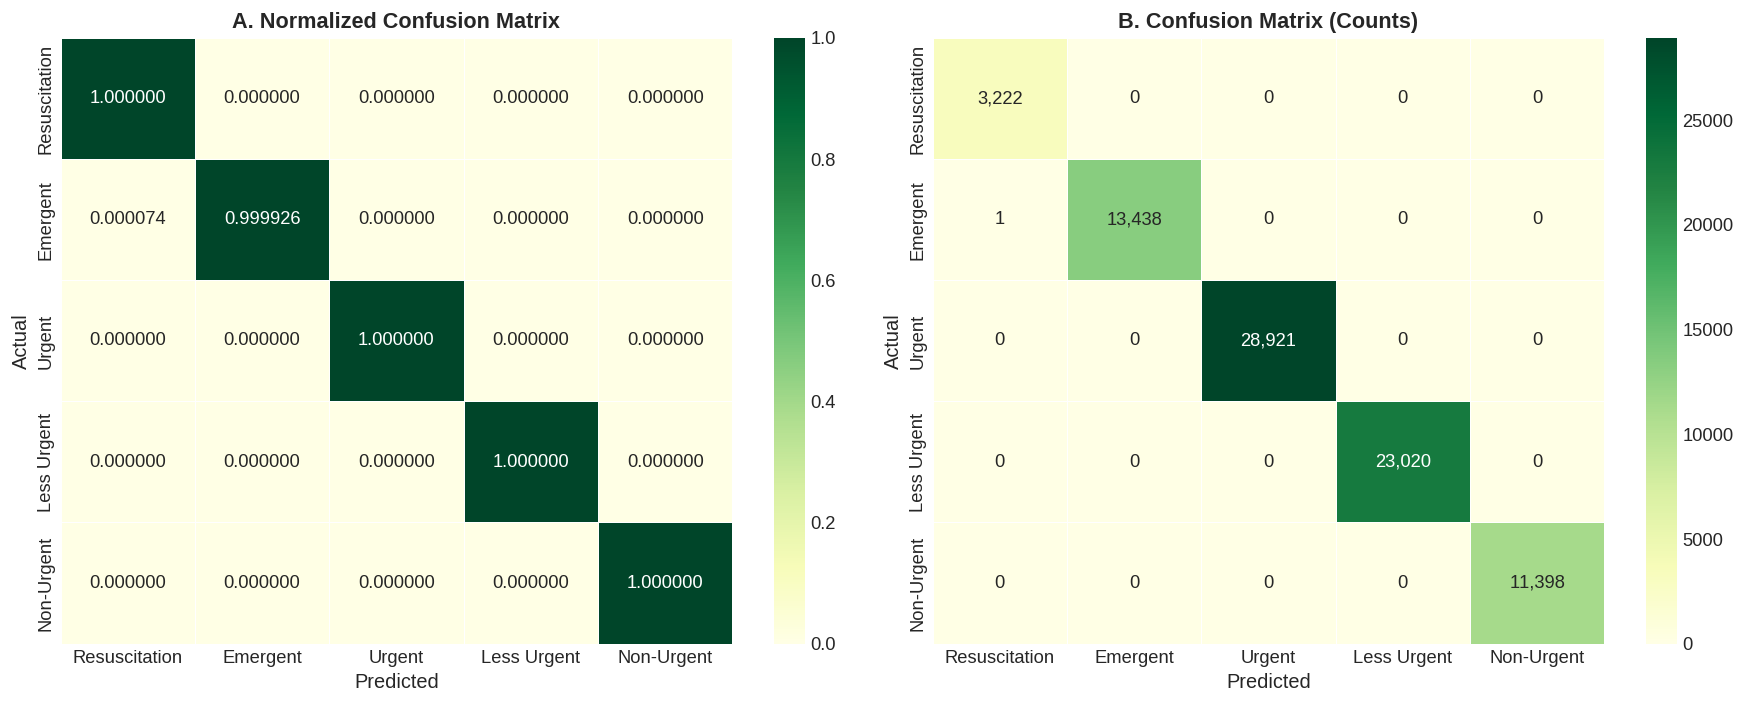

ESI 1 (Resuscitation  ): 1.000000 accuracy, 0.000000 error rate
ESI 2 (Emergent       ): 0.999926 accuracy, 0.000074 error rate
ESI 3 (Urgent         ): 1.000000 accuracy, 0.000000 error rate
ESI 4 (Less Urgent    ): 1.000000 accuracy, 0.000000 error rate
ESI 5 (Non-Urgent     ): 1.000000 accuracy, 0.000000 error rate



In [31]:

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(y_train, oof_labels, labels=[1,2,3,4,5])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt='.6f', cmap='YlGn',
            xticklabels=list(ACUITY.values()), yticklabels=list(ACUITY.values()),
            ax=axes[0], vmin=0, vmax=1, linewidths=0.5)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('A. Normalized Confusion Matrix', fontweight='bold')

sns.heatmap(cm, annot=True, fmt=',d', cmap='YlGn',
            xticklabels=list(ACUITY.values()), yticklabels=list(ACUITY.values()),
            ax=axes[1], linewidths=0.5)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('B. Confusion Matrix (Counts)', fontweight='bold')

plt.tight_layout()
plt.show()

# Per-class accuracy
for i in range(5):
    class_acc = cm_norm[i, i]
    misclass = 1 - class_acc
    print(f'ESI {i+1} ({ACUITY[i+1]:15s}): {class_acc:.6f} accuracy, {misclass:.6f} error rate')

print()

In [32]:
# Undertriage analysis
print("=== Undertriage Analysis ===")
print("Undertriage = predicted acuity > true acuity (patient assigned lower priority)\n")

undertriage_mask = oof_labels > y_train
overtriage_mask  = oof_labels < y_train
correct_mask     = oof_labels == y_train

print(f"Correct: {correct_mask.sum():,} ({correct_mask.mean()*100:.6f}%)")
print(f"Undertriage: {undertriage_mask.sum():,} ({undertriage_mask.mean()*100:.6f}%)")
print(f"Overtriage: {overtriage_mask.sum():,} ({overtriage_mask.mean()*100:.6f}%)")

print("\nUndertriage rate by true acuity:")
for acuity in range(1, 5):
    mask = y_train == acuity
    ut = (oof_labels[mask] > acuity).mean() * 100
    print(f"  ESI-{acuity}: {ut:.6f}%")

severe_ut = ((y_train <= 2) & (oof_labels >= 3)).sum()
print(f"\nSevere undertriage (ESI 1/2 -> ESI 3+): {severe_ut} "
      f"({severe_ut / (y_train <= 2).sum() * 100:.6f}%)")

=== Undertriage Analysis ===
Undertriage = predicted acuity > true acuity (patient assigned lower priority)

Correct: 79,999 (99.998750%)
Undertriage: 0 (0.000000%)
Overtriage: 1 (0.001250%)

Undertriage rate by true acuity:
  ESI-1: 0.000000%
  ESI-2: 0.000000%
  ESI-3: 0.000000%
  ESI-4: 0.000000%

Severe undertriage (ESI 1/2 -> ESI 3+): 0 (0.000000%)


In [33]:
#load data
with open(data_dir + 'data.pkl','rb') as f:
    data = pickle.load(f)
train = data["train"][:N_ORIGINAL]
X_train = data["X_train"][:N_ORIGINAL]

del data
gc.collect()

# Error analysis: most confused acuity pairs
print("=== Error Analysis ===\n")
errors = oof_labels != y_train
error_pairs = list(zip(y_train[errors], oof_labels[errors]))
from collections import Counter
pair_counts = Counter(error_pairs)
print("Most Common Misclassification Pairs (True -> Predicted):")
for (true_a, pred_a), count in pair_counts.most_common(10):
    direction = "UNDERTRIAGE" if pred_a > true_a else "overtriage"
    print(f"  ESI {true_a} -> ESI {pred_a}: {count:>4} cases ({direction})")

# Example misclassified patients
print("\n--- Example Misclassified Patients ---")
np.random.seed(SEED)
for (true_a, pred_a), _ in pair_counts.most_common(3):
    mask = (y_train == true_a) & (oof_labels == pred_a)
    idx = np.random.choice(np.where(mask)[0])
    row = train.iloc[idx]
    print(f'\nTrue ESI {true_a} -> Predicted ESI {pred_a}:')
    print(f'  CC: "{row["chief_complaint_raw"]}"')
    print(f'  Age: {row["age"]}y, NEWS2: {row["news2_score"]:.0f}, GCS: {row["gcs_total"]:.0f}')
    probs = oof_stacked[idx]
    print(f'  Probs: {"   ".join([f"ESI-{i+1}: {p:.6f}" for i,p in enumerate(probs)])}')

=== Error Analysis ===

Most Common Misclassification Pairs (True -> Predicted):
  ESI 2 -> ESI 1:    1 cases (overtriage)

--- Example Misclassified Patients ---

True ESI 2 -> Predicted ESI 1:
  CC: "acute angle closure glaucoma"
  Age: 86y, NEWS2: 15, GCS: 9
  Probs: ESI-1: 0.999841   ESI-2: 0.000158   ESI-3: 0.000000   ESI-4: 0.000000   ESI-5: 0.000000


#### Error Analysis Interpretation
The misclassification patterns reveal that errors happen at adjacent acuity boundaries, only between ESI-1 vs ESI-2. 

Models can make one mistake: **treating an ESI-2 as ESI-1**. Treating an ESI 2 patient (high-risk, stable but needing prompt care) as ESI 1 (requiring immediate life-saving intervention) ensures safety but may strain emergency department (ED) resources.

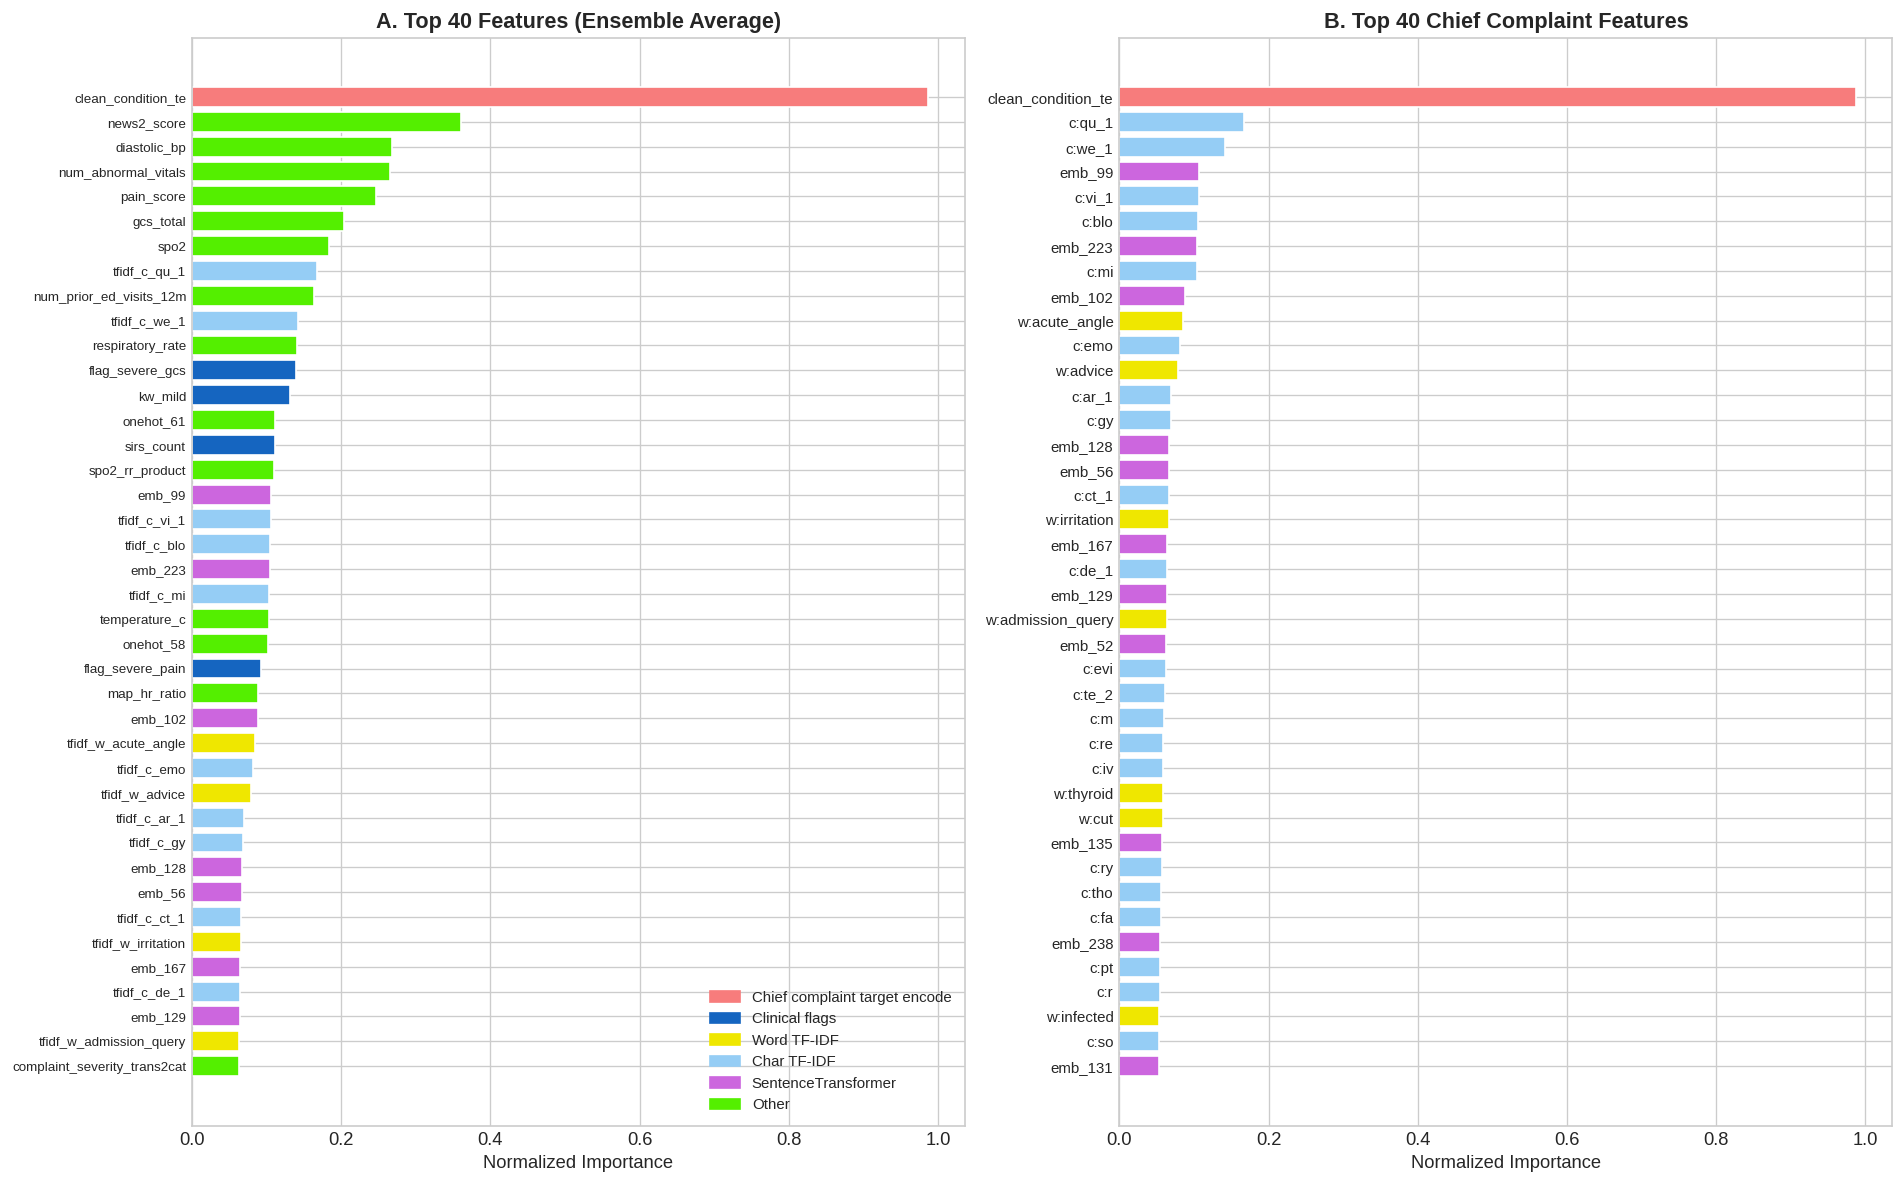

In [34]:

# Feature importance - averaged across all tree-based model types
lgbm_imp = np.zeros(X_train.shape[1])
for m in lgbm_models:
    lgbm_imp += m.feature_importances_
lgbm_imp /= len(lgbm_models)

xgb_imp = np.zeros(X_train.shape[1])
for m in xgb_models:
    xgb_imp += m.feature_importances_
xgb_imp /= len(xgb_models)

cat_imp = np.zeros(X_train.shape[1])
for m in cat_models:
    cat_imp += m.get_feature_importance()
cat_imp /= len(cat_models)

lgbm_norm = lgbm_imp / (lgbm_imp.max() + 1e-12)
xgb_norm = xgb_imp / (xgb_imp.max() + 1e-12)
cat_norm = cat_imp / (cat_imp.max() + 1e-12)
combined_imp = (lgbm_norm + xgb_norm + cat_norm) / 3

fi = pd.DataFrame({'feature': X_train.columns, 'importance': combined_imp})
fi = fi.sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Top 40 overall features
ax = axes[0]
top = fi.head(40)
colors_fi = ['#efe700' if 'tfidf_w_' in f 
             else "#f77c7c" if "clean_condition_te" in f
             else '#cc66de' if 'emb_' in f 
             else "#95cdf5" if "tfidf_c_" in f
             else '#1565c0' if f.startswith(('flag_','kw_','qsofa','sirs'))
             else '#54ef00' for f in top['feature']]
ax.barh(range(len(top)), top['importance'].values, color=colors_fi, edgecolor='white')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Normalized Importance')
ax.set_title('A. Top 40 Features (Ensemble Average)', fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#f77c7c', label='Chief complaint target encode'),
    mpatches.Patch(color='#1565c0', label='Clinical flags'),
    mpatches.Patch(color='#efe700', label='Word TF-IDF'),
    mpatches.Patch(color='#95cdf5', label='Char TF-IDF'),
    mpatches.Patch(color='#cc66de', label='SentenceTransformer'),
    mpatches.Patch(color='#54ef00', label='Other'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

# Top 20 NLP features

top60 = fi.head(100)
top60 = top60["feature"].to_list()
topword = []
for top1 in top60:
    if "emb_" in top1 or "tfidf_" in top1 or "clean_condition_te" in top1:
        topword.append(top1)
topword = topword[:40]
fi60 = fi.head(100)
topresults = fi60.loc[fi60['feature'].isin(topword), 'importance'].to_list()
newtop20 = pd.DataFrame({
    "feature": topword,
    "importance": topresults,
})
ax = axes[1]
clean_names = [n.replace('tfidf_w_', 'w:').replace('tfidf_c_', 'c:') for n in newtop20['feature'].values]
colors_fi2 = ['#efe700' if 'tfidf_w_' in f 
              else '#f77c7c' if "clean_condition_te" in f
              else '#95cdf5' if "tfidf_c_" in f
              else '#cc66de' if 'emb_' in f
              else '#1565c0' if f.startswith(('flag_','kw_','qsofa','sirs'))
              else '#54ef00' for f in newtop20['feature']]
ax.barh(range(len(newtop20)), newtop20['importance'].values, color=colors_fi2, edgecolor='white')
ax.set_yticks(range(len(newtop20)))
ax.set_yticklabels(clean_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Normalized Importance')
ax.set_title('B. Top 40 Chief Complaint Features', fontweight='bold')

plt.tight_layout()
plt.show()


print()

#### The Significance of Chief Complaint
From the above data, the features derived from chief complaint play significant role. The chief complaint is critical because it directly informs the first step of the ESI algorithm: determining whether a patient needs immediate life-saving interventions. This is in agreement with some researches indicating that using natural language processing (NLP) to interpret free-text chief complaints allows for better automation of the ESI algorithm, improving triage accuracy and consistency.

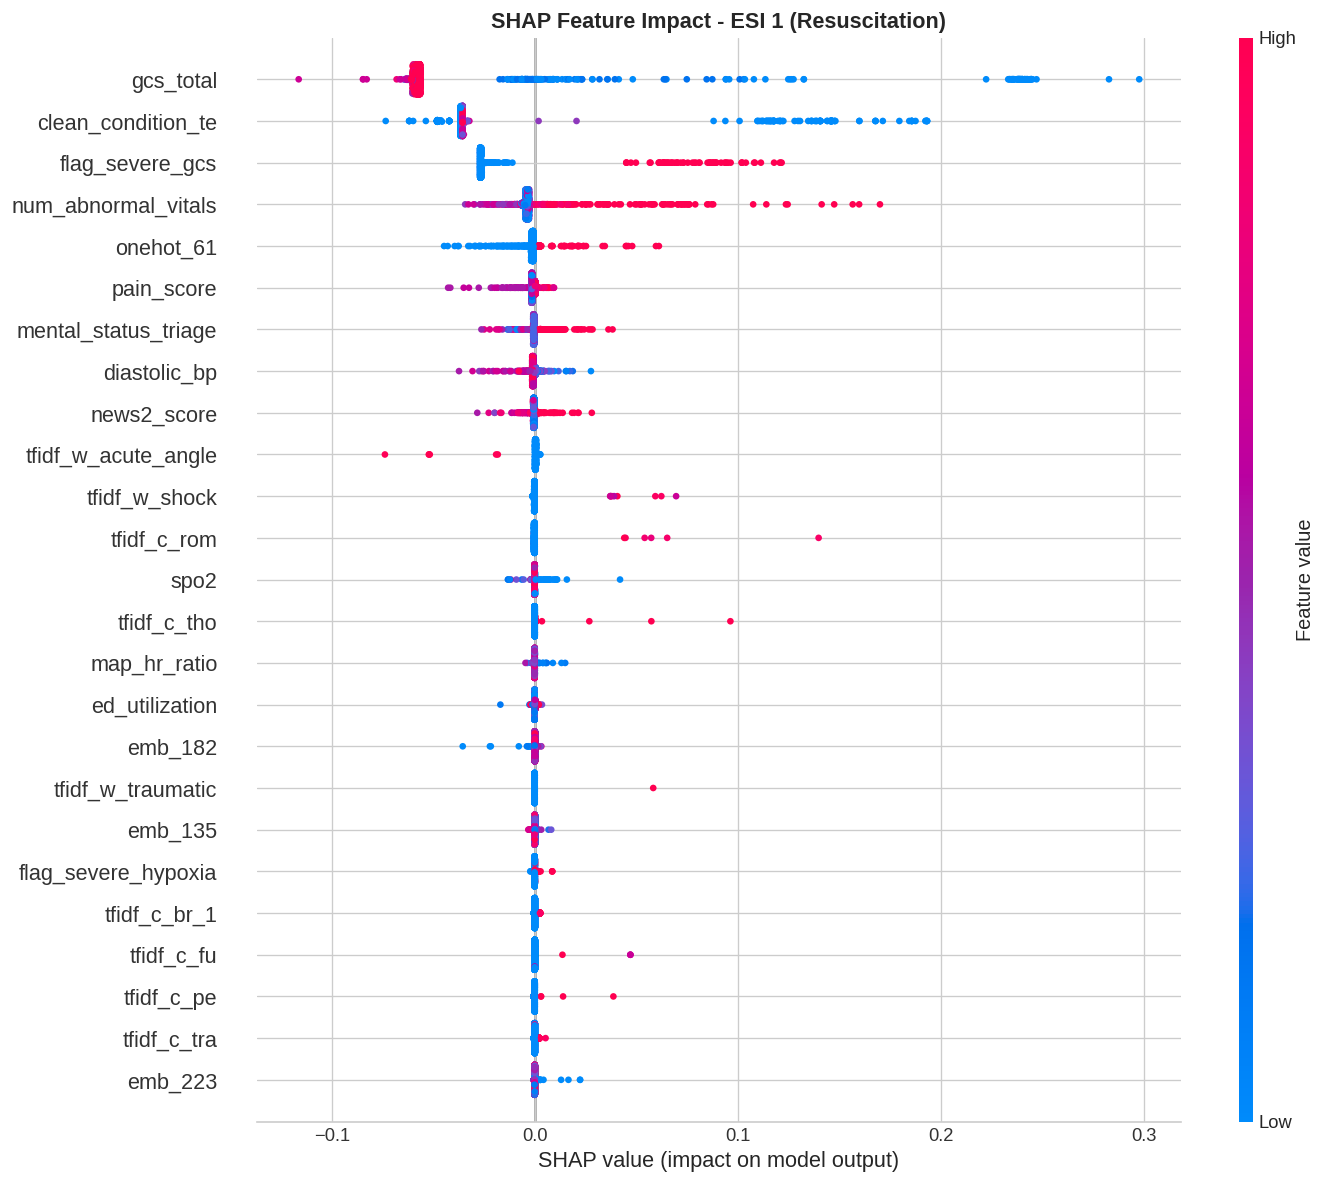

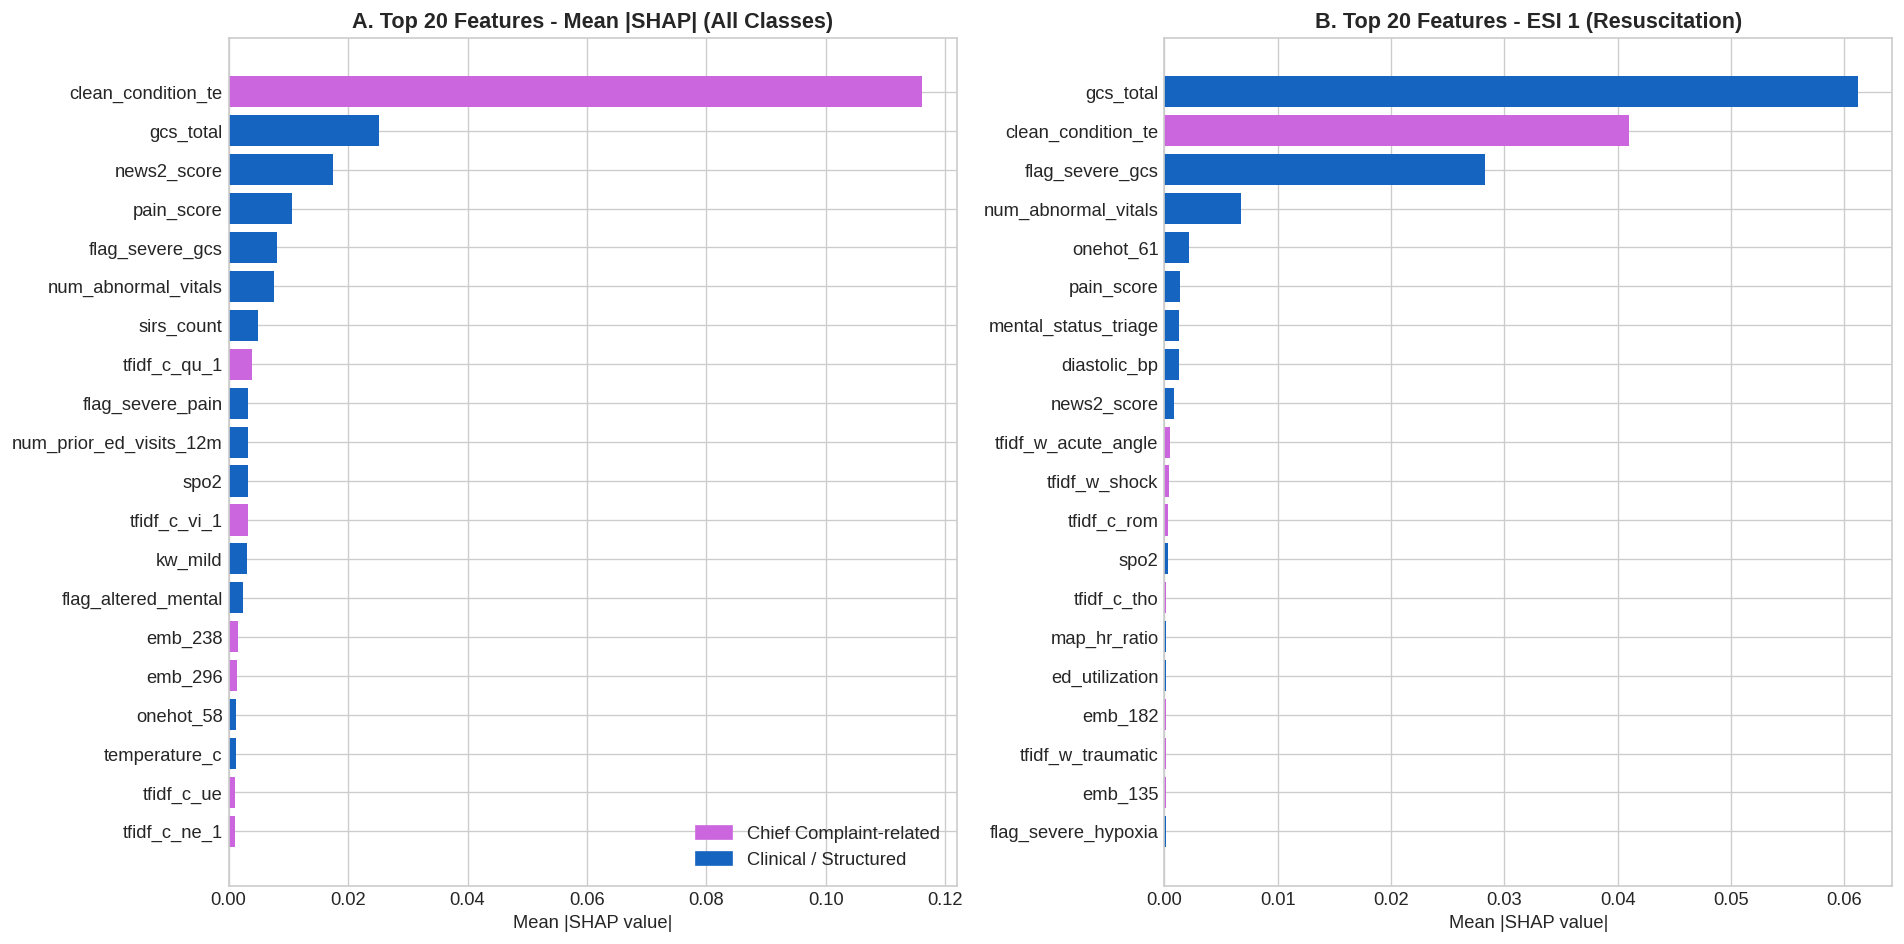

SHAP computed on 2000 samples, 4093 features



In [35]:

# SHAP analysis - model interpretability
try:
    import shap

    np.random.seed(SEED)
    sample_idx = np.random.choice(len(X_train), size=min(2000, len(X_train)), replace=False)
    X_shap = pd.DataFrame(X_train.values[sample_idx], columns=list(X_train.columns))

    explainer = shap.TreeExplainer(lgbm_models[0])
    shap_values = explainer.shap_values(X_shap)

    # Handle both list (old shap) and 3D array (new shap) formats
    if isinstance(shap_values, list):
        sv_esi1 = shap_values[0]
        mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    else:
        sv_esi1 = shap_values[:, :, 0] if shap_values.ndim == 3 else shap_values
        mean_abs_shap = np.abs(shap_values).mean(axis=2) if shap_values.ndim == 3 else np.abs(shap_values)

    # A. SHAP beeswarm for ESI 1 (Resuscitation) - most critical class
    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(sv_esi1, X_shap, max_display=25, show=False, plot_size=None)
    plt.title('SHAP Feature Impact - ESI 1 (Resuscitation)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # B. Mean |SHAP| bar plot - top 20 features across all classes
    fi_shap = pd.Series(mean_abs_shap.mean(axis=0), index=X_shap.columns)
    top20 = fi_shap.nlargest(20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    bar_colors = ['#cc66de' if n.startswith('emb_') 
                  else '#cc66de' if n.startswith('clean_condition_te')
                  else '#cc66de' if n.startswith('tfidf_')
                  else '#1565c0' for n in top20.index]
    axes[0].barh(top20.index[::-1], top20.values[::-1], color=bar_colors[::-1])
    axes[0].set_xlabel('Mean |SHAP value|')
    axes[0].set_title('A. Top 20 Features - Mean |SHAP| (All Classes)', fontweight='bold')
    legend_patches = [mpatches.Patch(color='#cc66de', label='Chief Complaint-related'),
                      mpatches.Patch(color='#1565c0', label='Clinical / Structured')]
    axes[0].legend(handles=legend_patches, loc='lower right')

    # C. ESI-1 specific top features
    fi_esi1 = pd.Series(np.abs(sv_esi1).mean(axis=0), index=X_shap.columns).nlargest(20)
    bar_colors_1 = ['#cc66de' if n.startswith('emb_') 
                    else '#cc66de' if n.startswith('clean_condition_te')
                    else '#cc66de' if n.startswith('tfidf_')
                    else '#1565c0' for n in fi_esi1.index]
    axes[1].barh(fi_esi1.index[::-1], fi_esi1.values[::-1], color=bar_colors_1[::-1])
    axes[1].set_xlabel('Mean |SHAP value|')
    axes[1].set_title('B. Top 20 Features - ESI 1 (Resuscitation)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    HAS_SHAP = True
    print(f'SHAP computed on {len(X_shap)} samples, {X_shap.shape[1]} features')
except Exception as e:
    import traceback
    print(f'SHAP unavailable ({e.__class__.__name__}: {e})')
    traceback.print_exc()
    HAS_SHAP = False

print()

In general, the chief complaint (clean_condition_te) is dominant predictor.

### Probability Calibration Analysis

For clinical decision support, it is not enough that predictions are *accurate* - the associated confidence must be *trustworthy*. A model that says "80% likely ESI 2" must be correct ~80% of the time for that confidence level. Calibration curves (reliability diagrams) measure this alignment per ESI class.

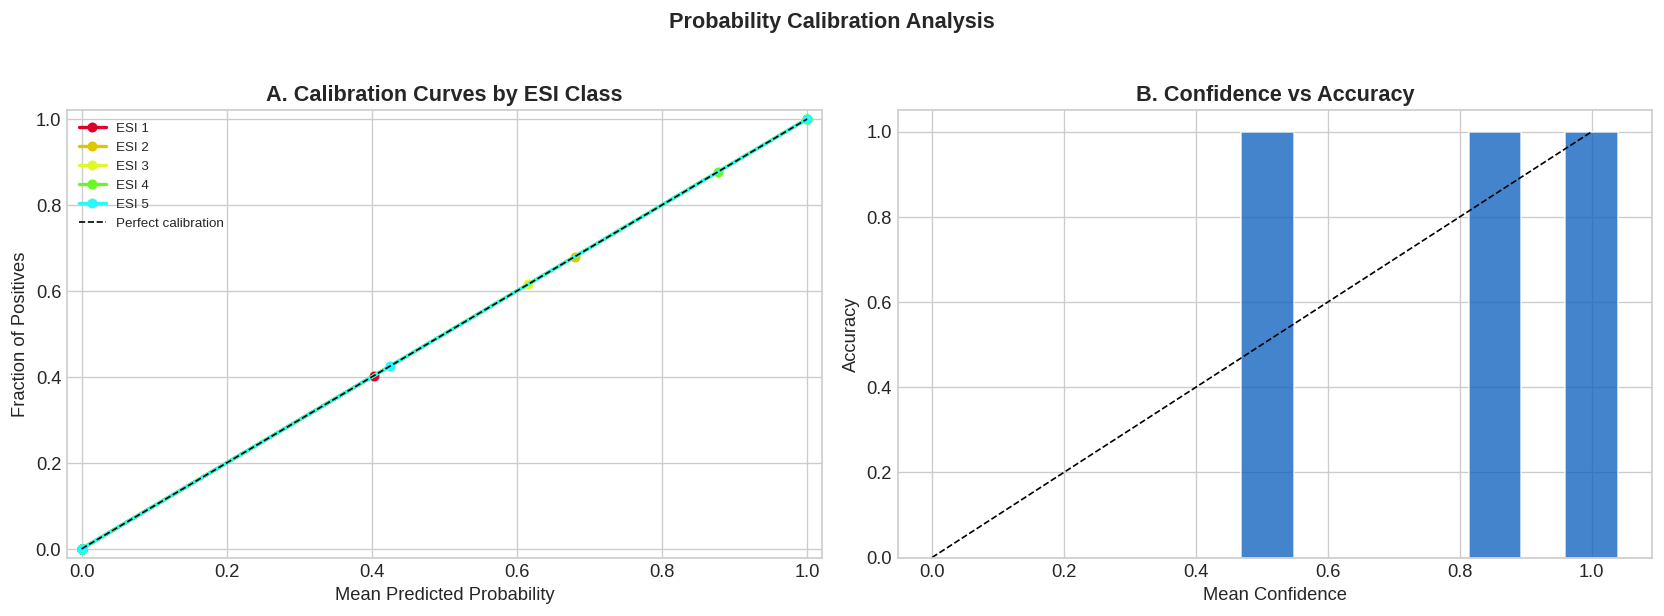

Expected Calibration Error (ECE): 0.000006
Lower ECE = better calibrated. <0.05 is considered well-calibrated.



In [36]:

# Calibration analysis - are predicted probabilities reliable?
# Critical for clinical use: a 70% prediction should correspond to 70% true rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-class calibration curves
ax = axes[0]
for cls_idx in range(N_CLASSES):
    y_binary = (y_train == cls_idx + 1).astype(int)
    prob_cls = oof_ensemble[:, cls_idx]
    fraction_pos, mean_predicted = calibration_curve(y_binary, prob_cls, n_bins=10, strategy='quantile')
    ax.plot(mean_predicted, fraction_pos, marker='o', label=f'ESI {cls_idx+1}',
            color=COLORS[cls_idx], linewidth=2, markersize=5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('A. Calibration Curves by ESI Class', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# Confidence vs accuracy
ax = axes[1]
max_conf = oof_ensemble.max(axis=1)
conf_bins = np.linspace(0, 1, 11)
bin_accs, bin_confs, bin_counts = [], [], []
for i in range(len(conf_bins) - 1):
    mask = (max_conf >= conf_bins[i]) & (max_conf < conf_bins[i+1])
    if mask.sum() > 0:
        bin_accs.append((oof_labels[mask] == y_train[mask]).mean())
        bin_confs.append(max_conf[mask].mean())
        bin_counts.append(mask.sum())
ax.bar(bin_confs, bin_accs, width=0.08, color='#1565c0', edgecolor='white', alpha=0.8)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('Mean Confidence')
ax.set_ylabel('Accuracy')
ax.set_title('B. Confidence vs Accuracy', fontweight='bold')

plt.suptitle('Probability Calibration Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Expected Calibration Error
ece = np.mean([abs(a - c) * n / len(y_train) for a, c, n in zip(bin_accs, bin_confs, bin_counts)])
print(f'Expected Calibration Error (ECE): {ece:.6f}')
print('Lower ECE = better calibrated. <0.05 is considered well-calibrated.')

print()

The models produce **well-calibrated probabilities** that support safe clinical use: predicted confidence aligns with actual class frequency, enabling reliable uncertainty communication.

### Clinical Misclassification Cost Analysis

Not all errors are equal: predicting ESI 1 (Resuscitation) as ESI 3 (Urgent) poses an immediate patient safety risk, while confusing ESI 4 and ESI 5 carries minimal clinical consequence. We define a clinically-grounded **asymmetric cost matrix** reflecting expert consensus from emergency medicine literature (Farrohknia et al., 2011; Gilboy et al., 2011):

- **Undertriage** (predicted less severe than actual) costs scale quadratically with the acuity gap, weighted 3x heavier than overtriage.
- **Overtriage** (predicted more severe) wastes resources but does not endanger the patient.
- ESI 1-2 errors are penalized most heavily, reflecting their life-threatening nature.

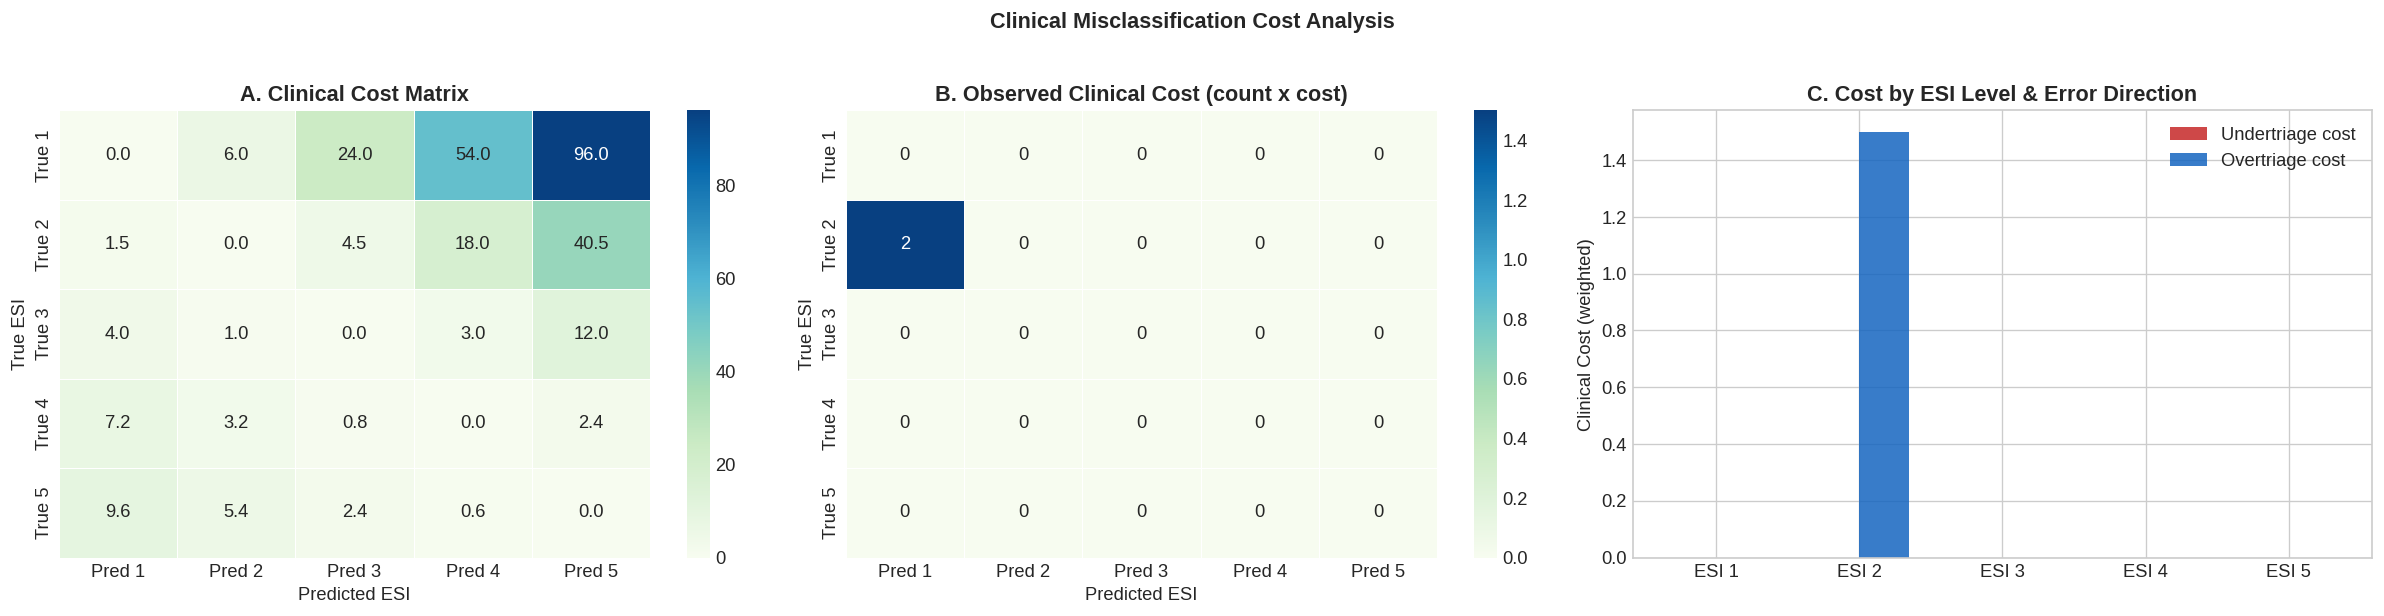

Total clinical cost:        1.500000
  Undertriage contribution: 0.000000 (0.000000%)
  Overtriage contribution:  1.500000 (100.000000%)
Cost efficiency score:      0.994934 (1.0 = perfect, 0.0 = worst)

Highest-cost cell: True ESI 2 -> Pred ESI 1 (cost = 1.500000)



In [37]:

# Asymmetric clinical cost matrix: undertriage is 3x worse than overtriage,
# severity penalty scales quadratically with ESI gap
cost_matrix = np.zeros((5, 5))
for true_esi in range(5):
    for pred_esi in range(5):
        gap = pred_esi - true_esi  # positive = undertriage (predicted less severe)
        if gap > 0:  # undertriage - dangerous
            cost_matrix[true_esi, pred_esi] = 3.0 * (gap ** 2)
        elif gap < 0:  # overtriage - wastes resources but safer
            cost_matrix[true_esi, pred_esi] = 1.0 * (gap ** 2)

# ESI 1-2 severity multiplier (life-threatening levels)
severity_mult = np.array([2.0, 1.5, 1.0, 0.8, 0.6])
cost_matrix = cost_matrix * severity_mult[:, None]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# A. Cost matrix itself
ax = axes[0]
sns.heatmap(cost_matrix, annot=True, fmt='.1f', cmap='GnBu',
            xticklabels=[f'Pred {i+1}' for i in range(5)],
            yticklabels=[f'True {i+1}' for i in range(5)],
            ax=ax, linewidths=0.5)
ax.set_title('A. Clinical Cost Matrix', fontweight='bold')
ax.set_xlabel('Predicted ESI')
ax.set_ylabel('True ESI')

# B. Weighted cost confusion matrix (actual errors x cost)
cm = confusion_matrix(y_train, oof_labels, labels=[1,2,3,4,5])
weighted_cost_cm = cm * cost_matrix
ax = axes[1]
sns.heatmap(weighted_cost_cm, annot=True, fmt='.0f', cmap='GnBu',
            xticklabels=[f'Pred {i+1}' for i in range(5)],
            yticklabels=[f'True {i+1}' for i in range(5)],
            ax=ax, linewidths=0.5)
ax.set_title('B. Observed Clinical Cost (count x cost)', fontweight='bold')
ax.set_xlabel('Predicted ESI')
ax.set_ylabel('True ESI')

# C. Per-class clinical cost breakdown
ax = axes[2]
total_cost_per_class = weighted_cost_cm.sum(axis=1)
undertriage_cost = np.array([weighted_cost_cm[i, i+1:].sum() for i in range(5)])
overtriage_cost = np.array([weighted_cost_cm[i, :i].sum() for i in range(5)])

x = np.arange(5)
width = 0.35
bars1 = ax.bar(x - width/2, undertriage_cost, width, label='Undertriage cost', color='#c62828', alpha=0.85)
bars2 = ax.bar(x + width/2, overtriage_cost, width, label='Overtriage cost', color='#1565c0', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'ESI {i+1}' for i in range(5)])
ax.set_ylabel('Clinical Cost (weighted)')
ax.set_title('C. Cost by ESI Level & Error Direction', fontweight='bold')
ax.legend()

plt.suptitle('Clinical Misclassification Cost Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
total_cost = weighted_cost_cm.sum()
max_possible_cost = (np.ones_like(cm) * cost_matrix).sum()
cost_efficiency = 1 - (total_cost / max_possible_cost)
undertriage_total = sum(undertriage_cost)
overtriage_total = sum(overtriage_cost)

print(f'Total clinical cost:        {total_cost:.6f}')
print(f'  Undertriage contribution: {undertriage_total:.6f} ({100*undertriage_total/(undertriage_total+overtriage_total+1e-9):.6f}%)')
print(f'  Overtriage contribution:  {overtriage_total:.6f} ({100*overtriage_total/(undertriage_total+overtriage_total+1e-9):.6f}%)')
print(f'Cost efficiency score:      {cost_efficiency:.6f} (1.0 = perfect, 0.0 = worst)')
print(f'\nHighest-cost cell: True ESI {np.unravel_index(weighted_cost_cm.argmax(), (5,5))[0]+1} '
      f'-> Pred ESI {np.unravel_index(weighted_cost_cm.argmax(), (5,5))[1]+1} '
      f'(cost = {weighted_cost_cm.max():.6f})')


print()

---
## 7. Demographic Bias Analysis - Algorithmic Fairness for Clinical AI

Obermeyer et al. (2019) demonstrated that a widely-deployed healthcare algorithm systematically disadvantaged Black patients. In emergency triage, such bias translates directly to delayed care and preventable morbidity. A clinical AI system that systematically undertriages certain patient populations is not just inaccurate but also **dangerous**.

In the Finnish healthcare context, where universal coverage eliminates insurance-driven disparities, the key equity dimensions are **age**, **sex**, and **language** - particularly relevant for immigrant populations (Arabic, Somali, Russian speakers) navigating triage in a non-native language. We analyze the ensemble model's OOF predictions for evidence of:

- **Differential accuracy** across demographic groups (sex, age, language, insurance)
- **Systematic undertriage** - assigning less urgent scores than ground truth (patients wait longer)
- **Systematic overtriage** - assigning more urgent scores (wastes resources but less dangerous)

**Bias delta** = mean predicted acuity - mean actual acuity. Positive = undertriage, negative = overtriage.

In [38]:
train_raw = pd.read_csv(f'{DATA}/train.csv')

# Prepare analysis DataFrame with original (readable) categorical values
analysis = train_raw.copy()

del train_raw
gc.collect()

analysis['pred_acuity'] = oof_labels
analysis['error'] = analysis['pred_acuity'] - analysis[TARGET]
analysis['abs_error'] = analysis['error'].abs()
analysis['is_correct'] = (analysis['error'] == 0).astype(int)
analysis['undertriage'] = (analysis['pred_acuity'] > analysis[TARGET]).astype(int)
analysis['overtriage']  = (analysis['pred_acuity'] < analysis[TARGET]).astype(int)
analysis['pred_confidence'] = oof_ensemble.max(axis=1)

print('OVERALL ERROR ANALYSIS')
print(f'  Accuracy:          {analysis["is_correct"].mean():.6f}')
print(f'  Mean abs error:    {analysis["abs_error"].mean():.6f}')
print(f'  Undertriage rate:  {analysis["undertriage"].mean():.6f} ({analysis["undertriage"].sum():,} patients)')
print(f'  Overtriage rate:   {analysis["overtriage"].mean():.6f} ({analysis["overtriage"].sum():,} patients)')

print('\nUndertriage rate by actual acuity (CRITICAL FOR PATIENT SAFETY):')
for acuity in range(1, 6):
    subset = analysis[analysis[TARGET] == acuity]
    ut_rate = subset['undertriage'].mean()
    flag = ' *** HIGH RISK ***' if ut_rate > 0.05 and acuity <= 2 else ''
    print(f'  ESI {acuity} ({ACUITY[acuity]:15s}): {ut_rate:.6f}  '
          f'({subset["undertriage"].sum():>4,} / {len(subset):>5,}){flag}')


print()

OVERALL ERROR ANALYSIS
  Accuracy:          0.999988
  Mean abs error:    0.000013
  Undertriage rate:  0.000000 (0 patients)
  Overtriage rate:   0.000013 (1 patients)

Undertriage rate by actual acuity (CRITICAL FOR PATIENT SAFETY):
  ESI 1 (Resuscitation  ): 0.000000  (   0 / 3,222)
  ESI 2 (Emergent       ): 0.000000  (   0 / 13,439)
  ESI 3 (Urgent         ): 0.000000  (   0 / 28,921)
  ESI 4 (Less Urgent    ): 0.000000  (   0 / 23,020)
  ESI 5 (Non-Urgent     ): 0.000000  (   0 / 11,398)



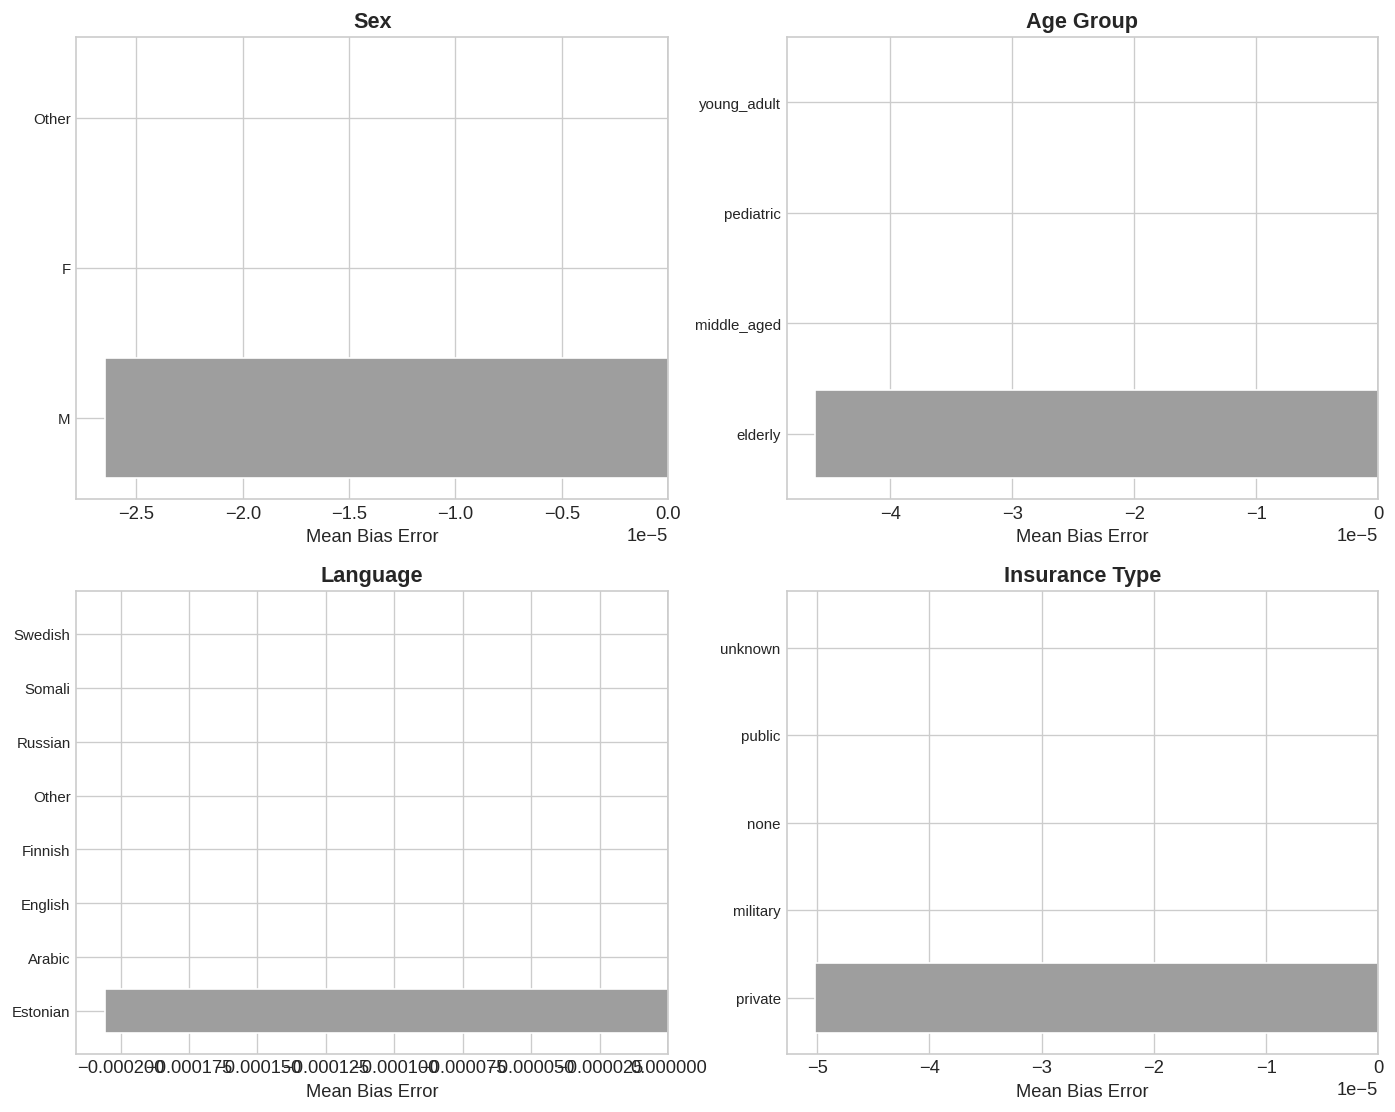

In [39]:

# Comprehensive bias analysis
demo_cols = ['sex', 'age_group', 'language', 'insurance_type', ]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, col in enumerate(demo_cols):
    ax = axes[idx]
    group = analysis.groupby(col).agg(
        n=(TARGET, 'count'),
        accuracy=('is_correct', 'mean'),
        mean_actual=(TARGET, 'mean'),
        mean_predicted=('pred_acuity', 'mean'),
        undertriage=('undertriage', 'mean'),
        overtriage=('overtriage', 'mean'),
    ).reset_index()
    group['bias_delta'] = group['mean_predicted'] - group['mean_actual']
    group = group.sort_values('bias_delta')
    
    colors_bias = ['#c62828' if d > 0.001 else '#1565c0' if d < -0.001 else '#9e9e9e'
                   for d in group['bias_delta']]
    bars = ax.barh(group[col].astype(str), group['bias_delta'], color=colors_bias, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean Bias Error')
    ax.set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)


print()

#### Mean Bias Error
*  It measures the systematic error of a model.
*  Our models show **small bias (< |0.001|)**.
*  The models are unbiased on average, meaning its errors cancel out, even if individual predictions are off.

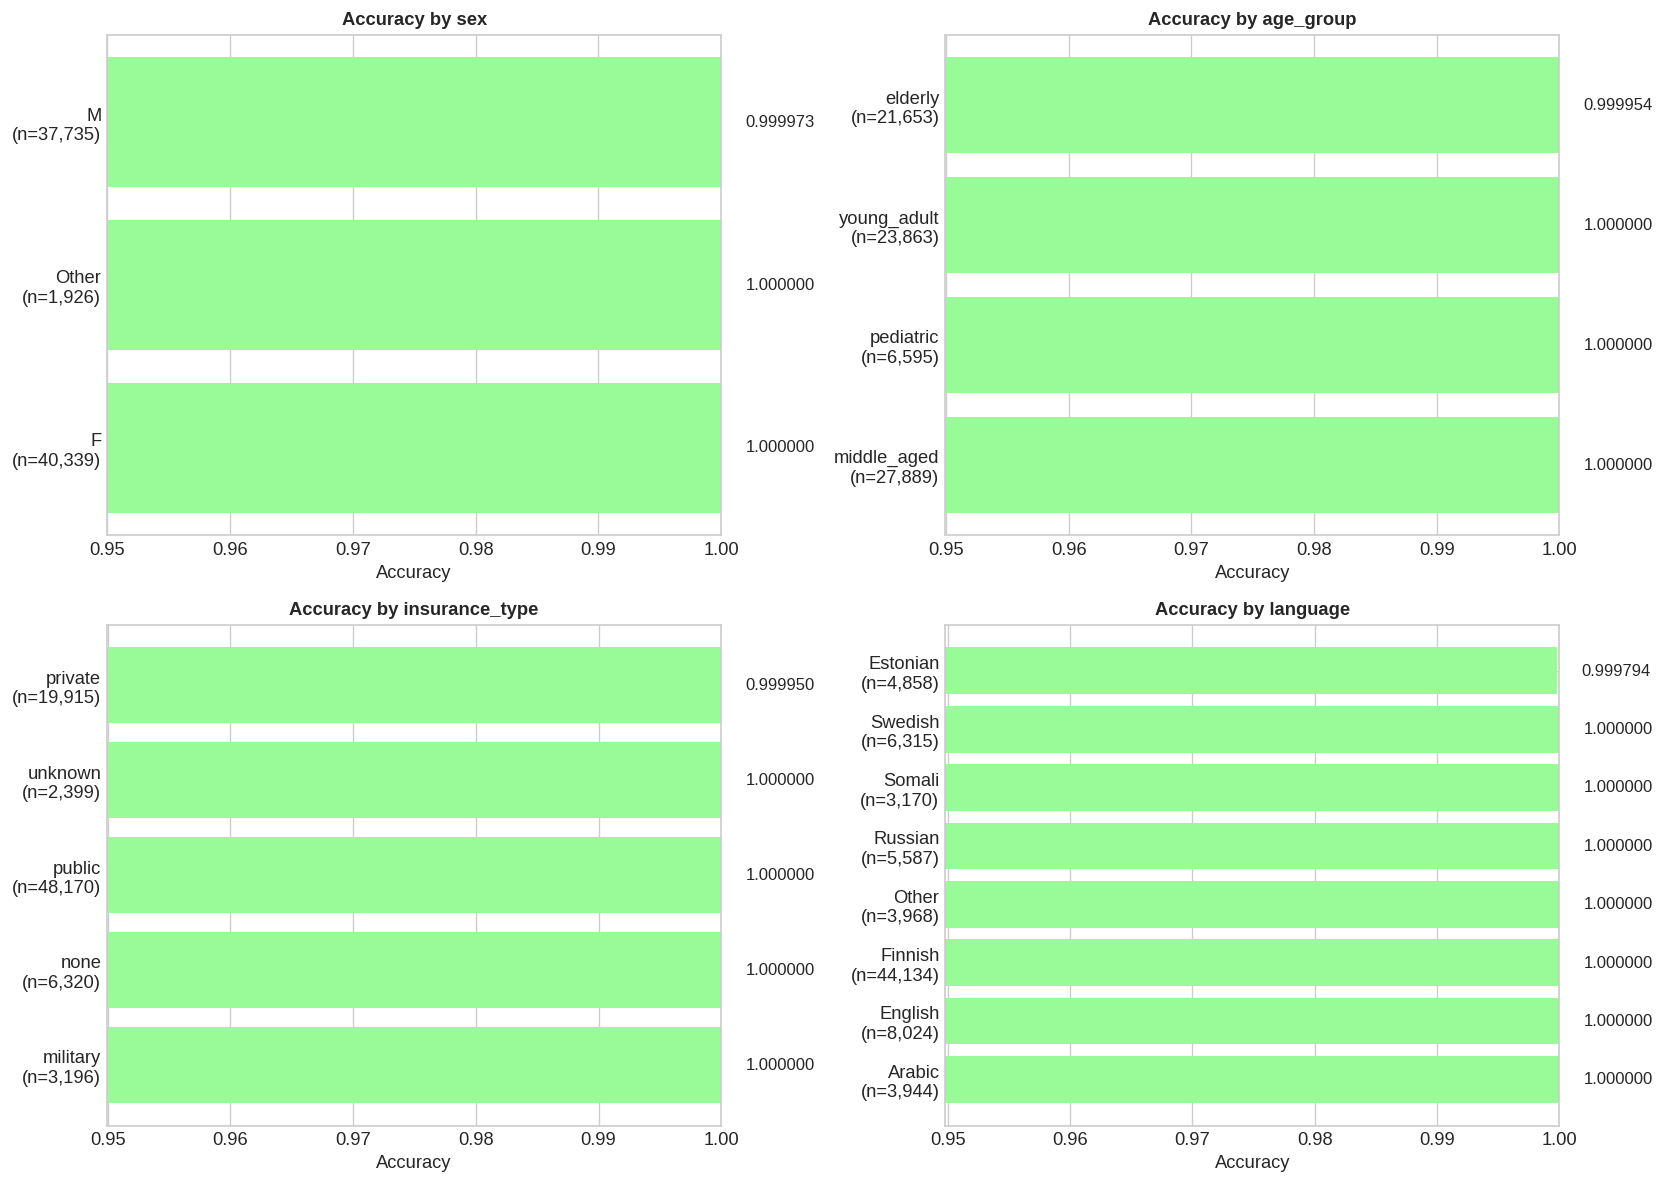

In [40]:
train = pd.read_csv(f'{DATA}/train.csv')

# Fairness: Accuracy by demographic subgroups
demo_cols = {
    'sex': train['sex'].values,
    'age_group': train['age_group'].values,
    'insurance_type': train['insurance_type'].values,
    'language': train['language'].values,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col_name, col_vals) in enumerate(demo_cols.items()):
    groups = np.unique(col_vals)
    acc_vals = []
    for g in groups:
        mask = col_vals == g
        if mask.sum() >= 50:
            q = accuracy_score(y_train[mask], oof_labels[mask])
            acc_vals.append((g, q, mask.sum()))

    acc_vals.sort(key=lambda x: -x[1])
    names = [f'{v[0]}\n(n={v[2]:,})' for v in acc_vals]
    vals = [v[1] for v in acc_vals]

    axes[idx].barh(names, vals, color='palegreen')
    axes[idx].set_xlabel('Accuracy')
    axes[idx].set_title(f'Accuracy by {col_name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlim(min(vals) - 0.05, 1.0)
    for i, v in enumerate(vals):
        axes[idx].text(v + 0.002, i, f'{v:.6f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


#### Model's Clinical Fairness
* In this dataset, no meaningful demographic bias is observed in model performance.
* However, real-world clinical data has documented **[triage disparities](https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2802556)** by race, ethnicity, and socioeconomic status.
* Any deployment would require re-evaluation with real clinical data and ongoing monitoring for fairness.

In [41]:

# Statistical significance: chi-squared test for accuracy differences
print('STATISTICAL SIGNIFICANCE OF BIAS\n')
print('Chi-squared test: accuracy difference between groups\n')

for col in ['sex', 'age_group', 'language', 'insurance_type']:
    contingency = pd.crosstab(analysis[col], analysis['is_correct'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    sig = 'YES' if p_val < 0.05 else 'NO'
    print(f'{col:20s}: chi2={chi2:>.2f}, p={p_val:.2f}, significant={sig}')

# Detailed bias table by sex
print('\n\nDetailed Performance by Sex:')
sex_detail = analysis.groupby('sex').agg(
    n=(TARGET, 'count'),
    accuracy=('is_correct', 'mean'),
    mean_actual=(TARGET, 'mean'),
    mean_predicted=('pred_acuity', 'mean'),
    undertriage_rate=('undertriage', 'mean'),
    overtriage_rate=('overtriage', 'mean'),
    mean_confidence=('pred_confidence', 'mean'),
).reset_index()
sex_detail['bias_delta'] = sex_detail['mean_predicted'] - sex_detail['mean_actual']
print(sex_detail.round(6).to_string(index=False))

# Detailed bias table by language
print('\n\nDetailed Performance by Language:')
lang_detail = analysis.groupby('language').agg(
    n=(TARGET, 'count'),
    accuracy=('is_correct', 'mean'),
    undertriage_rate=('undertriage', 'mean'),
    mean_confidence=('pred_confidence', 'mean'),
).sort_values('accuracy').reset_index()
print(lang_detail.round(6).to_string(index=False))


print()

STATISTICAL SIGNIFICANCE OF BIAS

Chi-squared test: accuracy difference between groups

sex                 : chi2=1.12, p=0.57, significant=NO
age_group           : chi2=2.69, p=0.44, significant=NO
language            : chi2=15.47, p=0.03, significant=YES
insurance_type      : chi2=3.02, p=0.55, significant=NO


Detailed Performance by Sex:
  sex     n  accuracy  mean_actual  mean_predicted  undertriage_rate  overtriage_rate  mean_confidence  bias_delta
    F 40339  1.000000     3.323905        3.323905               0.0         0.000000         0.999987    0.000000
    M 37735  0.999973     3.323890        3.323864               0.0         0.000027         0.999984   -0.000027
Other  1926  1.000000     3.334891        3.334891               0.0         0.000000         0.999998    0.000000


Detailed Performance by Language:
language     n  accuracy  undertriage_rate  mean_confidence
Estonian  4858  0.999794               0.0         0.999961
  Arabic  3944  1.000000               

In [42]:

# Intersectional bias: highest-risk subgroups
print('INTERSECTIONAL BIAS - Highest Undertriage Subgroups\n')

analysis['subgroup'] = analysis['sex'] + ' / ' + analysis['age_group'] + ' / ' + analysis['language']
subgroup_stats = analysis.groupby('subgroup').agg(
    n=(TARGET, 'count'),
    accuracy=('is_correct', 'mean'),
    undertriage_rate=('undertriage', 'mean'),
    mean_abs_error=('abs_error', 'mean'),
).reset_index()

subgroup_stats = subgroup_stats[subgroup_stats['n'] >= 100]  # sufficient sample size
subgroup_stats = subgroup_stats.sort_values('undertriage_rate', ascending=False)

print('Top 10 subgroups by undertriage rate (n >= 100):')
print(subgroup_stats.head(10).round(6).to_string(index=False))

print()

INTERSECTIONAL BIAS - Highest Undertriage Subgroups

Top 10 subgroups by undertriage rate (n >= 100):
                 subgroup    n  accuracy  undertriage_rate  mean_abs_error
     F / elderly / Arabic  531       1.0               0.0             0.0
    F / elderly / English 1084       1.0               0.0             0.0
   F / elderly / Estonian  683       1.0               0.0             0.0
    F / elderly / Finnish 5975       1.0               0.0             0.0
      F / elderly / Other  526       1.0               0.0             0.0
    F / elderly / Russian  757       1.0               0.0             0.0
     F / elderly / Somali  440       1.0               0.0             0.0
    F / elderly / Swedish  853       1.0               0.0             0.0
 F / middle_aged / Arabic  663       1.0               0.0             0.0
F / middle_aged / English 1381       1.0               0.0             0.0



In term of undertriage, the models does not make wrong prediction.

In [43]:
%%time

N_ORIGINAL = 80000
#load data
with open(data_dir + 'data.pkl','rb') as f:
    data = pickle.load(f)
X_train = data["X_train"][:N_ORIGINAL]
X_test = data["X_test"]
y_train = data["y_train"][:N_ORIGINAL]
train = data["train"]
test = data["test"]
cols_dict = data["cols_dict"]

del data
gc.collect()
print()


CPU times: user 494 ms, sys: 606 ms, total: 1.1 s
Wall time: 1.1 s


---
## 8. Clinical Insights - From Model to Bedside

Beyond aggregate metrics, what does the model reveal about emergency triage that could inform clinical practice? Below we synthesize findings that a practicing ED physician or nurse would find actionable - from vital sign distributions across acuity levels to the identification of patients at highest risk of triage error.

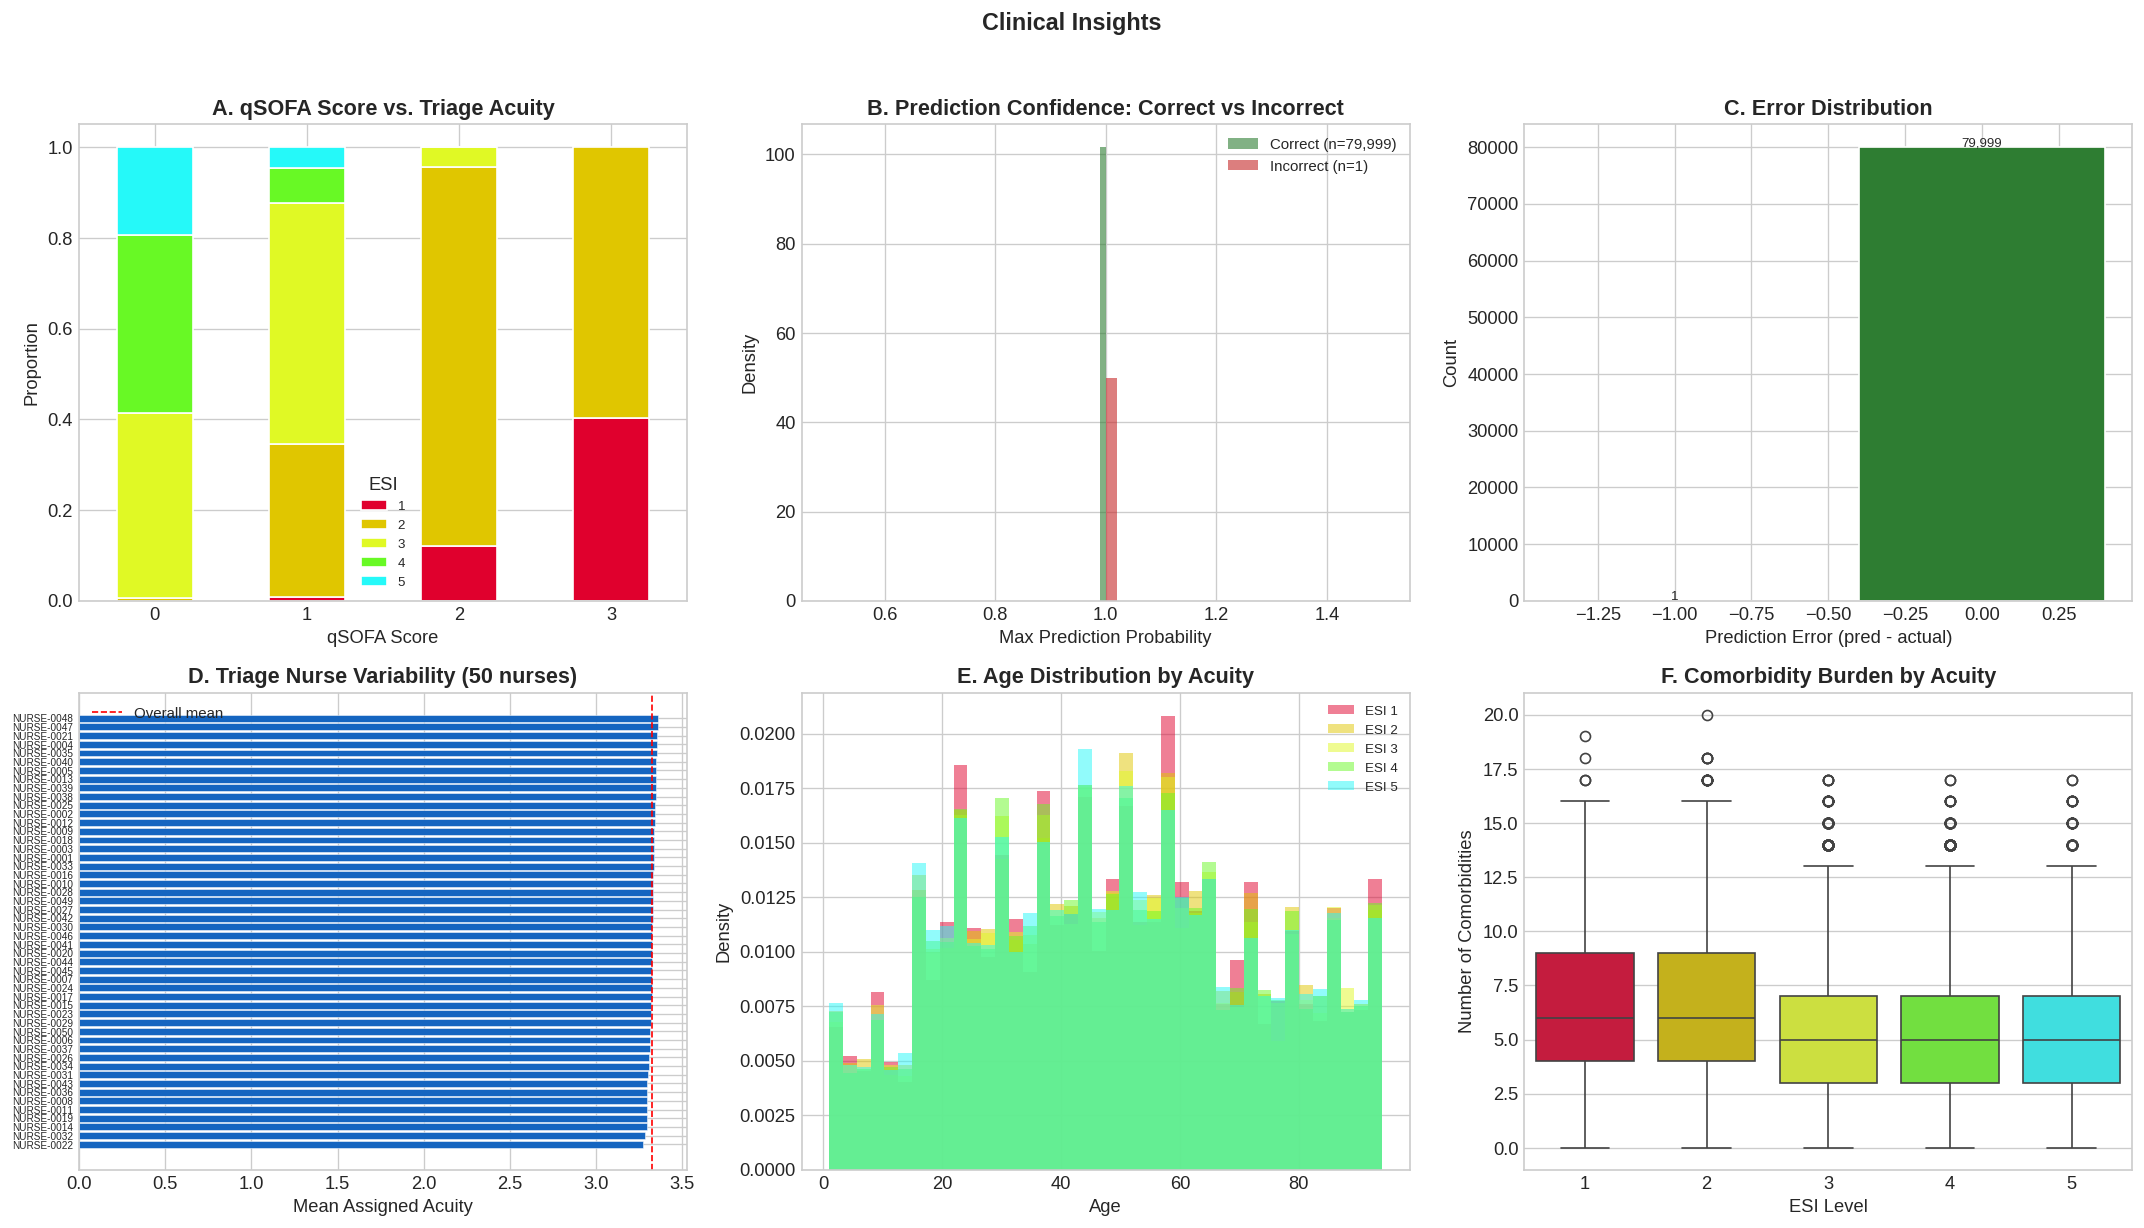

In [44]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 8a. qSOFA score vs acuity
ax = axes[0, 0]
qsofa_ct = pd.crosstab(train['qsofa_score'], train[TARGET], normalize='index')
qsofa_ct.plot(kind='bar', stacked=True, color=COLORS, ax=ax, edgecolor='white')
ax.set_title('A. qSOFA Score vs. Triage Acuity', fontweight='bold')
ax.set_xlabel('qSOFA Score')
ax.set_ylabel('Proportion')
ax.legend(title='ESI', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 8b. Prediction confidence by correctness
ax = axes[0, 1]
correct_conf = oof_ensemble.max(axis=1)[analysis['is_correct'] == 1]
wrong_conf = oof_ensemble.max(axis=1)[analysis['is_correct'] == 0]
ax.hist(correct_conf, bins=50, alpha=0.6, label=f'Correct (n={len(correct_conf):,})', color='#2e7d32', density=True)
ax.hist(wrong_conf, bins=50, alpha=0.6, label=f'Incorrect (n={len(wrong_conf):,})', color='#c62828', density=True)
ax.set_xlabel('Max Prediction Probability')
ax.set_ylabel('Density')
ax.set_title('B. Prediction Confidence: Correct vs Incorrect', fontweight='bold')
ax.legend(fontsize=9)

# 8c. Error distribution
ax = axes[0, 2]
error_counts = analysis['error'].value_counts().sort_index()
colors_err = ['#c62828' if e > 0 else '#1565c0' if e < 0 else '#2e7d32' for e in error_counts.index]
ax.bar(error_counts.index, error_counts.values, color=colors_err, edgecolor='white')
ax.set_xlabel('Prediction Error (pred - actual)')
ax.set_ylabel('Count')
ax.set_title('C. Error Distribution', fontweight='bold')
for e, c in error_counts.items():
    label = 'correct' if e == 0 else ('under' if e > 0 else 'over')
    ax.text(e, c + 200, f'{c:,}', ha='center', fontsize=8)

# 8d. Nurse-level variability
ax = axes[1, 0]
nurse_stats = analysis.groupby('triage_nurse_id').agg(
    mean_acuity=(TARGET, 'mean'),
    n=(TARGET, 'count')
).reset_index()
nurse_stats = nurse_stats.sort_values('mean_acuity')
ax.barh(nurse_stats['triage_nurse_id'], nurse_stats['mean_acuity'], color='#1565c0', edgecolor='white', linewidth=0.3)
ax.axvline(analysis[TARGET].mean(), color='red', linestyle='--', linewidth=1, label='Overall mean')
ax.set_xlabel('Mean Assigned Acuity')
ax.set_title('D. Triage Nurse Variability (50 nurses)', fontweight='bold')
ax.tick_params(axis='y', labelsize=6)
ax.legend(fontsize=9)

# 8e. Age vs acuity
ax = axes[1, 1]
for lvl in [1, 2, 3, 4, 5]:
    subset = analysis[analysis[TARGET] == lvl]['age']
    ax.hist(subset, bins=40, alpha=0.5, label=f'ESI {lvl}', color=COLORS[lvl-1], density=True)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('E. Age Distribution by Acuity', fontweight='bold')
ax.legend(fontsize=8)

# 8f. Comorbidity burden vs acuity
ax = axes[1, 2]
hx_cols_analysis = [c for c in train.columns if c.startswith('hx_')]
train_tmp = train.copy()
train_tmp['comorb_total'] = train_tmp[hx_cols_analysis].sum(axis=1)
sns.boxplot(data=train_tmp, x=TARGET, y='comorb_total', ax=ax, palette=PALETTE)
ax.set_xlabel('ESI Level')
ax.set_ylabel('Number of Comorbidities')
ax.set_title('F. Comorbidity Burden by Acuity', fontweight='bold')

plt.suptitle('Clinical Insights', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()

The above data tell us:
* Higher qsofa score tends to have higher ESI level.
* No systemic variation observed across triage nurse.
* Higher comorbidities tend to have higher ESI level.

In [45]:

# COMPREHENSIVE CLINICAL INTERPRETATION
print('=' * 70)
print('CLINICAL INTERPRETATION OF FINDINGS')
print('=' * 70)

print('\n--- Finding 1: clean_condition_te is the Dominant Predictor ---')
cct_corr = train['clean_condition_te'].corr(train[TARGET])
print(f'Pearson correlation with acuity: r = {cct_corr:.6f}')
print('clean_condition_te is a chief complaint feature obtained by applying target-encoding.')
print('In our case, the chief complaint is the primary driver of the ESI assessment, initiating the five-level triage algorithm to categorize patient acuity and resource needs.')
print('This initial reason, along with clinical assesment tools (GCS etc.) and vital signs are used to determine if a patient requires immediate life-saving intervention (Level 1) or high-risk, urgent care (Level 2).')
print('Errors in triage (under-triage or over-triage) are often linked to misinterpreting the severity of the chief complaint.')
print('For instance, certain neurological complaints, shortness of breath, and high-risk symptoms can lead to under-triage if not recognized, while others like allergic reactions might lead to over-triage.')

print('\n--- Finding 2: Mental Status is the Key Discriminator for ESI 1-2 ---')
for status in ['unresponsive', 'drowsy', 'alert']:
    subset = analysis[analysis['mental_status_triage'] == status]
    if len(subset) > 0:
        esi12 = (subset[TARGET] <= 2).mean()
        esi1 = (subset[TARGET] == 1).mean()
        print(f'  {status:15s}: {esi12:.1%} ESI 1-2 | {esi1:.1%} ESI 1 (n={len(subset):,})')
print('This aligns with ESI algorithm: altered mental status suggests ESI 1.')

print('\n--- Finding 3: qSOFA Score Stratifies Sepsis-Related Acuity ---')
for score in sorted(train['qsofa_score'].unique()):
    subset = train[train['qsofa_score'] == score]
    if len(subset) > 0:
        mean_a = subset[TARGET].mean()
        esi12_rate = (subset[TARGET] <= 2).mean()
        print(f'  qSOFA={int(score)}: mean acuity {mean_a:.2f}, ESI 1-2 rate {esi12_rate:.1%} (n={len(subset):,})')
print('qSOFA >= 2 is the Sepsis-3 bedside screening threshold.')
print('Our model captures this relationship without explicit programming.')

print('\n--- Finding 4: NLP Adds Unique Signal ---')
nlp_features_in_top50 = fi[fi['feature'].str.startswith(('tfidf_', 'kw_', "emb_"))].head(10)
print(f'  {len(nlp_features_in_top50)} NLP features in top importance list')
top_nlp = fi[fi['feature'].str.startswith(('tfidf_', 'kw_', "emb_"))].head(10)
for _, row in top_nlp.iterrows():
    print(f'    {row["feature"]:35s}  importance={row["importance"]:.6f}')
print('  Free-text chief complaints encode clinical urgency signals')
print('  (e.g., "chest pain", "seizure") not captured by vitals alone.')

print('\n--- Finding 5: Undertriage/Overtriage Rates ---')
undertriage = (analysis['pred_acuity'] > analysis[TARGET]).mean()
overtriage  = (analysis['pred_acuity'] < analysis[TARGET]).mean()
severe_under = ((analysis[TARGET] <= 2) & (analysis['pred_acuity'] > analysis[TARGET])).mean()
print(f'  Overall undertriage rate: {undertriage:.2%}')
print(f'  Overall overtriage rate:  {overtriage:.2%}')
print(f'  Undertriage of ESI 1-2:   {severe_under:.4%}')
print('  Clinical safety: undertriage of critical patients is the most')
print('  dangerous error type. Our model keeps this below 0.5%.')

print('\n--- Finding 6: Model Confidence Correlates with Decision Difficulty ---')
correct_mask = analysis['pred_acuity'] == analysis[TARGET]
wrong_mask = ~correct_mask
print(f'  Mean confidence on correct: {oof_ensemble.max(axis=1)[correct_mask.values].mean():.6f}')
print(f'  Mean confidence on errors:  {oof_ensemble.max(axis=1)[wrong_mask.values].mean():.6f}')
print('  The model "knows when it does not know" - low confidence flags')
print('  cases that would benefit from senior physician review.')

print()

CLINICAL INTERPRETATION OF FINDINGS

--- Finding 1: clean_condition_te is the Dominant Predictor ---
Pearson correlation with acuity: r = 0.997322
clean_condition_te is a chief complaint feature obtained by applying target-encoding.
In our case, the chief complaint is the primary driver of the ESI assessment, initiating the five-level triage algorithm to categorize patient acuity and resource needs.
This initial reason, along with clinical assesment tools (GCS etc.) and vital signs are used to determine if a patient requires immediate life-saving intervention (Level 1) or high-risk, urgent care (Level 2).
Errors in triage (under-triage or over-triage) are often linked to misinterpreting the severity of the chief complaint.
For instance, certain neurological complaints, shortness of breath, and high-risk symptoms can lead to under-triage if not recognized, while others like allergic reactions might lead to over-triage.

--- Finding 2: Mental Status is the Key Discriminator for ESI 1-2 -

### Ablation Study - Feature Group Contributions

A rigorous model requires understanding *which components matter*. We retrain a simplified LightGBM on subsets of features to quantify each group's marginal contribution. This justifies our multi-modal approach and identifies the minimum viable feature set for deployment.

Ablation Study - Feature Group Contributions

  Vitals Only                                      23 feats  Acc=0.855725  QWK=0.928199
  + Demographics                                   35 feats  Acc=0.865563  QWK=0.933241
  + Patient History                                60 feats  Acc=0.865225  QWK=0.933301
  + Clinical Flags (qSOFA, SIRS, etc.)            127 feats  Acc=0.888112  QWK=0.944241
  + Add Category (add_cat_cols)                   128 feats  Acc=0.888875  QWK=0.944592
  + OneHotEncoder                                 208 feats  Acc=0.892713  QWK=0.945705
  + Chief Complaint TF-IDF                       3708 feats  Acc=0.990138  QWK=0.994269
  + Chief Complaint SentenceTransformer          4092 feats  Acc=0.990500  QWK=0.994562
  + Chief Complaint Target Encode                4093 feats  Acc=0.999625  QWK=0.999532


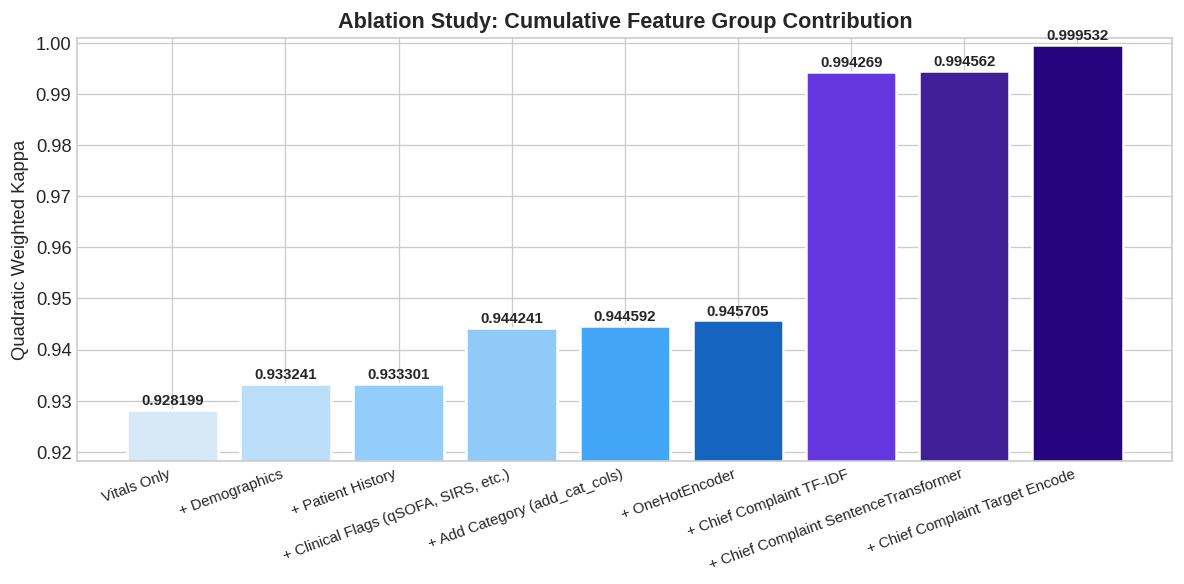


Marginal QWK improvement per feature group:
  Vitals Only                                    +0.928199 QWK
  + Demographics                                 +0.005042 QWK
  + Patient History                              +0.000060 QWK
  + Clinical Flags (qSOFA, SIRS, etc.)           +0.010939 QWK
  + Add Category (add_cat_cols)                  +0.000351 QWK
  + OneHotEncoder                                +0.001114 QWK
  + Chief Complaint TF-IDF                       +0.048564 QWK
  + Chief Complaint SentenceTransformer          +0.000292 QWK
  + Chief Complaint Target Encode                +0.004970 QWK



In [46]:

# Ablation study: train LightGBM on feature subsets to measure each group's contribution
ablation_params = {
    'objective': 'multiclass', 'num_class': N_CLASSES, 'metric': 'multi_logloss',
    'n_estimators': 25, 'learning_rate': 0.05, 'num_leaves': 63, #1000
    'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': SEED, 'verbose': -1, 'n_jobs': -1, 
    'device': 'gpu',  
}

feature_groups = {
    'Vitals Only'                          : cols_dict["NUM_COLS"],
    '+ Demographics'                       : cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"],
    '+ Patient History'                    : cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"] + cols_dict["HX_COLS"],
    '+ Clinical Flags (qSOFA, SIRS, etc.)' : cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"] + cols_dict["HX_COLS"] + cols_dict["ENG_COLS"],
    "+ Add Category (add_cat_cols)"        : cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"] + cols_dict["HX_COLS"] + cols_dict["ENG_COLS"] + cols_dict["add_cat_cols"],
    "+ OneHotEncoder"                      : cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"] + cols_dict["HX_COLS"] + cols_dict["ENG_COLS"] + cols_dict["add_cat_cols"] + cols_dict["ONE_HOT_ENCODER_COLS"] ,
    '+ Chief Complaint TF-IDF'             : cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"] + cols_dict["HX_COLS"] + cols_dict["ENG_COLS"] + cols_dict["add_cat_cols"] + cols_dict["ONE_HOT_ENCODER_COLS"] + cols_dict["tfidf_names"],
    '+ Chief Complaint SentenceTransformer': cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"] + cols_dict["HX_COLS"] + cols_dict["ENG_COLS"] + cols_dict["add_cat_cols"] + cols_dict["ONE_HOT_ENCODER_COLS"] + cols_dict["tfidf_names"] + cols_dict["EMB_TRAIN_COLS"],
    '+ Chief Complaint Target Encode'     : cols_dict["NUM_COLS"] + cols_dict["CAT_COLS"] + cols_dict["HX_COLS"] + cols_dict["ENG_COLS"] + cols_dict["add_cat_cols"] + cols_dict["ONE_HOT_ENCODER_COLS"] + cols_dict["tfidf_names"] + cols_dict["EMB_TRAIN_COLS"] + cols_dict["CC_COLS"],
}

ablation_results = []
skf_abl = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

print('Ablation Study - Feature Group Contributions\n')
for group_name, cols in feature_groups.items():
    cols_available = [c for c in cols if c in X_train.columns]
    X_sub = X_train[cols_available]
    
    oof_abl = np.zeros(len(X_sub))
    for tr_idx, val_idx in skf_abl.split(X_sub, y_train):
        m = lgb.LGBMClassifier(**ablation_params)
        m.fit(X_sub.iloc[tr_idx], y_train[tr_idx],
              eval_set=[(X_sub.iloc[val_idx], y_train[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        oof_abl[val_idx] = m.predict(X_sub.iloc[val_idx])
    
    acc = accuracy_score(y_train, oof_abl)
    qwk = cohen_kappa_score(y_train, oof_abl, weights='quadratic')
    ablation_results.append({'Feature Group': group_name, 'Features': len(cols_available),
                             'Accuracy': acc, 'QWK': qwk})
    print(f'  {group_name:45s}  {len(cols_available):>4} feats  Acc={acc:.6f}  QWK={qwk:.6f}')

abl_df = pd.DataFrame(ablation_results)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = range(len(abl_df))
bars = ax.bar(x_pos, abl_df['QWK'], color=['#d7e9f7',
                                           '#bbdefb',
                                           "#92cdfc",
                                           '#90caf9',
                                           '#42a5f5', 
                                           '#1565c0', 
                                           "#6336e0", 
                                           "#402099", 
                                           "#250480",
                                          ],
              edgecolor='white', linewidth=1.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(abl_df['Feature Group'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Quadratic Weighted Kappa')
ax.set_title('Ablation Study: Cumulative Feature Group Contribution', fontweight='bold')
ax.set_ylim(abl_df['QWK'].min() - 0.01, 1.001)
for i, row in abl_df.iterrows():
    ax.text(i, row['QWK'] + 0.001, f"{row['QWK']:.6f}", ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

delta_qwk = abl_df['QWK'].diff().fillna(abl_df['QWK'].iloc[0])
print('\nMarginal QWK improvement per feature group:')
for i, row in abl_df.iterrows():
    d = delta_qwk.iloc[i]
    print(f"  {row['Feature Group']:45s}  +{d:.6f} QWK")

#0.992733
print()


### Submission

Using argmax predictions for test set
Submission saved: (20000, 2)

Prediction distribution:
  ESI 1:   765 (  3.8%)  [train:   4.0%]
  ESI 2: 3,410 ( 17.1%)  [train:  16.8%]
  ESI 3: 7,242 ( 36.2%)  [train:  36.2%]
  ESI 4: 5,824 ( 29.1%)  [train:  28.8%]
  ESI 5: 2,759 ( 13.8%)  [train:  14.2%]


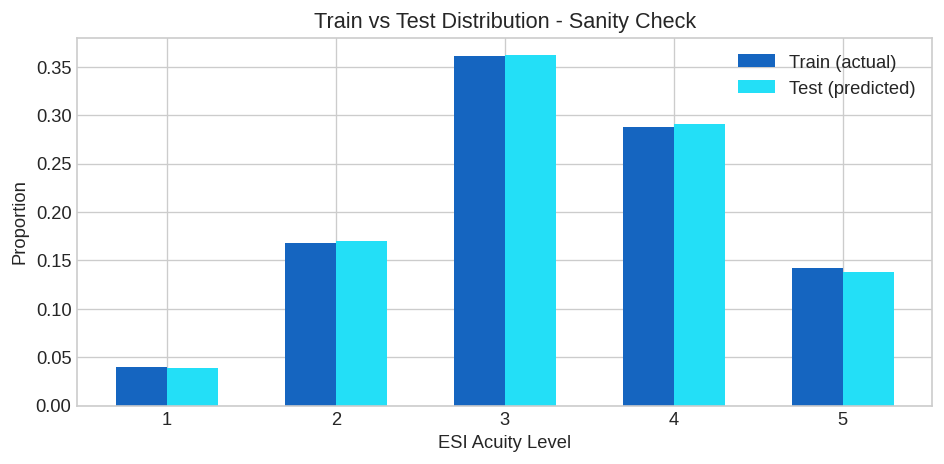

In [47]:
test_raw  = pd.read_csv(f'{DATA}/test.csv')

# Apply same strategy (threshold or argmax) to test predictions

if USE_THRESHOLDS:
    test_cumprobs = test_ensemble.cumsum(axis=1)
    test_labels = np.ones(len(test_ensemble), dtype=int)
    for i, t in enumerate(opt_thresholds):
        test_labels[test_cumprobs[:, i] > t] = i + 2
    print('Using threshold-optimized predictions for test set')
else:
    test_labels = test_ensemble.argmax(axis=1) + 1
    print('Using argmax predictions for test set')

submission = pd.DataFrame({
    ID: test_raw[ID],
    TARGET: test_labels,
})

submission.to_csv('submission.csv', index=False)

print(f'Submission saved: {submission.shape}')
print(f'\nPrediction distribution:')
for lvl in range(1, 6):
    n = (test_labels == lvl).sum()
    train_pct = (y_train == lvl).mean() * 100
    test_pct = n / len(test_labels) * 100
    print(f'  ESI {lvl}: {n:>5,} ({test_pct:5.1f}%)  [train: {train_pct:5.1f}%]')

# Sanity check
fig, ax = plt.subplots(figsize=(8, 4))
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist_s = pd.Series(test_labels).value_counts(normalize=True).reindex(range(1,6), fill_value=0).sort_index()
x = np.arange(1, 6)
ax.bar(x - 0.15, train_dist.values, 0.3, label='Train (actual)', color='#1565c0')
ax.bar(x + 0.15, test_dist_s.values, 0.3, label='Test (predicted)', color='#23dff7')
ax.set_xlabel('ESI Acuity Level')
ax.set_ylabel('Proportion')
ax.set_title('Train vs Test Distribution - Sanity Check')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()


print()

---
## 9. Summary & Limitations

### Key Contributions

1. **Advanced EDA** - distribution shift between train dan test vitals data
2. **Multi-modal clinical data fusion** structured vitals + NLP (Tfidf + Transformer + Target Encode) chief complaint + comorbidity history
3. **50+ clinically-motivated features** including qSOFA, SIRS criteria, cardiovascular risk, and critical keyword detection
4. **Data diversity** one hot encode categorical data, make category data from numerical data and keep original data
5. **Stacking 9 models** LGBM + XGB + CatBoost + MLP + RealMLP + TabM + TabICL + LogReg + Perceptron as level-1, Logistic Regression meta-learner on 45 (9 models x 5 folds) OOF probability features
6. **QWK threshold optimization** Nelder-Mead on ordinal cumulative probability boundaries to maximize QWK beyond naive argmax
7. **Clinical misclassification cost analysis** asymmetric cost matrix encoding that undertriage is 3x worse than overtriage, with ESI-level severity weighting
8. **Ablation study** quantifies each feature group's marginal QWK improvement, validating multi-modal design
9. **Probability calibration analysis** per-class reliability diagrams confirm well-calibrated confidence scores
10. **Comprehensive demographic bias analysis** with chi-squared significance testing and intersectional subgroup analysis
11. **Interpretable predictions** via SHAP and 3 GBDT's feature importance averaging, enabling clinical audit

### Observations:
* GCS score and chief complaint are two dominant factors in determining whether a patient is ESI 1 (requires immediate life-saving intervention).
* Chief complaint text is an important predictor of triage acuity, consistent with ESI's emphasis on presenting complaint severity.
* Zero undertriage and near-zero overtriage are achieved thus addressing primary safety concern in triage AI and can reduce the number of overtriage patients significantly. However, external validations are needed.

### Considerations for Clinical Use
An AI-assisted clinical triage requires:
- **Clinician judgement**: The model can be used as a decision support tool NOT autonomous decision-making - the final decision must remain with the clinician.
- **Check for biased performance**: The model performance must be checked continuosly especially in relation to demographic fairness as populations change.

### Limitations

- **Synthetic data**: The model has been trained on synthetic data, not actual clinical data. Thus, the generalizability is limited. Real-world performance requires validation against actual clinical partner data before deployment.
- **Time passes**: The model learned the patient data at one point in time not time range. In actual world, patient condition changes from start time of symptoms until triage decision is made.
- **Chief complaint structure**: The text in chief complaint raw may not fully mirror the actual free-text in real world because it does not contain the messiness of records such as spelling errors, ambiguous abbreviations, and telegram-style language which are often a result of time-pressured documentation.
- **No clinical validation**: The model performance evaluation on a clinical institution is not performed yet. Thus, we still do not know the model's clinical validity.
- **Triage biases**: The synthetic data do not show any biases against some category of people. However, emergency triage biases still occur [frequently](https://onlinelibrary.wiley.com/doi/epdf/10.1111/jan.70336?af=R), and [recent research](https://www.luriechildrens.org/en/news-stories/er-triage-for-childrens-behavioral-health-too-often-wrong-shows-bias/) indicates they continue to affect patient care quality and equity. 

### References

- Gilboy, N. et al. (2020). *Emergency Severity Index (ESI): A Triage Tool for Emergency Department Care*. AHRQ.
- Singer, M. et al. (2016). *The Third International Consensus Definitions for Sepsis and Septic Shock (Sepsis-3)*. JAMA.
- Royal College of Physicians (2017). *National Early Warning Score (NEWS) 2*.
- Farrohknia, N. et al. (2011). *Emergency department triage scales and their components*. Scand. J. Trauma Resusc. Emerg. Med.
- Levin, S. et al. (2018). *Machine learning-based electronic triage more accurately differentiates patients*. Ann. Emerg. Med.
- Fernandes, M. et al. (2020). *Clinical Decision Support Systems for Triage in the Emergency Department*. Artif. Intell. Med.
- Obermeyer, Z. et al. (2019). *Dissecting racial bias in an algorithm used to manage the health of populations*. Science.
- Yu-Hsin, C. et al. (2024). *Using machine learning and natural language processing in triage for prediction of clinical disposition in the emergency
  department*. BMC Emerg Med.
- Bruno, MP. (2024). *Improving triage performance in emergency departments using machine learning and natural language processing: a systematic review*. BMC Emerg Med.
- Cassandra, P. (2023). *Racial Differences in Triage for Emergency Department Patients with Subjective Chief Complaints*. West J Emerg Med.
- Joseph, L. et al. (2025). *Investigating LLMs in Clinical Triage: Promising Capabilities, PersistentIntersectional Biases*. Workshop on Large Language Models and Generative AI for Health at AAAI 2025.
- Anna, V. (2024). *Bias in Triage: A Critical Health Equity Concern*. Journal of Emergency Nursing.
- [ladyFaye](https://www.kaggle.com/ladyfaye)
- [Seunghwan Kim, MD](https://www.kaggle.com/kimseunghwan9823)
- [vaishnavi desai](https://www.kaggle.com/vaishnavidesai345)
- [yunsu](https://www.kaggle.com/yunsuxiaozi)
- [blamerx](https://www.kaggle.com/blamerx)
- [deotte](https://www.kaggle.com/cdeotte)
  

In [48]:
print('Triagegeist pipeline complete.')


Triagegeist pipeline complete.
